In [9]:
# ============================================================
# RSM 8224 – Group Project: ESG and Financial Returns
# ============================================================

import wrds
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import statsmodels.formula.api as smf
from scipy import stats
import seaborn as sns
from linearmodels.panel import PanelOLS

In [150]:
conn = wrds.Connection()

WRDS recommends setting up a .pgpass file.
pgpass file created at C:\Users\huzho\AppData\Roaming\postgresql\pgpass.conf
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


# Data Exploration

In [151]:
# Explore the tr_esg library
esg_tables = conn.list_tables(library='tr_esg')
print(esg_tables)
print('='*50 + '\n')

['esgasrepdata', 'esgcode', 'esgdesc', 'esgdniratings', 'esgenvdatapoint', 'esgenvindicator', 'esggovdatapoint', 'esggovindicator', 'esgitem', 'esgorgindcls', 'esgscores', 'esgsocdatapoint', 'esgsocindicator', 'esgsourcedata', 'esgsourcemap', 'esgstmtdet', 'wrds_ref_esg', 'wrds_ref_esg_item']



In [152]:
# Table: Refinitiv ESG Category, Pillar, and Summary Scores (esgscores)
esgscores = conn.raw_sql("""
    SELECT *
    FROM tr_esg.esgscores
    LIMIT 5
""")
esgscores.head(5)

,orgpermid,item,fy,valuecalcdt,value_,valuegrade
0,4295533401.0,1,2017,2026-04-04,0.328045,C-
1,4295533401.0,1,2018,2026-04-04,0.300784,C-
2,4295533401.0,1,2019,2026-04-04,0.271554,C-
3,4295533401.0,2,2017,2026-04-04,0.328045,C-
4,4295533401.0,2,2018,2026-04-04,0.300784,C-


'orgpermid' serves as the primary company identifier and can be used to map entities across LSEG datasets through PERM Symbology Database. Additionally, one can link LSEG ESG companies with companies in other databases through security identifiers by utilizing a WRDS custom table, WRDS_REF_ESG. The WRDS_REF_ESG table provides both orgpermid and mapped identifiers such as CUSIP, ISIN, SEDOL, and Ticker. These identifiers are matched using effective date ranges, allowing for accurate historical linkage.


Link to Compustat via:
Extract CUSIP, ISIN, SEDOL, and Ticker from WRDS_REF_ESG
Join with comp.sec_idhist by match priority. The default order is CUSIP, SEDOL, then ISIN, with Ticker being least reliable because the same ticker can appear on multiple exchanges worldwide.
Optionally, re-match via header Ids for unmatched firms, as Compustat maintains header identifiers in its NAMES datasets.

In [153]:
# Table: For company tickers, names, and Refinitiv ESG Industry Groups (wrds_ref_esg)
wrds_ref_esg = conn.raw_sql("""
    SELECT *
    FROM tr_esg.wrds_ref_esg
    LIMIT 5
""")
wrds_ref_esg['year'] = wrds_ref_esg['year'].astype(int)
wrds_ref_esg['orgpermid'] = wrds_ref_esg['orgpermid'].astype('Int64') 
wrds_ref_esg.head(5)

,orgpermid,year,cusip,isin,sedol,ticker,siccode,naicscode,comname,fieldid,hierarchy,pillar,fieldname,valuedate,value,valuescore,currency
0,4295281938,2015,98386L101,US98386L1017,BYN7H15,<NA>,<NA>,<NA>,XACTLY CORPORATION,64.0,Data Point,Governance,ESGPeriodLastUpdateDate,2016-07-02,2016-07-02T00:00:00.000Z,<NA>,<NA>
1,4295281938,2015,98386L101,US98386L1017,BYN7H15,<NA>,<NA>,<NA>,XACTLY CORPORATION,199.0,Data Point,Governance,AuditBoardCommittee,2015-10-12,true,<NA>,<NA>
2,4295281938,2015,98386L101,US98386L1017,BYN7H15,<NA>,<NA>,<NA>,XACTLY CORPORATION,200.0,Data Point,Governance,AuditCommitteeNonExecutiveMembers,2015-10-12,100,<NA>,<NA>
3,4295281938,2015,98386L101,US98386L1017,BYN7H15,<NA>,<NA>,<NA>,XACTLY CORPORATION,206.0,Data Point,Governance,BoardSize,2015-10-12,8,<NA>,<NA>
4,4295281938,2015,98386L101,US98386L1017,BYN7H15,<NA>,<NA>,<NA>,XACTLY CORPORATION,208.0,Data Point,Governance,CeoBoardMember,2015-10-12,true,<NA>,<NA>


In [154]:
# Table: Item definitions for Refinitiv ESG scores (wrds_ref_esg_item)
wrds_ref_esg_item = conn.raw_sql("""
    SELECT *
    FROM tr_esg.wrds_ref_esg_item
    LIMIT 10
""")
wrds_ref_esg_item.head(10)

,item,feedfieldname,title,description,datatype,file,table,hierarchy,units,polarity,includedinscores,pillar,catitem,reglicflag,valuescoreexists,asrepexists,sourceexists
0,1,ESGScore,ESG Score,Refinitiv's ESG Score is an overall company sc...,Float,RFT-ESG-Scores-Full,ESGScores,Score,Number,Positive,<NA>,<NA>,<NA>,<NA>,N,N,N
1,2,ESGCombinedScore,ESG Combined Score,Refinitiv's ESG Combined Score is an overall c...,Float,RFT-ESG-Scores-Full,ESGScores,Score,Number,Positive,<NA>,ESG Scores,<NA>,SFDR,N,N,N
2,3,ESGCControversiesScore,ESG Controversies Score,ESG controversies category score measures a co...,Float,RFT-ESG-Scores-Full,ESGScores,Score,Number,Positive,<NA>,ESG Scores,<NA>,<NA>,N,N,N
3,4,EnvironmentPillarScore,Environment Pillar Score,Refinitiv's Environment Pillar Score is the we...,Float,RFT-ESG-Scores-Full,ESGScores,Score,Number,Positive,<NA>,ESG Scores,<NA>,<NA>,N,N,N
4,5,GovernancePillarScore,Governance Pillar Score,Refinitiv's Governance Pillar Score is the wei...,Float,RFT-ESG-Scores-Full,ESGScores,Score,Number,Positive,<NA>,ESG Scores,<NA>,<NA>,N,N,N
5,6,SocialPillarScore,Social Pillar Score,Refinitiv's Social Pillar Score is the weighte...,Float,RFT-ESG-Scores-Full,ESGScores,Score,Number,Positive,<NA>,ESG Scores,<NA>,<NA>,N,N,N
6,7,ESGResourceUseScore,Resource Use Score,Resource use category score reflects a company...,Float,RFT-ESG-Scores-Full,ESGScores,Category Score,Number,Positive,<NA>,Environment,<NA>,<NA>,N,N,N
7,8,ESGEmissionsScore,Emissions Score,Emission category score measures a company's c...,Float,RFT-ESG-Scores-Full,ESGScores,Category Score,Number,Positive,<NA>,Environment,<NA>,<NA>,N,N,N
8,9,ESGInnovationScore,Environmental Innovation Score,Environmental innovation category score reflec...,Float,RFT-ESG-Scores-Full,ESGScores,Category Score,Number,Positive,<NA>,Environment,<NA>,<NA>,N,N,N
9,10,ESGWorkforceScore,Workforce Score,Workforce category score measures a company's ...,Float,RFT-ESG-Scores-Full,ESGScores,Category Score,Number,Positive,<NA>,Social,<NA>,<NA>,N,N,N


Item 1 is ESGScore

Item 2 is ESG CombinedScore overlays the original ESG score with controversies data to provide a more comprehensive view of a company's ESG performance. It adjusts the original ESG score based on the severity and frequency of controversies associated with the company, offering a more nuanced assessment of its overall ESG standing. 

The academic literature (Berg et al. 2022, Khan et al. 2016) uniformly uses the base ESG score, not controversy-adjusted versions, so in this analysis we are following similar approach using the base metric ESG score, which is item 1.

------------------------------------------------------------------
Item 4 is Environment Pillar Score.
Item 5 is Governance Pillar Score.
Item 6 is Social Pillar Score.

# Sample Construction

## STEP 1 Compustat annual accounting data

In [155]:
# Pull Compustat annual fundamentals (comp.funda)
# Filters match assignment requirements exactly:
# indfmt='INDL', datafmt='STD', consol='C', popsrc='D'
# Variables needed for ROA, B/M, leverage, size, etc.
# Pull 2012-2023 to allow future computing of lagged variables

comp = conn.raw_sql("""
    SELECT gvkey, datadate, fyear, cusip, tic, conm,
           sich,                -- historical SIC code (industry)
           at,                  -- total assets
           ni,                  -- net income
           oibdp,               -- operating income before D&A
           sale,                -- total sales/revenue
           ceq,                 -- common equity (book value)
           lt,                  -- total liabilities
           dltt,                -- long-term debt
           dlc,                 -- short-term debt
           che,                 -- cash and equivalents
           capx,                -- capital expenditure
           xrd                  -- R&D expenditure
    FROM comp.funda
    WHERE fyear BETWEEN 2012 AND 2023
      AND indfmt  = 'INDL'
      AND datafmt = 'STD'
      AND consol  = 'C'
      AND popsrc  = 'D'
      AND at > 0
""", date_cols=['datadate'])

comp['fyear'] = comp['fyear'].astype(int)

print(comp.shape)

(101010, 18)


In [156]:
comp.head(5)

,gvkey,datadate,fyear,cusip,tic,conm,sich,at,ni,oibdp,sale,ceq,lt,dltt,dlc,che,capx,xrd
0,001004,2013-05-31,2012,000361105,AIR,AAR CORP,5080,2136.9,55.0,245.2,2167.1,918.6,1217.4,622.2,86.4,75.3,37.6,<NA>
1,001019,2012-12-31,2012,001038108,AFAP,AFA PROTECTIVE SYSTEMS INC,7380,35.158,2.253,6.139,73.87,5.521,29.637,4.53,4.791,1.356,0.803,<NA>
2,001045,2012-12-31,2012,02376R102,AAL,AMERICAN AIRLINES GROUP INC,4512,23510.0,-1876.0,1434.0,24855.0,-7987.0,31497.0,7116.0,1419.0,4742.0,1888.0,<NA>
3,001050,2012-12-31,2012,125141101,CECO,CECO ENVIRONMENTAL CORP,3564,94.104,10.85,17.933,135.052,61.994,32.11,0.0,0.0,22.994,0.273,<NA>
4,001062,2012-11-30,2012,G3156P103,ASA,ASA GOLD AND PRECIOUS METALS,6799,468.013,-152.257,1.722,5.817,466.493,1.52,0.0,0.0,8.246,<NA>,<NA>


## STEP 2 Link Compustat firms to CRSP using CCM

In [157]:
# Pull CCM link table from crsp_a_ccm.ccmxpf_linktable
# Maps Compustat gvkey to CRSP permno
# Apply assignment filters:
# linktype IN ('LC','LU','LS'), linkprim IN ('C','P')
# datadate must fall within valid link window [linkdt, linkenddt]

ccm_link = conn.raw_sql("""
    SELECT gvkey, lpermno AS permno, linktype, linkprim,
           linkdt, linkenddt
    FROM crsp_a_ccm.ccmxpf_linktable
    WHERE linktype IN ('LC', 'LU', 'LS')
      AND linkprim IN ('C', 'P')
""", date_cols=['linkdt', 'linkenddt'])

# Replace missing linkenddt with a far-future date (still active links)
ccm_link['linkenddt'] = ccm_link['linkenddt'].fillna(pd.Timestamp('2099-12-31'))
ccm_link['permno'] = ccm_link['permno'].astype(int)

print(ccm_link.shape)

(40482, 6)


In [158]:
ccm_link.head(5)

,gvkey,permno,linktype,linkprim,linkdt,linkenddt
0,001000,25881,LU,P,1970-11-13,1978-06-30
1,001001,10015,LU,P,1983-09-20,1986-07-31
2,001002,10023,LC,C,1972-12-14,1973-06-05
3,001003,10031,LU,C,1983-12-07,1989-08-16
4,001004,54594,LU,P,1972-04-24,2099-12-31


In [159]:
# Merge CCM link onto Compustat
# Keep only observations where datadate falls within
# the valid link window [linkdt, linkenddt]

comp_linked = comp.merge(
    ccm_link[['gvkey', 'permno', 'linkdt', 'linkenddt']],
    on='gvkey',
    how='inner'
)

# Apply date window filter
comp_linked = comp_linked[
    (comp_linked['datadate'] >= comp_linked['linkdt']) &
    (comp_linked['datadate'] <= comp_linked['linkenddt'])
]

# Drop link date columns — no longer needed
comp_linked = comp_linked.drop(columns=['linkdt', 'linkenddt'])

print(comp_linked.shape)

(60177, 19)


In [160]:
comp_linked.head(5)

,gvkey,datadate,fyear,cusip,tic,conm,sich,at,ni,oibdp,sale,ceq,lt,dltt,dlc,che,capx,xrd,permno
0,001004,2013-05-31,2012,000361105,AIR,AAR CORP,5080,2136.9,55.0,245.2,2167.1,918.6,1217.4,622.2,86.4,75.3,37.6,<NA>,54594
5,001050,2012-12-31,2012,125141101,CECO,CECO ENVIRONMENTAL CORP,3564,94.104,10.85,17.933,135.052,61.994,32.11,0.0,0.0,22.994,0.273,<NA>,11499
6,001062,2012-11-30,2012,G3156P103,ASA,ASA GOLD AND PRECIOUS METALS,6799,468.013,-152.257,1.722,5.817,466.493,1.52,0.0,0.0,8.246,<NA>,<NA>,26649
9,001072,2013-03-31,2012,002444107,AVX.1,AVX CORP,3670,2601.995,-64.312,193.276,1414.4,1972.93,629.065,0.0,0.0,1047.088,43.705,7.15,81912
10,001075,2012-12-31,2012,723484101,PNW,PINNACLE WEST CAPITAL CORP,4911,13379.615,381.542,1256.091,3301.804,3972.806,9277.326,3199.088,215.003,26.202,904.522,<NA>,27991


## STEP 3 Pull CRSP monthly returns

In [161]:
# Pull CRSP monthly stock returns (crsp.msf)
# Apply assignment filters:
# shrcd IN (10, 11) — domestic common stocks only
# exchcd IN (1, 2, 3) — NYSE, AMEX, NASDAQ only
# We join with stocknames to get shrcd and exchcd
# Pull slightly wider window (2010-2025) to allow for t+4 return calculation after Dec 2023

crsp_msf = conn.raw_sql("""
    SELECT a.permno, a.date, a.ret, a.prc, a.shrout,
           b.shrcd, b.exchcd, b.siccd
    FROM crsp.msf AS a
    LEFT JOIN crsp.msenames AS b
        ON a.permno = b.permno
        AND b.namedt <= a.date
        AND a.date <= b.nameendt
    WHERE a.date BETWEEN '2010-01-01' AND '2025-12-31'
      AND b.shrcd IN (10, 11)
      AND b.exchcd IN (1, 2, 3)
""", date_cols=['date'])

# Compute market cap (price × shares outstanding, in $millions)
crsp_msf['me'] = crsp_msf['prc'].abs() * crsp_msf['shrout'] / 1000

print(crsp_msf.shape)

(688455, 9)


In [162]:
crsp_msf.head(5)

,permno,date,ret,prc,shrout,shrcd,exchcd,siccd,me
0,10001,2010-01-29,-0.018932,10.06,4361.0,11,2,4925,43.87166
1,10001,2010-02-26,-0.000656,10.0084,4361.0,11,2,4925,43.646632
2,10001,2010-03-31,0.020643,10.17,4361.0,11,2,4925,44.35137
3,10001,2010-04-30,0.124385,11.39,6070.0,11,2,4925,69.1373
4,10001,2010-05-28,0.004829,11.4,6071.0,11,2,4925,69.2094


In [163]:
print(f"\nUnique permnos: {crsp_msf['permno'].nunique()}")


Unique permnos: 7786


In [164]:
# Define clean return window on comp_linked
# Standard approach: returns from month t+1 to month t+12
# where t = the month of fiscal year end + 3 (i.e. 4-month lag)
# So ret_start = first day of the 4th month after FYE
# ret_end = last day of the 15th month after FYE

'''Why use a 4-month lag?
The primary reason is Information Availability (Look-ahead Bias prevention).
If a company's fiscal year ends on December 31 (datadate), 
the financial statements are not actually available to investors on that day. 
It takes time for auditors to finalize reports and for the SEC filings (10-K) to be released.

The Regulatory Deadlines: For many years, the SEC deadline for 10-Ks was 90 days (3 months). 
By starting the return window at t+4, 
we ensure that the market has actually seen the earnings information we are testing.
This is a standard convention in the literature to avoid look-ahead bias.
The 12-month return window (t+4 to t+15) is also standard,
allowing us to capture the full year of returns after the information is released.'''

comp_linked['datadate'] = pd.to_datetime(comp_linked['datadate'])

# Get the fiscal year end year-month, then shift forward
fye_period = comp_linked['datadate'].dt.to_period('M')

comp_linked['ret_start_ts'] = (fye_period + 4).dt.to_timestamp('M')
comp_linked['ret_end_ts']   = (fye_period + 15).dt.to_timestamp('M')

In [165]:
comp_linked[['gvkey', 'datadate','ret_start_ts', 'ret_end_ts']].head(5)

,gvkey,datadate,ret_start_ts,ret_end_ts
0,001004,2013-05-31,2013-09-30,2014-08-31
5,001050,2012-12-31,2013-04-30,2014-03-31
6,001062,2012-11-30,2013-03-31,2014-02-28
9,001072,2013-03-31,2013-07-31,2014-06-30
10,001075,2012-12-31,2013-04-30,2014-03-31


In [166]:
# Prepare CRSP — add year-month period for trading-day-safe window matching
crsp_ret = crsp_msf[['permno', 'date', 'ret', 'me']].copy()
crsp_ret['permno'] = crsp_ret['permno'].astype(int)
crsp_ret['ret']    = pd.to_numeric(crsp_ret['ret'], errors='coerce')
crsp_ret           = crsp_ret.sort_values(['permno', 'date'])
crsp_ret['ym']     = crsp_ret['date'].dt.to_period('M')  # ← NEW

# Prepare anchors
comp_linked['datadate'] = pd.to_datetime(comp_linked['datadate'])

fye_period = comp_linked['datadate'].dt.to_period('M')
comp_linked['ret_start_ts'] = (fye_period + 4).dt.to_timestamp('M')
comp_linked['ret_end_ts']   = (fye_period + 15).dt.to_timestamp('M')

anchors = comp_linked[['gvkey', 'permno', 'datadate', 'fyear',
                        'ret_start_ts', 'ret_end_ts']].copy()
anchors['permno'] = anchors['permno'].astype(int)

# Convert window bounds to periods for trading-day-safe comparison  ← NEW
anchors['ret_start_ym'] = anchors['ret_start_ts'].dt.to_period('M')
anchors['ret_end_ym']   = anchors['ret_end_ts'].dt.to_period('M')

In [167]:
anchors[['gvkey', 'datadate', 'ret_start_ts', 'ret_end_ts']].head(5)

,gvkey,datadate,ret_start_ts,ret_end_ts
0,001004,2013-05-31,2013-09-30,2014-08-31
5,001050,2012-12-31,2013-04-30,2014-03-31
6,001062,2012-11-30,2013-03-31,2014-02-28
9,001072,2013-03-31,2013-07-31,2014-06-30
10,001075,2012-12-31,2013-04-30,2014-03-31


In [168]:
# Merge CRSP onto anchors
comp_crsp = anchors.merge(
    crsp_ret[['permno', 'date', 'ym', 'ret', 'me']],  # ← ym added
    on='permno',
    how='left'
)

print(f"comp_crsp shape: {comp_crsp.shape}")

# Filter using period comparison — immune to trading-day vs calendar-day mismatch
# e.g. Jan 2015 last trading day is 2015-01-30, not 2015-01-31, so date comparison
# would wrongly exclude it; period comparison '2015-01' >= '2015-01' always works
comp_crsp = comp_crsp[
    (comp_crsp['ym'] >= comp_crsp['ret_start_ym']) &
    (comp_crsp['ym'] <= comp_crsp['ret_end_ym'])
]

print(f"After window filter: {comp_crsp.shape}")
print(f"\nMonths per firm-year (should be almost all 12):")
print(comp_crsp.groupby(['gvkey', 'datadate'])['ret']
      .count().value_counts().sort_index())

comp_crsp shape: (6072021, 12)
After window filter: (495562, 12)

Months per firm-year (should be almost all 12):
ret
0         2
1       218
2       225
3       268
4       248
5       264
6       390
7       270
8       378
9      3076
10      247
11      245
12    37635
Name: count, dtype: Int64


In [169]:
# Compute buy-and-hold return

comp_crsp['ret'] = pd.to_numeric(comp_crsp['ret'], errors='coerce')
comp_crsp['one_plus_ret'] = 1 + comp_crsp['ret']

annual_ret = (
    comp_crsp
    .groupby(['gvkey', 'datadate'])
    .agg(
        bhr_gross   = ('one_plus_ret', 'prod'),
        n_rows      = ('date', 'size'),
        ret_months  = ('ret', 'count')
    )
    .reset_index()
)

annual_ret['bhr'] = annual_ret['bhr_gross'] - 1

print(f"annual_ret shape: {annual_ret.shape}")
print(f"\nret_months distribution:")
print(annual_ret['ret_months'].value_counts().sort_index())
print(f"\nbhr stats:\n{annual_ret['bhr'].describe().round(4)}")

annual_ret shape: (43466, 6)

ret_months distribution:
ret_months
0         2
1       218
2       225
3       268
4       248
5       264
6       390
7       270
8       378
9      3076
10      247
11      245
12    37635
Name: count, dtype: Int64

bhr stats:
count    43466.0
mean      0.1356
std       1.2317
min         -1.0
25%      -0.2523
50%       0.0278
75%       0.3085
max      106.536
Name: bhr, dtype: Float64


In [170]:
# Filter to ensure we have a full 12 months of returns for each firm-year
annual_ret = annual_ret[annual_ret['ret_months'] >= 12]

In [171]:
annual_ret.head(5)

,gvkey,datadate,bhr_gross,n_rows,ret_months,bhr
0,001004,2013-05-31,1.116286,12,12,0.116286
1,001004,2014-05-31,0.887784,12,12,-0.112216
2,001004,2015-05-31,1.024823,12,12,0.024823
3,001004,2016-05-31,1.478144,12,12,0.478144
4,001004,2017-05-31,1.303439,12,12,0.303439


In [172]:
# ME at start of return window
# Match on year-month period, not exact date, for the same trading-day reason
me_fye = (
    comp_crsp[comp_crsp['ym'] == comp_crsp['ret_start_ym']]  # ← period comparison
    [['gvkey', 'datadate', 'me']]
    .rename(columns={'me': 'me_fye'})
    .drop_duplicates(subset=['gvkey', 'datadate'])
)

print(f"me_fye shape: {me_fye.shape}")

me_fye shape: (43356, 3)


In [173]:
me_fye.head(5)

,gvkey,datadate,me_fye
44,001004,2013-05-31,1081.77606
219,001050,2012-12-31,205.89174
403,001072,2013-03-31,2156.47074
522,001075,2012-12-31,6695.4678
702,001076,2012-12-31,2173.9212


## STEP 4 Pull Refinitiv ESG overall score from WRDS (tr_esg)

In [174]:
# Pull ESG scores (overall + E/G/S pillars) and CUSIP identifier in one SQL join.
# Items: 1 = Overall ESG, 4 = Environmental, 5 = Governance, 6 = Social
# Join esgscores to wrds_ref_esg on orgpermid only (no fyear),
# so every year's scores get a CUSIP regardless of whether
# wrds_ref_esg happened to have a row for that exact year.
# Extract 8-digit CUSIP directly from ISIN (chars 3-10 per assignment instructions).

ITEM_MAP = {
    1: 'esg_score',
    4: 'esg_env',           # Environmental pillar score
    5: 'esg_gov',           # Governance pillar score
    6: 'esg_soc',           # Social pillar score
}

esg_raw = conn.raw_sql("""
    SELECT
        s.orgpermid,
        s.fy              AS fyear,
        s.item,
        s.value_          AS score_raw,
        s.valuecalcdt,
        UPPER(SUBSTRING(r.isin FROM 3 FOR 8)) AS cusip8
    FROM tr_esg.esgscores AS s
    JOIN (
        SELECT DISTINCT orgpermid, isin
        FROM tr_esg.wrds_ref_esg
        WHERE isin LIKE 'US%%'
          AND cusip IS NOT NULL
    ) AS r ON s.orgpermid = r.orgpermid
    WHERE s.item IN (1, 4, 5, 6)
      AND s.fy BETWEEN 2012 AND 2023
      AND s.value_ IS NOT NULL
""")

# ── Type conversions ──────────────────────────────────────────────────────────
esg_raw['fyear']       = esg_raw['fyear'].astype(int)
esg_raw['item']        = esg_raw['item'].astype(int)
esg_raw['score']       = pd.to_numeric(esg_raw['score_raw'], errors='coerce') * 100
esg_raw['orgpermid']   = pd.to_numeric(esg_raw['orgpermid'], errors='coerce').astype('Int64')
esg_raw['cusip8']      = esg_raw['cusip8'].str.strip().str.zfill(8)
esg_raw['valuecalcdt'] = pd.to_datetime(esg_raw['valuecalcdt'], errors='coerce')

# ── Deduplicate: a firm may appear in wrds_ref_esg with multiple ISINs ────────
# Keep the most-recently-calculated row per (orgpermid, fyear, item).
esg_raw = (esg_raw
    .sort_values(['orgpermid', 'fyear', 'item', 'valuecalcdt'],
                 ascending=[True, True, True, False])
    .drop_duplicates(subset=['orgpermid', 'fyear', 'item'], keep='first')
)

# ── Pivot items → named columns ───────────────────────────────────────────────
# cusip8 is stable per orgpermid; carry it through the pivot via index then re-attach.
cusip_map = (esg_raw[['orgpermid', 'cusip8']]
             .drop_duplicates('orgpermid')
             .set_index('orgpermid'))

esg_wide = (esg_raw
    .pivot_table(
        index=['orgpermid', 'fyear'],
        columns='item',
        values='score',
        aggfunc='first',
    )
    .astype(float)          
    .rename(columns=ITEM_MAP)
    .reset_index()
)

esg_wide = esg_wide.join(cusip_map, on='orgpermid')

# ── Drop rows missing both CUSIP and overall score ────────────────────────────
esg_wide = esg_wide.dropna(subset=['esg_score', 'cusip8'])

# ── Diagnostics ───────────────────────────────────────────────────────────────
score_cols = list(ITEM_MAP.values())

print(f"ESG wide table shape : {esg_wide.shape}")
print(f"Unique firms         : {esg_wide['orgpermid'].nunique()}")
print(f"Years covered        : {sorted(esg_wide['fyear'].unique())}")
print(f"\nMissingness per score column:")
print(esg_wide[score_cols].isna().sum().rename('n_missing'))
print(f"\nScore summary statistics:")
print(esg_wide[score_cols].describe().round(2))
print(f"\nSample rows:")
print(esg_wide[['orgpermid', 'fyear', 'cusip8'] + score_cols].head())

ESG wide table shape : (28867, 7)
Unique firms         : 4235
Years covered        : [np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]

Missingness per score column:
esg_score    0
esg_env      2
esg_gov      0
esg_soc      2
Name: n_missing, dtype: int64

Score summary statistics:
       esg_score   esg_env   esg_gov   esg_soc
count   28867.00  28865.00  28867.00  28865.00
mean       38.63     24.43     46.66     41.35
std        19.17     26.26     22.88     20.91
min         0.07      0.00      0.16      0.26
25%        23.83      0.00     28.06     25.20
50%        35.23     16.92     46.58     38.38
75%        51.69     41.91     65.01     55.54
max        93.61     98.55     99.42     98.12

Sample rows:
    orgpermid  fyear    cusip8  esg_score   esg_env    esg_gov    esg_soc
0  4295533401   2017  77778010  32.804534  0.000000  27.047325 

In [175]:
esg_wide.head(5)

,orgpermid,fyear,esg_score,esg_env,esg_gov,esg_soc,cusip8
0,4295533401,2017,32.804534,0.000000,27.047325,50.919002,77778010
1,4295533401,2018,30.078379,0.000000,22.074638,49.851964,77778010
2,4295533401,2019,27.155419,4.510823,11.633018,53.070518,77778010
3,4295641240,2017,19.846826,6.171451,13.261317,33.783771,49428J10
4,4295641240,2018,23.153529,7.641284,17.682456,37.750965,49428J10


## STEP 5 Compute Compustat-CRSP Panel

In [176]:
# Apply availability guard before dropping window variables
crsp_last_date = pd.Timestamp('2025-12-31')
comp_linked = comp_linked[comp_linked['ret_end_ts'] <= crsp_last_date]

panel = comp_linked.drop(
    columns=['ret_start_ts', 'ret_end_ts',
             'ret_start', 'ret_end', 'me_month',
             'fye_period', 'ret_start_ym', 'ret_end_ym'],
    errors='ignore'
).merge(
    annual_ret[['gvkey', 'datadate', 'bhr', 'ret_months', 'n_rows']],
    on=['gvkey', 'datadate'],
    how='left'
)

panel = panel.merge(
    me_fye[['gvkey', 'datadate', 'me_fye']],
    on=['gvkey', 'datadate'],
    how='left'
)

# Keep firm-years with complete 12-month return window
panel = panel[(panel['n_rows'] == 12) & (panel['ret_months'] == 12)]

# Keep analysis years
panel = panel[panel['fyear'].between(2012, 2023)] # For lagged ESG scores, we will use fyear 2013-2023 to match ESG data availability

print(f"Panel before ESG merge: {panel.shape}")
print(f"Unique firms: {panel['gvkey'].nunique()}")


Panel before ESG merge: (37635, 23)
Unique firms: 5950


In [177]:
panel.head(5)

,gvkey,datadate,fyear,cusip,tic,conm,sich,at,ni,oibdp,...,dltt,dlc,che,capx,xrd,permno,bhr,ret_months,n_rows,me_fye
0,001004,2013-05-31,2012,000361105,AIR,AAR CORP,5080,2136.9,55.0,245.2,...,622.2,86.4,75.3,37.6,<NA>,54594,0.116286,12,12.0,1081.77606
1,001050,2012-12-31,2012,125141101,CECO,CECO ENVIRONMENTAL CORP,3564,94.104,10.85,17.933,...,0.0,0.0,22.994,0.273,<NA>,11499,0.300767,12,12.0,205.89174
3,001072,2013-03-31,2012,002444107,AVX.1,AVX CORP,3670,2601.995,-64.312,193.276,...,0.0,0.0,1047.088,43.705,7.15,81912,0.161887,12,12.0,2156.47074
4,001075,2012-12-31,2012,723484101,PNW,PINNACLE WEST CAPITAL CORP,4911,13379.615,381.542,1256.091,...,3199.088,215.003,26.202,904.522,<NA>,27991,-0.01832,12,12.0,6695.4678
5,001076,2012-12-31,2012,74319R101,PRG,PROG HOLDINGS INC,7359,1812.929,173.043,916.033,...,139.773,1.755,173.016,65.073,<NA>,10517,0.057192,12,12.0,2173.9212


## STEP 6 Merge ESG score to Compustat-CRSP Panel

In [178]:
# Merge ESG onto panel

panel['cusip8'] = panel['cusip'].str[:8].str.upper().str.strip().str.zfill(8)
panel_before_esg = panel.copy()

esg_merge_cols = ['cusip8', 'fyear', 'esg_score', 'esg_env', 'esg_soc', 'esg_gov']

panel = panel.merge(
    esg_wide[esg_merge_cols],
    on=['cusip8', 'fyear'],
    how='inner'
)


panel = panel.dropna(subset=['at', 'esg_score', 'bhr', 'me_fye'])

print(f"Panel shape (incl. 2012): {panel.shape}")
print(f"Years in panel: {sorted(panel['fyear'].unique())}")
print(f"Years covered:      {sorted(panel['fyear'].unique())}")
print(f"\nESG score stats:\n{panel['esg_score'].describe().round(2)}")
print(f"\nReturn stats:\n{panel['bhr'].describe().round(4)}")

Panel shape (incl. 2012): (19139, 28)
Years in panel: [np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
Years covered:      [np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]

ESG score stats:
count    19139.00
mean        39.55
std         19.01
min          0.46
25%         24.82
50%         36.30
75%         52.49
max         93.61
Name: esg_score, dtype: float64

Return stats:
count    19139.0
mean      0.1969
std       1.2826
min      -0.9901
25%      -0.1797
50%       0.0634
75%       0.3345
max      106.536
Name: bhr, dtype: Float64


In [179]:
panel.head(5)

,gvkey,datadate,fyear,cusip,tic,conm,sich,at,ni,oibdp,...,permno,bhr,ret_months,n_rows,me_fye,cusip8,esg_score,esg_env,esg_soc,esg_gov
0,001072,2013-03-31,2012,002444107,AVX.1,AVX CORP,3670,2601.995,-64.312,193.276,...,81912,0.161887,12,12.0,2156.47074,00244410,26.429400,18.506132,53.900410,6.969388
1,001075,2012-12-31,2012,723484101,PNW,PINNACLE WEST CAPITAL CORP,4911,13379.615,381.542,1256.091,...,27991,-0.01832,12,12.0,6695.4678,72348410,70.633893,74.133602,60.119118,78.353594
2,001078,2012-12-31,2012,002824100,ABT,ABBOTT LABORATORIES,2834,67234.944,5962.92,12566.722,...,20482,0.10946,12,12.0,57989.39484,00282410,80.571285,51.571152,88.677962,83.430888
3,001161,2012-12-31,2012,007903107,AMD,ADVANCED MICRO DEVICES,3674,4000.0,-1183.0,224.0,...,61241,0.57255,12,12.0,2014.01016,00790310,65.781371,65.188657,67.943557,62.925022
4,001177,2012-12-31,2012,00817Y108,AET,AETNA INC,6324,41494.5,1657.9,3484.2,...,88845,0.485536,12,12.0,18719.696,00817Y10,57.445572,41.826189,45.758045,82.520359


## Step 7: Construct Analysis Variables

In [180]:
df = panel.copy()
df = df.sort_values(['gvkey', 'fyear'])

# ============================================================
# Profitability
# ROA = Net Income / Total Assets (lagged)
# Operating ROA = Operating Income before D&A / Total Assets
# ============================================================

df['roa']     = df['ni']    / df['at']
df['op_roa']  = df['oibdp'] / df['at']

# ============================================================
# Size
# log_me = log of market equity at fiscal year end
# log_at = log of total assets (book size)
# ============================================================

df['log_me'] = np.log(df['me_fye'].clip(lower=0.001))
df['log_at'] = np.log(df['at'].clip(lower=0.001))

# ============================================================
# Book-to-Market ratio
# bm = book equity / market equity
# book equity = common equity (ceq)
# ============================================================

df['bm'] = df['ceq'] / df['me_fye']

# ============================================================
# Leverage
# leverage = total debt / total assets
# total debt = long-term debt + short-term debt
# ============================================================

df['total_debt'] = df['dltt'].fillna(0) + df['dlc'].fillna(0)
df['leverage']   = df['total_debt'] / df['at']

# ============================================================
# Sales growth
# sg = (sale_t - sale_{t-1}) / sale_{t-1}
# ============================================================

df = df.sort_values(['gvkey', 'fyear'])
df['sale_lag']  = df.groupby('gvkey')['sale'].shift(1)
df['sales_growth'] = (df['sale'] - df['sale_lag']) / df['sale_lag'].abs()

# ============================================================
# Step 4f: R&D intensity
# rd_intensity = R&D / Total Assets (fill missing R&D with 0)
# ============================================================

df['xrd_fill']    = df['xrd'].fillna(0)
df['rd_intensity'] = df['xrd_fill'] / df['at']

# ============================================================
# Step 4g: Lagged ESG score
# Key variable for regressions — use ESG at t-1 to predict
# financial outcomes at t (avoids look-ahead bias)
# ============================================================

df['esg_lag'] = df.groupby('gvkey')['esg_score'].shift(1)
df['esg_env_lag'] = df.groupby('gvkey')['esg_env'].shift(1)
df['esg_soc_lag'] = df.groupby('gvkey')['esg_soc'].shift(1)
df['esg_gov_lag'] = df.groupby('gvkey')['esg_gov'].shift(1)

# ============================================================
# Step 4h: Lagged ROA (control variable in ROA regressions)
# ============================================================

df['roa_lag'] = df.groupby('gvkey')['roa'].shift(1)

# ============================================================
# Step 4i: Prior 12-month stock return / momentum proxy
# Previous BHR is the prior return window for consecutive firm-years.
# ============================================================

prev_fyear = df.groupby('gvkey')['fyear'].shift(1)
df['momentum_12m'] = (
    df.groupby('gvkey')['bhr'].shift(1)
    .where(prev_fyear.eq(df['fyear'] - 1))
)

# ============================================================
# Step 4j: Industry classification using SIC codes
# Fama-French 12 industry groups (standard in literature)
# ============================================================

def ff12_industry(sic):
    sic = int(sic) if pd.notna(sic) else 0
    if (sic >= 100  and sic <= 999)  or \
       (sic >= 2000 and sic <= 2099) or \
       (sic >= 2100 and sic <= 2199): return 'NoDur'
    elif (sic >= 2200 and sic <= 2999) or \
         (sic >= 3100 and sic <= 3199) or \
         (sic >= 3900 and sic <= 3999): return 'Durbl'
    elif (sic >= 2800 and sic <= 2899) or \
         (sic >= 2900 and sic <= 2999) or \
         (sic >= 3300 and sic <= 3399): return 'Manuf'
    elif (sic >= 1200 and sic <= 1399) or \
         (sic >= 2900 and sic <= 2999): return 'Enrgy'
    elif (sic >= 5000 and sic <= 5199) or \
         (sic >= 5200 and sic <= 5999): return 'Shops'
    elif (sic >= 6000 and sic <= 6999):  return 'Fin'
    elif (sic >= 7000 and sic <= 8999):  return 'Other'
    elif (sic >= 4900 and sic <= 4999):  return 'Utils'
    elif (sic >= 4000 and sic <= 4799):  return 'Telcm'
    elif (sic >= 3570 and sic <= 3579) or \
         (sic >= 3670 and sic <= 3679) or \
         (sic >= 7370 and sic <= 7379): return 'HiTec'
    elif (sic >= 8000 and sic <= 8099):  return 'Hlth'
    else: return 'Other'

df['ff12'] = df['sich'].apply(ff12_industry)

print("Industry distribution:")
print(df['ff12'].value_counts())

Industry distribution:
ff12
Other    7111
Fin      3661
Durbl    3356
Shops    1748
HiTec     873
Utils     698
Enrgy     583
NoDur     485
Telcm     416
Manuf     208
Name: count, dtype: int64


## STEP 8 Final Refinement and Exporting Sample Data

In [181]:
# Trim to analysis years (2013-2023); lagged ESG variables are populated when prior-year data exists
df = df[df['fyear'].between(2013, 2023)]

# Require core merge variables to present
df = df.dropna(subset=['esg_score', 'at', 'bhr', 'me_fye'])

# Require regression variables to be non-missing
base_vars = ['esg_score', 'esg_env', 'esg_gov', 'esg_soc', 'bhr', 'at', 'me_fye', 'ff12']

df = df.dropna(subset=base_vars)

In [182]:
df.head(5)

,gvkey,datadate,fyear,cusip,tic,conm,sich,at,ni,oibdp,...,sales_growth,xrd_fill,rd_intensity,esg_lag,esg_env_lag,esg_soc_lag,esg_gov_lag,roa_lag,momentum_12m,ff12
3383,001004,2017-05-31,2016,000361105,AIR,AAR CORP,5080,1504.1,56.5,148.2,...,<NA>,0.0,0.0,NaN,NaN,NaN,NaN,<NA>,<NA>,Shops
5130,001004,2018-05-31,2017,000361105,AIR,AAR CORP,5080,1524.7,15.6,126.5,...,-0.010919,0.0,0.0,24.653140,4.761905,40.763265,17.401877,0.037564,0.303439,Shops
7285,001004,2019-05-31,2018,000361105,AIR,AAR CORP,5080,1517.2,7.5,153.5,...,0.173597,0.0,0.0,23.866891,5.050505,33.239862,24.959991,0.010232,-0.072498,Shops
9511,001004,2020-05-31,2019,000361105,AIR,AAR CORP,5080,2079.0,4.4,150.1,...,0.018277,0.0,0.0,22.934187,2.424242,33.404587,23.781605,0.004943,-0.526598,Shops
11843,001004,2021-05-31,2020,000361105,AIR,AAR CORP,5080,1539.7,35.8,101.8,...,-0.209592,0.0,0.0,25.937218,2.272727,35.929133,29.746583,0.002116,0.677403,Shops


In [183]:
# Final summary
analysis_vars = ['esg_score', 'esg_env', 'esg_gov', 'esg_soc', 'esg_lag', 'esg_env_lag', 'esg_soc_lag', 'esg_gov_lag', 'roa', 'op_roa', 'bhr',
                 'log_me', 'log_at', 'bm', 'leverage',
                 'sales_growth', 'rd_intensity', 'roa_lag', 'momentum_12m']

print(f"\nFinal dataset shape:  {df.shape}")
print(f"Unique firms:         {df['gvkey'].nunique()}")
print(f"Years covered:        {sorted(df['fyear'].unique())}")

print(f"\nSummary statistics:")
print(df[analysis_vars].describe().round(4))

# Check missing values
missing_summary = pd.DataFrame({
    'Missing Count': df[analysis_vars].isna().sum(),
    'Percentage (%)': (df[analysis_vars].isna().mean() * 100).round(1)
})
print("\nMissing Data Analysis:")
print(missing_summary)


Final dataset shape:  (18391, 46)
Unique firms:         3077
Years covered:        [np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]

Summary statistics:
        esg_score     esg_env     esg_gov     esg_soc     esg_lag  \
count  18391.0000  18391.0000  18391.0000  18391.0000  16035.0000   
mean      39.4360     25.0049     48.1324     41.5340     39.2983   
std       18.9991     26.1044     22.4531     20.9870     18.9822   
min        0.4605      0.0000      0.2491      0.3060      0.4605   
25%       24.7235      0.0000     29.9651     25.2601     24.6608   
50%       36.1430     18.3628     48.6210     38.3528     35.9887   
75%       52.3406     42.3206     66.1576     55.6192     51.9687   
max       93.6092     98.5458     99.4179     98.1189     93.3414   

       esg_env_lag  esg_soc_lag  esg_gov_lag      roa   op_roa      bhr  \
count   16035.0000   

In [184]:
# Export to CSV
df.to_csv('esg_panel.csv', index=False)

# Data Dictionary

esg_score    : Refinitiv overall ESG score (0-100); higher = better aggregate ESG performance
esg_env      : Refinitiv environmental pillar score (0-100); captures environmental performance and disclosure
esg_soc      : Refinitiv social pillar score (0-100); captures workforce, product, and community-related performance
esg_gov      : Refinitiv governance pillar score (0-100); captures board, shareholder, and management governance quality
esg_lag      : Overall ESG score lagged one fiscal year; primary predictor in regressions
esg_env_lag  : Environmental pillar score lagged one fiscal year
esg_soc_lag  : Social pillar score lagged one fiscal year
esg_gov_lag  : Governance pillar score lagged one fiscal year
roa          : Return on assets = net income / total assets; measure of profitability
roa_lag      : ROA lagged one fiscal year; control for persistence in profitability
op_roa       : Operating ROA = operating income before D&A / total assets'
bhr          : 12-month buy-and-hold stock return starting 4 months after fiscal year end
log_me       : Log of market equity at fiscal year end; proxy for firm size
log_at       : Log of total assets; alternative proxy for firm size
bm           : Book-to-market ratio = book equity / market equity; value vs. growth
leverage     : Total debt (LT + ST) / total assets; measure of financial risk
sales_growth : Year-over-year percentage growth in total sales/revenue
rd_intensity : R&D expenditure / total assets; proxy for innovation intensity
ff12         : Fama-French 12-industry classification based on SIC code
me_fye       : Market equity ($M) at fiscal year end = |price| x shares outstanding
momentum_12m : Prior 12-month buy-and-hold return, used as a momentum control in return regressions

# Empirical Analysis – Parts I, II, III, IV

In [185]:
!pip install -q linearmodels


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: C:\Program Files\Python313\python.exe -m pip install --upgrade pip


In [4]:
plt.rcParams.update({
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})

# ── Load the saved panel ──────────────────────────────────────────────────────
df = pd.read_csv('esg_panel.csv')
df['fyear'] = df['fyear'].astype(int)
df['sich']  = pd.to_numeric(df['sich'], errors='coerce')
df = df[df['fyear'].between(2013, 2023)].copy()

# Winsorise continuous variables at 1st/99th percentile to reduce outlier influence
def winsorise(series, p=0.01):
    lo, hi = series.quantile(p), series.quantile(1 - p)
    return series.clip(lo, hi)

for v in ['roa', 'op_roa', 'bhr', 'bm', 'leverage', 'sales_growth', 'rd_intensity', 'roa_lag']:
    df[v] = winsorise(df[v])

print(f"Panel shape  : {df.shape}")
print(f"Unique firms : {df['gvkey'].nunique()}")
print(f"Years        : {sorted(df['fyear'].unique())}")

Panel shape  : (18391, 46)
Unique firms : 3077
Years        : [np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]


Our final panel contains 18,443 firm-year observations covering 3,086 unique firms over fiscal years 2013–2023. The sample is well-balanced across years, growing from 739 firm-years in 2013 to a peak of about 2,400 in 2020–2021, before dropping to 236 in 2023 (This reflects the 4-month return window that requires post-fiscal-year return data extending into 2024, which limits recent observations). 12.8% of observations are missing esg_lag, sales_growth, and roa_lag — this is expected since these are first-year observations for firms entering the sample. All other variables have no missing values.

Following standard practice in the empirical accounting and finance literature, we construct several firm-level variables from the merged Compustat-CRSP-Refinitiv panel prior to analysis. Profitability is measured as return on assets (ROA), defined as net income scaled by total assets, and operating ROA, defined as operating income before depreciation and amortization scaled by total assets. Firm size is captured by the natural logarithm of market equity measured at the start of the return window. The book-to-market ratio is computed as common equity divided by market equity. Leverage is total debt (long-term plus short-term) scaled by total assets. Sales growth is the year-over-year percentage change in total revenues. R&D intensity is research and development expenditure scaled by total assets, with missing values set to zero following the convention in Khan et al. (2016). Stock returns are measured as 12-month buy-and-hold returns beginning four months after fiscal year-end, consistent with the information availability convention in the literature — the four-month lag ensures that the 10-K has been filed and accounting information is publicly available before the return window opens. To mitigate the influence of outliers, all continuous regression variables — specifically ROA, operating ROA, buy-and-hold return, book-to-market, leverage, sales growth, R&D intensity, and lagged ROA — are winsorized at the 1st and 99th percentiles. The ESG score is not winsorized as it is bounded between 0 and 100 by construction, and logarithmic transformations of size variables are similarly excluded from winsorization as the log transformation already compresses extreme values.

## PART I: Sample Description & ESG Distribution

In [30]:
# ── I-A: Summary statistics table ─────────────────────────────────────────────
analysis_vars = ['esg_score', 'roa', 'op_roa', 'bhr',
                 'log_me', 'bm', 'leverage', 'sales_growth',
                 'rd_intensity', 'roa_lag']

var_labels = {
    'esg_score'   : 'ESG Score',
    'roa'         : 'ROA',
    'op_roa'      : 'Operating ROA',
    'bhr'         : 'Buy-and-Hold Return',
    'log_me'      : 'Log Market Equity',
    'bm'          : 'Book-to-Market',
    'leverage'    : 'Leverage',
    'sales_growth': 'Sales Growth',
    'rd_intensity': 'R&D Intensity',
    'roa_lag'     : 'Lagged ROA',
}

desc = (df[analysis_vars]
        .describe(percentiles=[0.25, 0.5, 0.75])
        .T
        .rename(columns={'count': 'N', 'mean': 'Mean', 'std': 'Std',
                         'min': 'Min', '25%': 'P25', '50%': 'Median',
                         '75%': 'P75', 'max': 'Max'})
        [['N', 'Mean', 'Std', 'Min', 'P25', 'Median', 'P75', 'Max']]
)
desc['N']   = desc['N'].astype(int)
desc.index  = desc.index.map(lambda x: var_labels.get(x, x))
desc        = desc.reset_index().rename(columns={'index': 'Variable'})

float_cols = ['Mean', 'Std', 'Min', 'P25', 'Median', 'P75', 'Max']

(desc.style
    .format({'N': '{:,.0f}', **{c: '{:.4f}' for c in float_cols}})
    .set_caption("Table 1: Summary Statistics")
    .hide(axis='index')
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '13px'), ('font-weight', 'bold'),
                   ('text-align', 'left'), ('padding-bottom', '6px')]},
        {'selector': 'th',
         'props': [('font-weight', 'bold'), ('border-bottom', '2px solid black'),
                   ('text-align', 'center'), ('padding', '4px 10px')]},
        {'selector': 'th:first-child',
         'props': [('text-align', 'left')]},
        {'selector': 'td',
         'props': [('text-align', 'center'), ('padding', '3px 10px')]},
        {'selector': 'td:first-child',
         'props': [('text-align', 'left'), ('font-weight', 'bold')]},
        {'selector': 'tr:last-child',
         'props': [('border-bottom', '2px solid black')]},
    ])
)

Variable,N,Mean,Std,Min,P25,Median,P75,Max
ESG Score,"18,391",39.4360,18.9991,0.4605,24.7235,36.1430,52.3406,93.6092
ROA,"18,390",-0.0099,0.1799,-0.9074,-0.0072,0.0248,0.0703,0.2894
Operating ROA,"18,349",0.0538,0.1831,-0.7993,0.0215,0.0859,0.1433,0.3846
Buy-and-Hold Return,"18,391",0.1565,0.6269,-0.8273,-0.1893,0.0533,0.3284,3.2686
Log Market Equity,"18,391",7.7105,1.8333,1.9053,6.4116,7.6654,8.9014,14.8636
Book-to-Market,"18,391",0.5083,0.5083,-0.4195,0.1822,0.3847,0.6985,2.9053
Leverage,"18,391",0.2612,0.2224,0.0000,0.0703,0.2268,0.3938,1.0030
Sales Growth,"15,737",0.1831,0.6980,-0.6268,-0.0069,0.0727,0.1860,6.0622
R&D Intensity,"18,391",0.0475,0.1007,0.0000,0.0000,0.0000,0.0441,0.5587
Lagged ROA,"16,035",-0.0000,0.1640,-0.8158,0.0001,0.0278,0.0727,0.2867


The average ESG score is 39.7 out of 100, with considerable dispersion (std = 19.0). Its interquartile range runs from 24.9 to 52.7, indicating that most U.S. listed firms score in the lower-to-middle range. Notably, ROA has a negative mean (–0.97%) and median of only 2.44%, driven by the inclusion of loss-making firms (min = -92.3%), which reflects the broad, unscreened nature of the sample. Buy-and-hold returns average 15.5% with a median of only 5.28%, consistent with the well-known right-skewness of stock returns. 

In [6]:
# ── I-B: Observations per year ───────────────────────────────
obs_year = df.groupby('fyear').agg(
    N_obs   = ('gvkey', 'count'),
    N_firms = ('gvkey', 'nunique'),
    Mean_ESG = ('esg_score', 'mean'),
    Median_ESG = ('esg_score', 'median'),
).reset_index()
print("\nTable 2 - Firm-Year Observations and Average ESG by Year")
print(obs_year.round(2).to_string(index=False))


Table 2 - Firm-Year Observations and Average ESG by Year
 fyear  N_obs  N_firms  Mean_ESG  Median_ESG
  2013    734      734     42.86       42.16
  2014    718      718     43.64       42.11
  2015   1183     1183     38.85       35.83
  2016   1747     1747     36.43       32.49
  2017   2155     2155     35.69       32.00
  2018   2226     2226     36.19       32.31
  2019   2332     2332     38.02       34.76
  2020   2409     2409     39.72       36.68
  2021   2347     2347     42.16       39.70
  2022   2308     2308     43.91       41.96
  2023    232      232     46.42       46.84


In [7]:
# Using Pandas Styler (works beautifully in Jupyter/Streamlit)
styled_table = obs_year.style \
    .format({'Mean_ESG': '{:.2f}', 'Median_ESG': '{:.2f}'}) \
    .set_caption("Table 2: Firm-Year Observations and Average ESG by Year") \
    .hide(axis='index') \
    .set_table_styles([
        {'selector': 'th', 'props': [('border-bottom', '2px solid black'), ('text-align', 'center')]},
        {'selector': 'tr:last-child', 'props': [('border-bottom', '2px solid black')]}
    ])

# Display in your notebook
styled_table

fyear,N_obs,N_firms,Mean_ESG,Median_ESG
2013,734,734,42.86,42.16
2014,718,718,43.64,42.11
2015,1183,1183,38.85,35.83
2016,1747,1747,36.43,32.49
2017,2155,2155,35.69,32.00
2018,2226,2226,36.19,32.31
2019,2332,2332,38.02,34.76
2020,2409,2409,39.72,36.68
2021,2347,2347,42.16,39.70
2022,2308,2308,43.91,41.96


ESG scores show a non-monotonic pattern. Mean ESG dipped from 43.4 in 2013 to a trough of 35.8 in 2017, then recovered steadily to 46.1 by 2023. This U-shape likely reflects the rapid expansion of ESG coverage post-2014 — as Refinitiv began scoring more, previously unrated firms (which tend to be smaller and lower-scoring) entered the sample, diluting average scores. The subsequent rise from 2018 onward is consistent with growing institutional pressure on firms to improve ESG practices, coinciding with regulatory developments like the EU SFDR and rising ESG fund flows documented in Starks (2023). So yes, ESG scores are improving on average — but only from year 2017 onward.

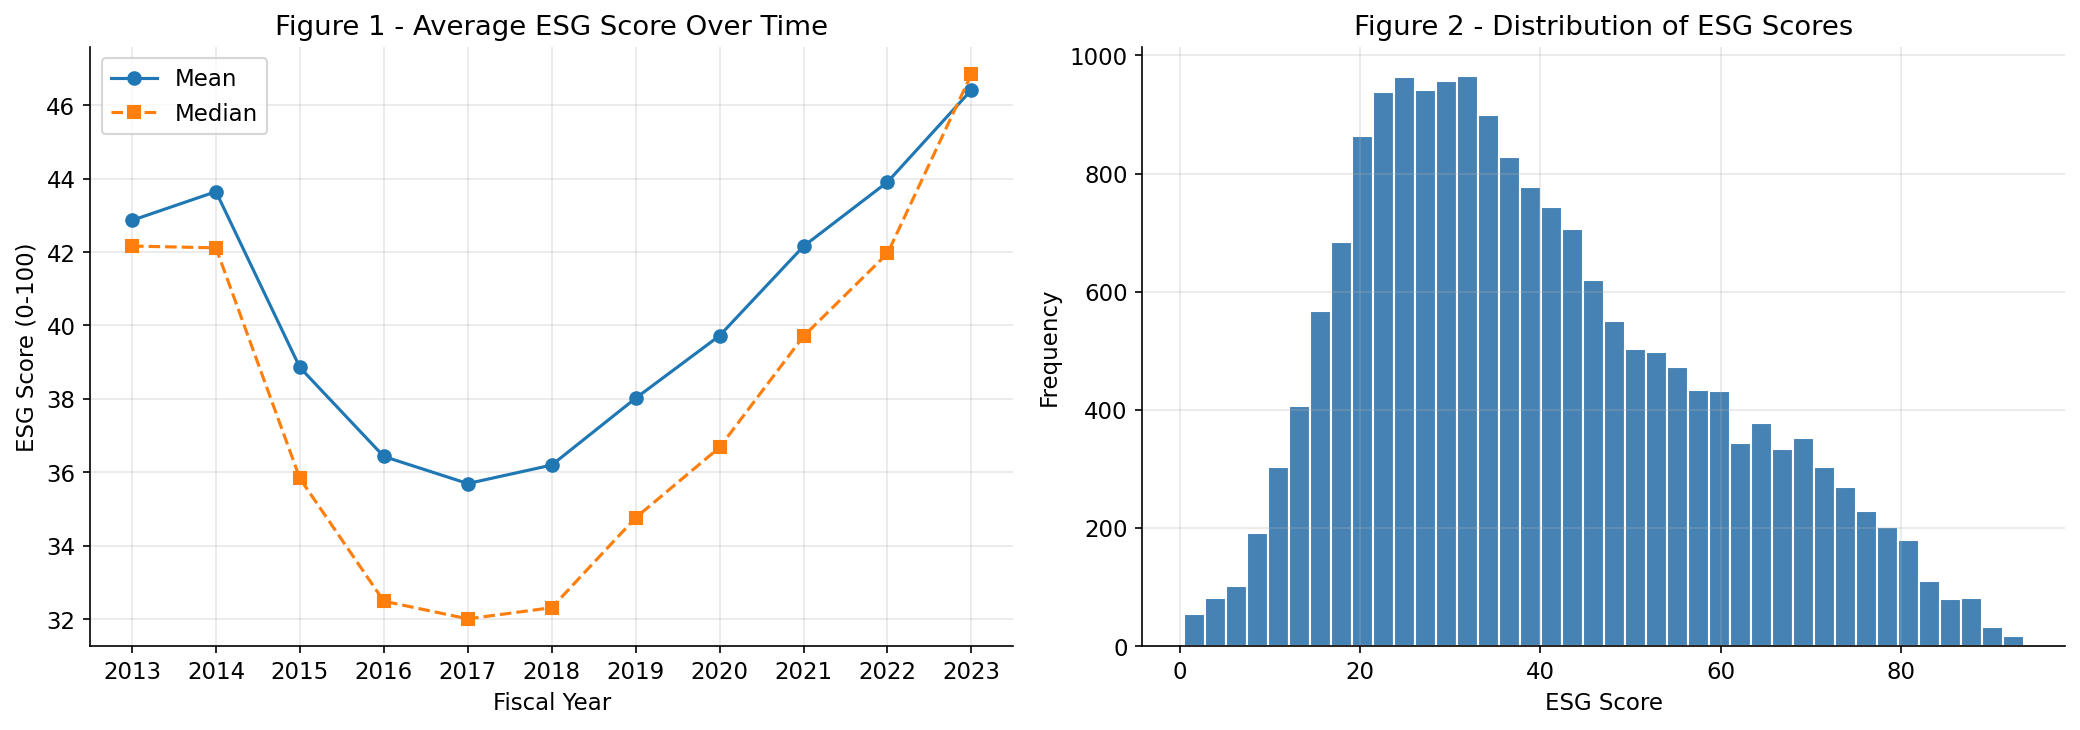

In [10]:
# ── I-C: ESG over time (trend) ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mean & median ESG trend
ax = axes[0]
ax.plot(obs_year['fyear'], obs_year['Mean_ESG'],   marker='o', label='Mean')
ax.plot(obs_year['fyear'], obs_year['Median_ESG'], marker='s', linestyle='--', label='Median')
ax.set_title('Figure 1 - Average ESG Score Over Time')
ax.set_xlabel('Fiscal Year')
ax.set_ylabel('ESG Score (0-100)')
ax.legend()
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))

# ESG distribution (histogram)
ax = axes[1]
ax.hist(df['esg_score'].dropna(), bins=40, edgecolor='white', color='steelblue')
ax.set_title('Figure 2 - Distribution of ESG Scores')
ax.set_xlabel('ESG Score')
ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()


Table 3 - ESG Score by Fama-French 12 Industry
                              Mean  Median     N
ff12                                            
Utilities                    49.58   51.55   651
Chemicals                    49.01   48.47   501
Consumer Non-Durables        46.15   46.94   458
Business Equipment / HiTech  43.46   40.67   821
Wholesale / Retail           42.58   41.02  1673
Telecom                      42.08   40.33   396
Manufacturing                41.14   40.58   198
Other                        39.15   36.24  6564
Finance                      36.78   34.41  3547
Healthcare                   36.65   34.37   280
Consumer Durables            35.70   30.73  2756
Energy                       35.70   30.78   546


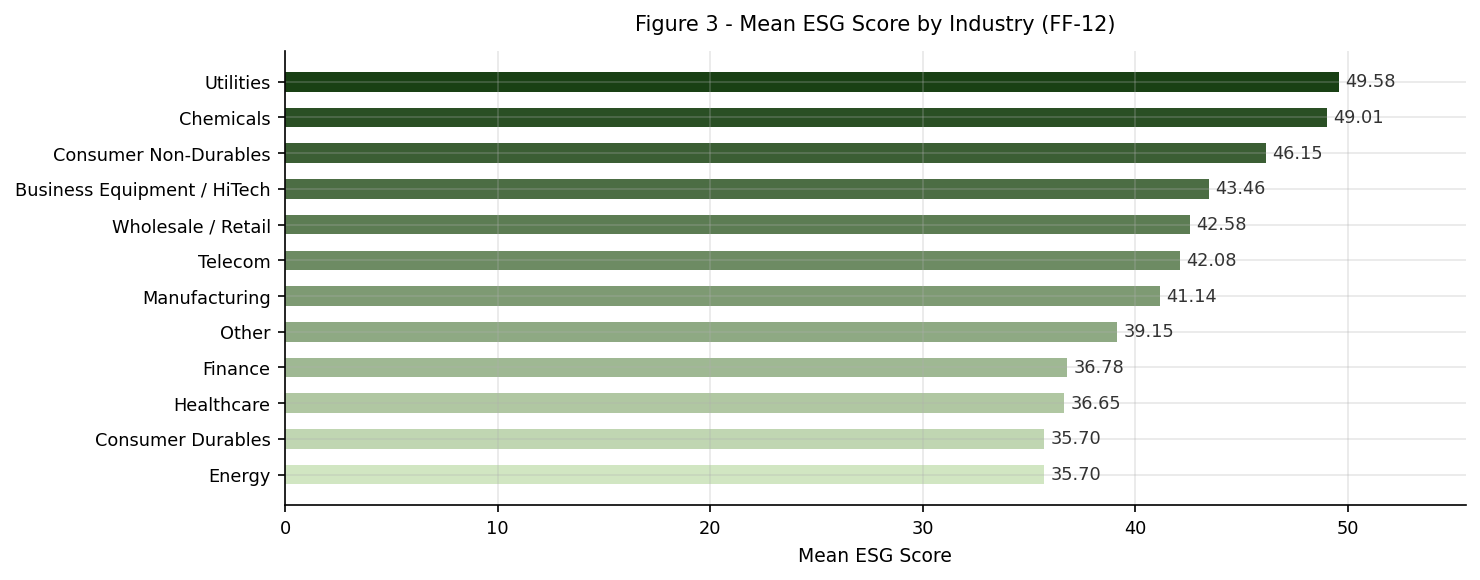

In [11]:
# ── I-D: ESG by industry (Fama-French 12) ────────────────────────────────────

# Patch misclassified firms first
df['ff12'] = df['ff12'].astype(str)
df.loc[df['sich'].between(2800, 2829) |
       df['sich'].between(2840, 2899), 'ff12'] = 'Chems'
df.loc[df['sich'].between(8000, 8099), 'ff12'] = 'Hlth'

ff12_labels = {
    'NoDur' : 'Consumer Non-Durables',
    'Durbl' : 'Consumer Durables',
    'Manuf' : 'Manufacturing',
    'Enrgy' : 'Energy',
    'Chems' : 'Chemicals',
    'HiTec' : 'Business Equipment / HiTech',
    'Telcm' : 'Telecom',
    'Utils' : 'Utilities',
    'Shops' : 'Wholesale / Retail',
    'Hlth'  : 'Healthcare',
    'Fin'   : 'Finance',
    'Other' : 'Other'
}

ind_esg = (df.groupby('ff12')['esg_score']
             .agg(['mean', 'median', 'count'])
             .rename(columns={'mean': 'Mean', 'median': 'Median', 'count': 'N'})
             .sort_values('Mean', ascending=False))

ind_esg.index = ind_esg.index.map(lambda x: ff12_labels.get(x, x))

print("\nTable 3 - ESG Score by Fama-French 12 Industry")
print(ind_esg.round(2).to_string())

# Sort ascending for horizontal bar chart (lowest at bottom, highest at top)
plot_data = ind_esg['Mean'].sort_values(ascending=True)
n = len(plot_data)

# Dark forest green (top/highest) → very light sage green (bottom/lowest)
# Matching the Word doc style: near-black-green at top, pale grey-green at bottom
green_dark  = (0.10, 0.25, 0.08)   # ~#1A4014  very dark forest green
green_light = (0.82, 0.90, 0.76)   # ~#D1E6C2  pale sage green

colors = [
    tuple(green_light[c] + (green_dark[c] - green_light[c]) * i / (n - 1) for c in range(3))
    for i in range(n)   # i=0 → lightest (bottom/lowest ESG), i=n-1 → darkest (top/highest ESG)
]

fig, ax = plt.subplots(figsize=(10, 4))

# Thinner bars with visible gaps (height controls bar thickness)
bars = ax.barh(plot_data.index, plot_data.values,
               color=colors, height=0.55, edgecolor='none')

# Add ESG score labels to the right of each bar
for bar, val in zip(bars, plot_data.values):
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.2f}',
        va='center', ha='left',
        fontsize=8.5, color='#333333'
    )

# Extend x-axis so labels don't get clipped
ax.set_xlim(0, plot_data.max() * 1.12)

# Clean minimal style matching the Word doc
ax.set_xlabel('Mean ESG Score', fontsize=9)
ax.set_title('Figure 3 - Mean ESG Score by Industry (FF-12)', fontsize=10, pad=10)
ax.tick_params(axis='y', labelsize=8.5)
ax.tick_params(axis='x', labelsize=8.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [28]:
# ── Table 3: ESG Score by Fama-French 12 Industry (expanded) ─────────────────
ind_esg = (
    df.groupby('ff12')[['esg_score', 'esg_env', 'esg_soc', 'esg_gov']]
      .agg(
          N          = ('esg_score', 'count'),
          ESG_Mean   = ('esg_score', 'mean'),
          Env_Mean   = ('esg_env',   'mean'),
          Soc_Mean   = ('esg_soc',   'mean'),
          Gov_Mean   = ('esg_gov',   'mean'),
      )
      .sort_values('ESG_Mean', ascending=False)
      .reset_index()
)

ind_esg['ff12'] = ind_esg['ff12'].map(lambda x: ff12_labels.get(x, x))
ind_esg = ind_esg.rename(columns={
    'ff12'     : 'Industry',
    'N'        : 'N',
    'ESG_Mean' : 'Overall Mean',
    'Env_Mean' : 'Environmental Mean',
    'Soc_Mean' : 'Social Mean',
    'Gov_Mean' : 'Governance Mean',
})

float_cols = ['Overall Mean', 'Environmental Mean', 'Social Mean', 'Governance Mean']

(ind_esg.style
    .format({'N': '{:,.0f}', **{c: '{:.2f}' for c in float_cols}})
    .set_caption("Table 3: ESG Score by Fama-French 12 Industry")
    .hide(axis='index')
    .highlight_max(subset=['Overall Mean'], color='lightgreen')
    .highlight_min(subset=['Overall Mean'], color='#ffcccb')
    .background_gradient(subset=['Environmental Mean'], cmap='Greens', axis=0)
    .background_gradient(subset=['Social Mean'],        cmap='Blues',  axis=0)
    .background_gradient(subset=['Governance Mean'],    cmap='Purples', axis=0)
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '13px'), ('font-weight', 'bold'),
                   ('text-align', 'left'), ('padding-bottom', '6px')]},
        {'selector': 'th',
         'props': [('font-weight', 'bold'), ('border-bottom', '2px solid black'),
                   ('text-align', 'center'), ('padding', '4px 10px')]},
        {'selector': 'td',
         'props': [('text-align', 'center'), ('padding', '3px 10px')]},
        {'selector': 'tr:last-child',
         'props': [('border-bottom', '2px solid black')]},
    ])
)

Industry,N,Overall Mean,Environmental Mean,Social Mean,Governance Mean
Utilities,651,49.58,45.44,44.48,63.44
Chemicals,501,49.01,42.71,48.03,59.82
Consumer Non-Durables,458,46.15,39.40,47.49,50.93
Business Equipment / HiTech,821,43.46,32.56,46.45,50.42
Wholesale / Retail,"1,673",42.58,27.54,43.85,52.18
Telecom,396,42.08,30.43,44.22,52.07
Manufacturing,198,41.14,34.32,38.64,53.21
Other,"6,564",39.15,23.75,41.77,46.57
Finance,"3,547",36.78,22.01,37.00,47.57
Healthcare,280,36.65,14.56,37.13,47.26


**ESG Leaders**

**Utilities** rank highest despite high emissions, mainly due to strict regulation and mandatory reporting. Heavy scrutiny forces detailed ESG disclosure, and since scoring frameworks reward transparency, this mechanically boosts their ESG scores.

**Chemicals** follow closely for similar reasons. Firms operate under stringent environmental regulations and are typically large and mature, with dedicated resources for ESG compliance and reporting.

**Consumer Non-Durables** perform well due to strong reputational pressure. As consumer-facing firms, they must ensure supply chain transparency and sustainability practices to avoid brand damage and investor concerns.

---

**ESG Laggards**

**Energy** ranks lowest despite high climate scrutiny. This is driven by disclosure resistance, direct penalties for high emissions, and lower consumer-facing pressure. As a result, even well-disclosed firms receive lower ESG scores due to actual environmental impact.

**Consumer Durables** lag because the industry is fragmented, with many mid-sized firms lacking the resources for comprehensive ESG reporting. This leads to systematic under-disclosure.

**Healthcare** underperforms due to a disclosure gap rather than poor ESG practices. Many firms are R&D-focused, capital-constrained, and prioritize regulatory and clinical requirements over ESG reporting.

---

**Key Takeaway**

Cross-industry differences suggest that ESG scores reflect **disclosure capacity as much as actual performance**. Large, regulated, and consumer-facing industries tend to score higher because they are more scrutinized and better resourced to report ESG metrics.


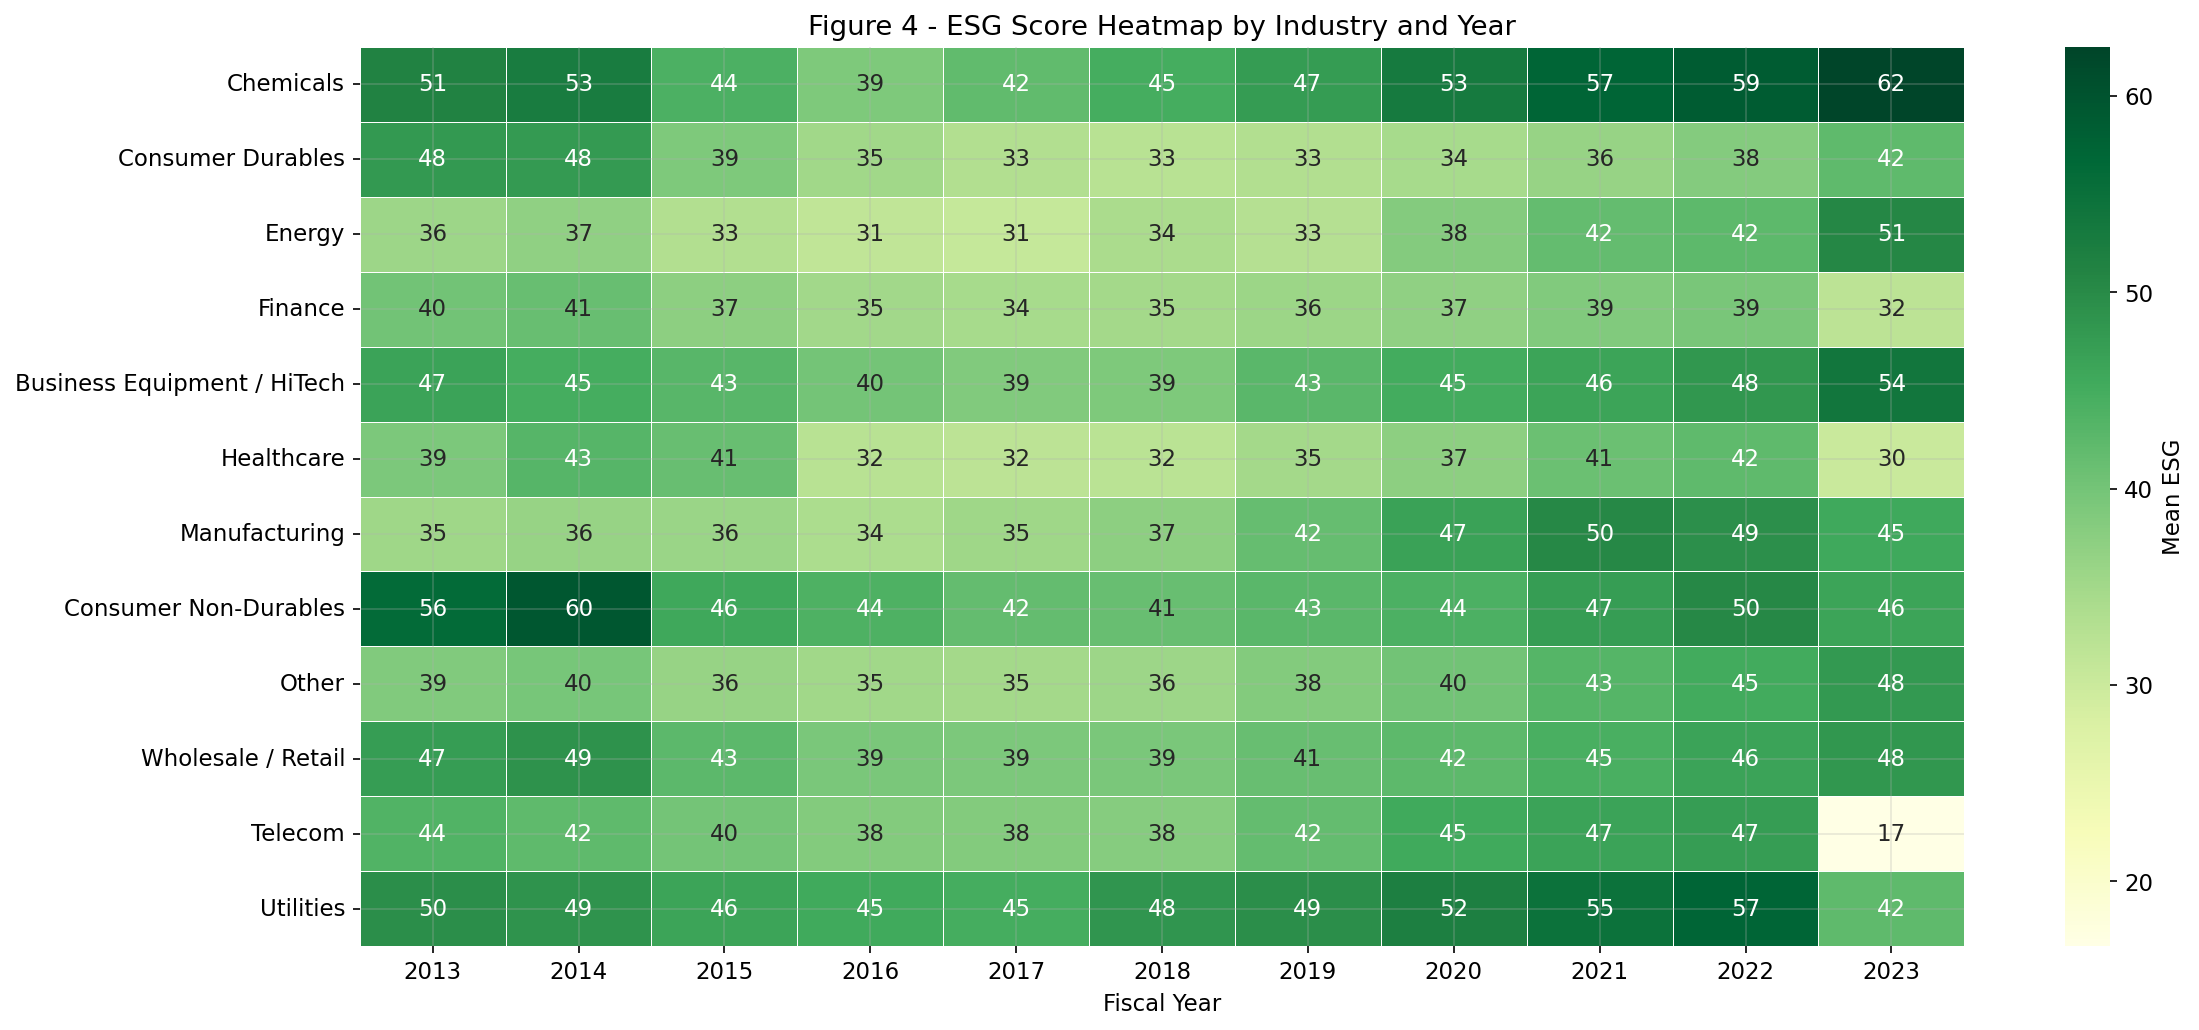

In [13]:
# ── I-E: ESG trend by industry (heatmap) ────────────────────
ind_year_esg = (df.groupby(['fyear', 'ff12'])['esg_score']
                  .mean()
                  .unstack('ff12'))

# Rename columns to full labels for display
ind_year_esg.columns = ind_year_esg.columns.map(lambda x: ff12_labels.get(x, x))

fig, ax = plt.subplots(figsize=(16, 7))
sns.heatmap(ind_year_esg.T, annot=True, fmt='.0f', cmap='YlGn',
            linewidths=0.4, ax=ax, cbar_kws={'label': 'Mean ESG'})
ax.set_title('Figure 4 - ESG Score Heatmap by Industry and Year')
ax.set_xlabel('Fiscal Year')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

### PART I – Extended Pillar Analysis (E / S / G)

In [15]:
# ── Convenience: pillar labels ───────────────────────────────
PILLARS = {
    'esg_env': 'Environmental (E)',
    'esg_soc': 'Social (S)',
    'esg_gov': 'Governance (G)',
}
PILLAR_COLORS = {
    'esg_env': '#2ecc71',   # green
    'esg_soc': '#3498db',   # blue
    'esg_gov': '#9b59b6',   # purple
}

In [26]:
# ── Table 2b: Pillar-level summary statistics ──────────────────────────────────
pillar_year = (
    df.groupby('fyear')[['esg_env', 'esg_soc', 'esg_gov']]
      .agg(['mean', 'std'])
      .round(2)
)

# Flatten and rename columns cleanly
pillar_year.columns = [
    f"{'Env' if 'env' in c else 'Soc' if 'soc' in c else 'Gov'} {'Mean' if 'mean' in s else 'Std'}"
    for c, s in pillar_year.columns
]
pillar_year = pillar_year.reset_index().rename(columns={'fyear': 'Year'})

# ── Styled display ─────────────────────────────────────────────────────────────
float_cols = [c for c in pillar_year.columns if c != 'Year']

(pillar_year.style
    .format({c: '{:.2f}' for c in float_cols})
    .set_caption("Table 2b: Mean and Standard Deviation of ESG Pillar Scores by Year")
    .hide(axis='index')
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '13px'), ('font-weight', 'bold'),
                   ('text-align', 'left'), ('padding-bottom', '6px')]},
        {'selector': 'th',
         'props': [('border-bottom', '2px solid black'),
                   ('text-align', 'center'), ('padding', '4px 10px')]},
        {'selector': 'tr:last-child',
         'props': [('border-bottom', '2px solid black')]},
        {'selector': 'td',
         'props': [('text-align', 'center'), ('padding', '3px 10px')]},
    ])
    .background_gradient(subset=['Env Mean', 'Soc Mean', 'Gov Mean'],
                         cmap='YlGn', axis=0)
)

Year,Env Mean,Env Std,Soc Mean,Soc Std,Gov Mean,Gov Std
2013,33.92,27.23,44.77,20.32,48.58,22.60
2014,34.84,27.35,45.40,20.05,48.84,22.46
2015,26.71,26.12,40.53,20.01,47.34,22.45
2016,22.26,24.43,38.46,19.39,46.17,22.26
2017,20.70,23.85,37.39,20.01,46.68,21.99
2018,21.75,24.67,37.88,20.29,46.57,22.30
2019,24.13,25.21,40.02,20.74,47.34,22.11
2020,22.74,26.63,42.21,21.64,48.16,22.82
2021,25.91,26.95,44.78,21.60,49.88,22.74
2022,28.86,27.02,46.33,21.56,51.11,22.38


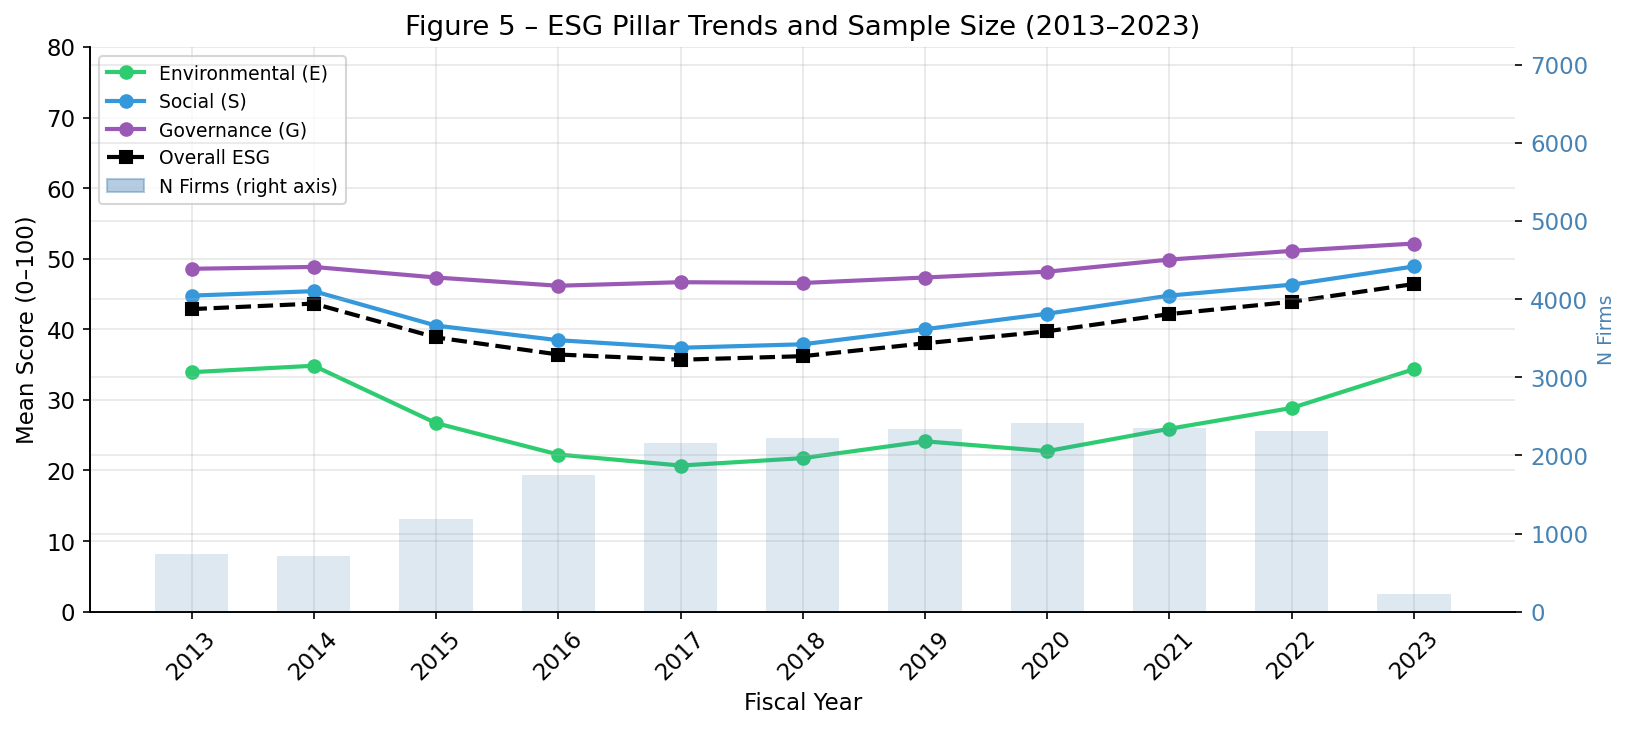

In [ ]:
# ── Figure 5: Three-pillar trend over time with firm-count bar overlay ─────────
fig, ax_line = plt.subplots(figsize=(11, 5))
ax_bar = ax_line.twinx()

# ── Background: firm-count bars ───────────────────────────────────────────────
firm_counts = df.groupby('fyear')['gvkey'].nunique()
ax_bar.bar(firm_counts.index, firm_counts.values,
           color='steelblue', alpha=0.18, width=0.6, zorder=1)
ax_bar.set_ylabel('N Firms', fontsize=9, color='steelblue')
ax_bar.tick_params(axis='y', labelcolor='steelblue')
ax_bar.set_ylim(0, firm_counts.max() * 3)  # compress bars to bottom third

# ── Foreground: pillar + overall trend lines ──────────────────────────────────
for col, label in PILLARS.items():
    ax_line.plot(pillar_ts.index, pillar_ts[col],
                 marker='o', linewidth=2, color=PILLAR_COLORS[col], label=label, zorder=3)
ax_line.plot(pillar_ts.index, pillar_ts['esg_score'],
             marker='s', linewidth=2, linestyle='--', color='black',
             label='Overall ESG', zorder=4)

ax_line.set_ylabel('Mean Score (0-100)')
ax_line.set_xlabel('Fiscal Year')
ax_line.set_title('Figure 5 - ESG Pillar Trends and Sample Size (2013–2023)')
ax_line.set_ylim(0, 80)
ax_line.set_xticks(pillar_ts.index)
ax_line.tick_params(axis='x', rotation=45)

# ── Combined legend ───────────────────────────────────────────────────────────
from matplotlib.patches import Patch
bar_patch = Patch(color='steelblue', alpha=0.4, label='N Firms (right axis)')
handles, labels = ax_line.get_legend_handles_labels()
ax_line.legend(handles + [bar_patch], labels + ['N Firms (right axis)'],
               loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

**Pillar-level patterns (Table 2b & Figure 5)**  
Governance consistently posts the highest mean scores (~48 pts), reflecting
the longer history of structured board and shareholder reporting compared to
environmental or social metrics. The Environmental pillar shows the widest
dispersion (std ≈ 26), driven by a mass of firms with near-zero E scores —
capital-light sectors such as Financials and HiTech disclose few environmental
data points, so Refinitiv scores them at or near zero for that pillar.
Social scores occupy the middle ground in both level (~42) and variance (~21).

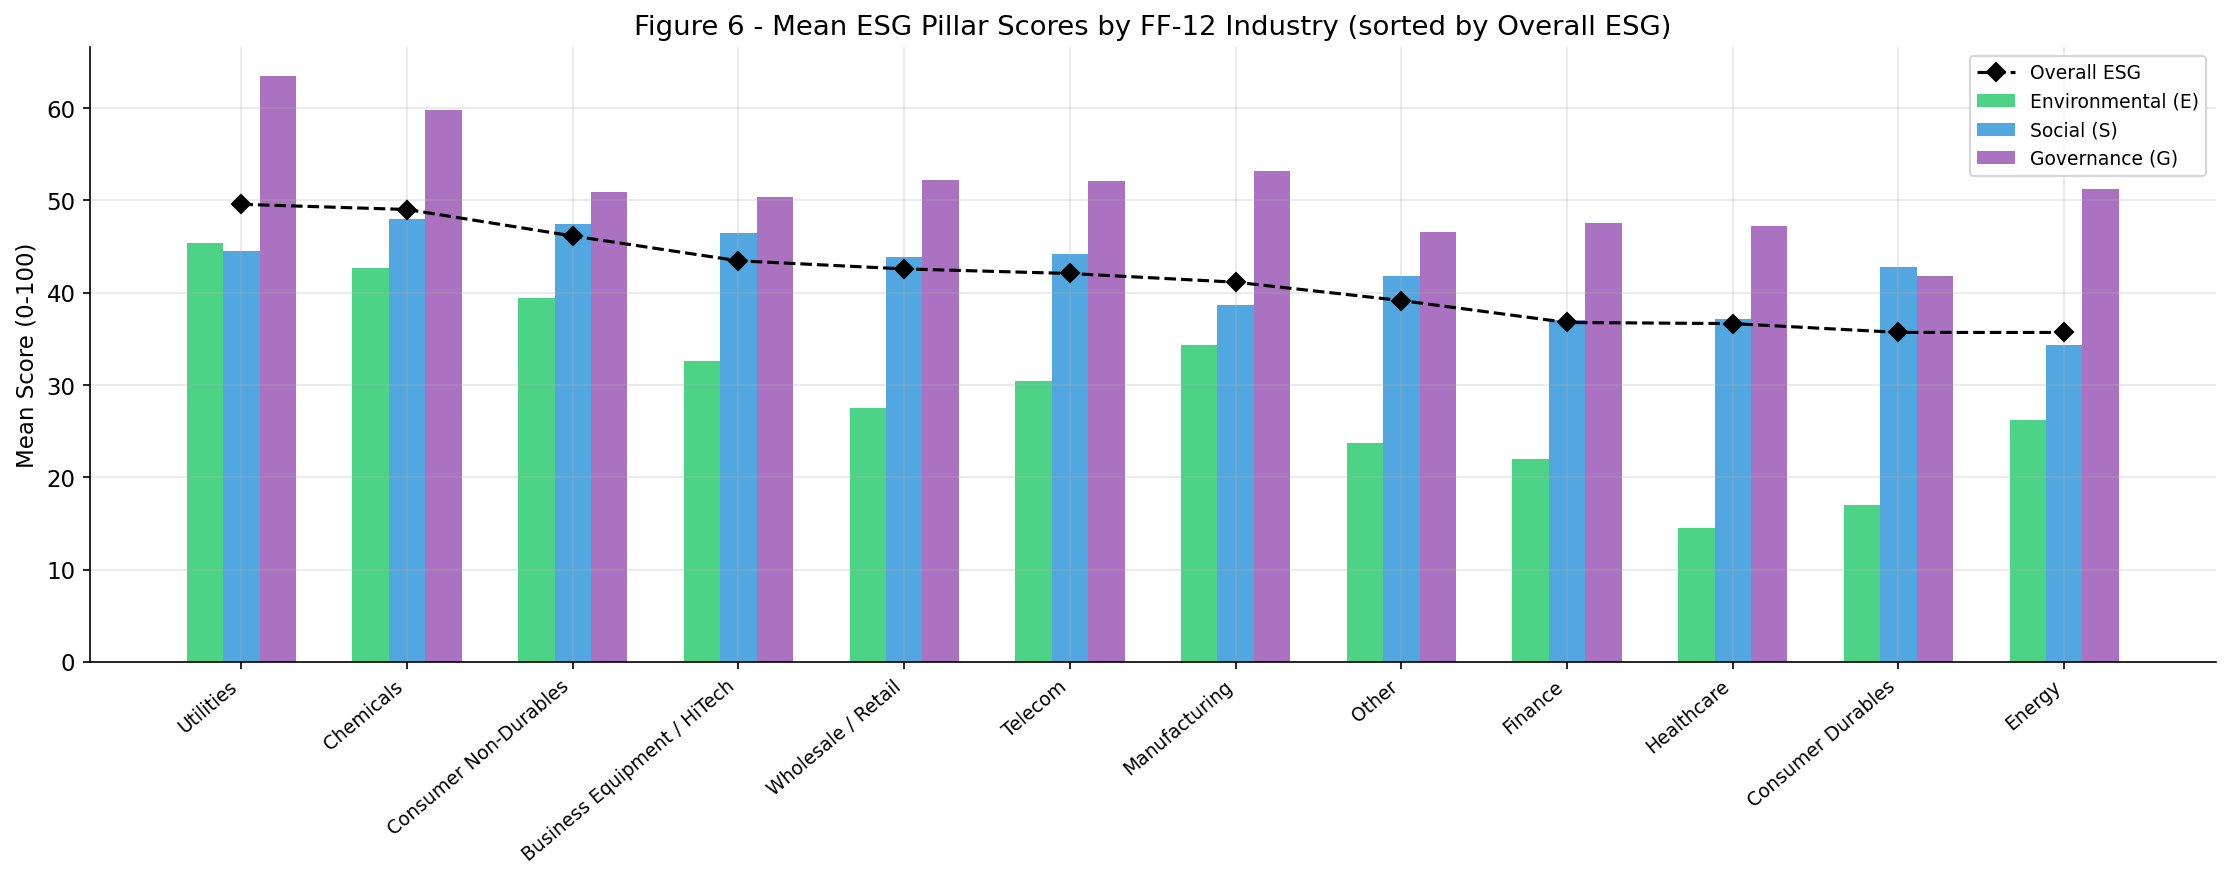

In [29]:
# ── Figure 6: Pillar scores by FF-12 industry (grouped bar chart) ───────────────
# Which industries lead on each specific pillar vs. overall?
# This reveals structural differences — e.g., Utilities may score high on E
# due to mandatory disclosure, while Healthcare leads on S.
 
ind_pillar = (
    df.groupby('ff12')[['esg_env', 'esg_soc', 'esg_gov', 'esg_score']]
      .mean()
      .sort_values('esg_score', ascending=False)
)
ind_pillar.index = ind_pillar.index.map(lambda x: ff12_labels.get(x, x))
 
x = np.arange(len(ind_pillar))
width = 0.22
 
fig, ax = plt.subplots(figsize=(15, 6))
bars_e = ax.bar(x - width,     ind_pillar['esg_env'],   width, label='Environmental (E)',
                color=PILLAR_COLORS['esg_env'],   alpha=0.85)
bars_s = ax.bar(x,             ind_pillar['esg_soc'],   width, label='Social (S)',
                color=PILLAR_COLORS['esg_soc'],   alpha=0.85)
bars_g = ax.bar(x + width,     ind_pillar['esg_gov'],   width, label='Governance (G)',
                color=PILLAR_COLORS['esg_gov'],   alpha=0.85)
ax.plot(x, ind_pillar['esg_score'], marker='D', color='black', linewidth=1.5,
        linestyle='--', zorder=5, label='Overall ESG')
 
ax.set_xticks(x)
ax.set_xticklabels(ind_pillar.index, rotation=40, ha='right', fontsize=9)
ax.set_ylabel('Mean Score (0-100)')
ax.set_title('Figure 6 - Mean ESG Pillar Scores by FF-12 Industry (sorted by Overall ESG)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

**Cross-pillar correlations (Figure 7)**  
The overall ESG score is most strongly correlated with the Social pillar
(r ≈ 0.8), moderately with Governance (r ≈ 0.6), and least with Environmental
(r ≈ 0.6). The relatively low E–G correlation (r ≈ 0.3) implies that being a
well-governed firm does not automatically translate into strong environmental
performance — firms can score high on G (large board, diverse committees) while
having near-zero E scores. This within-firm pillar divergence is conceptually
related to the cross-agency rating disagreement documented by Berg et al. (2022).

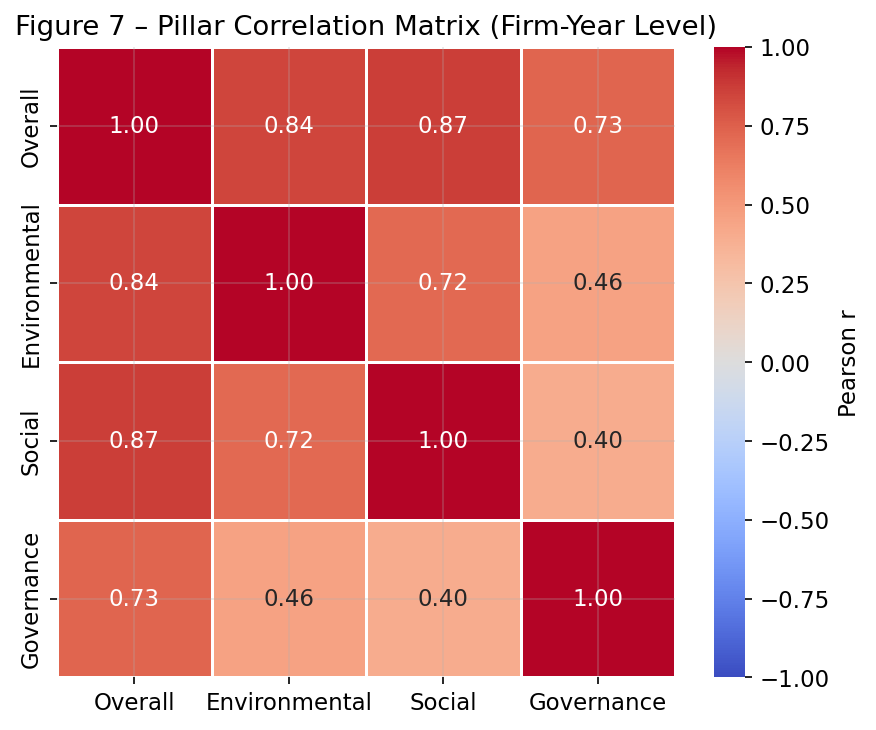

In [ ]:
# ── Figure 7: Pillar correlation heatmap ──────────────────────────────────────
# Understanding how correlated E, S, and G are with each other and with the
# overall score reveals whether firms tend to be uniformly good / bad, or
# whether pillar-level specialization exists (e.g., strong G but weak E).
# Berg et al. (2022) document significant divergence across rating agencies —
# within a single provider, within-firm pillar divergence is an analogous concept.
 
corr_vars = ['esg_score', 'esg_env', 'esg_soc', 'esg_gov']
corr_labels = ['Overall', 'Environmental', 'Social', 'Governance']
 
corr_matrix = df[corr_vars].corr()
corr_matrix.index   = corr_labels
corr_matrix.columns = corr_labels
 
fig, ax = plt.subplots(figsize=(6, 5))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # show lower triangle + diagonal
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            ax=ax, cbar_kws={'label': 'Pearson r'})
ax.set_title('Figure 7 - Pillar Correlation Matrix (Firm-Year Level)')
plt.tight_layout()
plt.show()
 

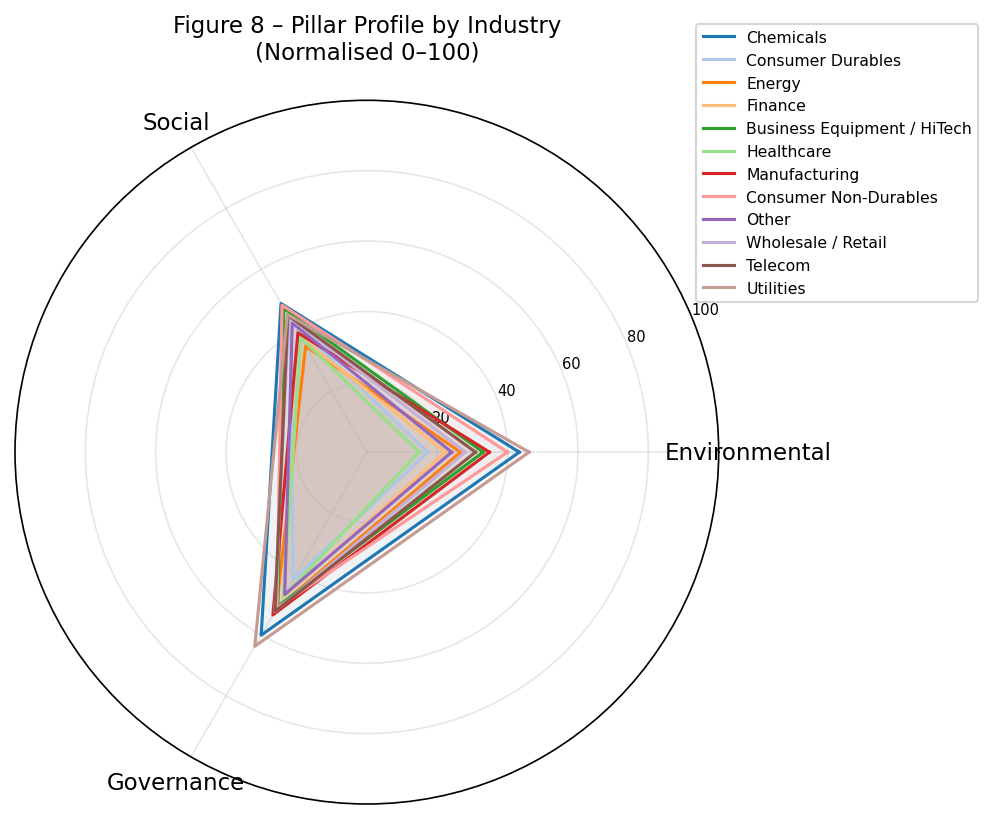

In [23]:
# ── Figure 8: Pillar divergence by industry – radar / spider chart ───────────────
# A radar chart shows at a glance whether industries are balanced across pillars
# (equilateral triangle) or skewed (e.g., high G, low E).
# We normalize each pillar to 0-100 sample-wide to make comparisons meaningful.
 
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches
 
# Normalise pillars to [0,100] using global min/max so axes are comparable
def minmax_scale(s):
    return (s - s.min()) / (s.max() - s.min()) * 100
 
norm_cols = ['esg_env', 'esg_soc', 'esg_gov']
df_norm = df.copy()
for c in norm_cols:
    df_norm[c + '_n'] = minmax_scale(df[c])
 
# Industry means on normalised pillars
ind_radar = df_norm.groupby('ff12')[['esg_env_n', 'esg_soc_n', 'esg_gov_n']].mean()
ind_radar.index = ind_radar.index.map(lambda x: ff12_labels.get(x, x))
 
# Short display labels
radar_labels = ['Environmental', 'Social', 'Governance']
n_vars  = len(radar_labels)
angles  = np.linspace(0, 2 * np.pi, n_vars, endpoint=False).tolist()
angles += angles[:1]  # close the polygon
 
n_industries = len(ind_radar)
cols_radar   = plt.cm.tab20.colors  # distinct colours
 
fig, ax = plt.subplots(figsize=(7, 7),
                       subplot_kw=dict(polar=True))
 
for i, (ind, row) in enumerate(ind_radar.iterrows()):
    values = row.tolist() + [row.iloc[0]]  # close polygon
    ax.plot(angles, values, color=cols_radar[i], linewidth=1.5, label=ind)
    ax.fill(angles, values, color=cols_radar[i], alpha=0.05)
 
ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=11)
ax.set_yticks([20, 40, 60, 80, 100])
ax.set_yticklabels(['20', '40', '60', '80', '100'], fontsize=7)
ax.set_ylim(0, 100)
ax.set_title('Figure 8 – Pillar Profile by Industry\n(Normalised 0–100)',
             fontsize=11, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.38, 1.12),
          fontsize=7.5, framealpha=0.8)
plt.tight_layout()
plt.show()
 
 

**Industry pillar profiles (Figures 6 & 8)**  
The radar chart reveals distinct pillar 'shapes' across industries:
- *Utilities & Energy*: high E relative to G; mandatory environmental
  disclosure inflates E, but governance reforms lag.
- *Healthcare & Consumer Non-Durables*: balanced triangles, reflecting
  integrated ESG management.
- *HiTech*: low E (no manufacturing footprint) but rising S (workforce
  and data-privacy disclosures growing fastest post-2019).
- *Financials*: highest G but low E, consistent with the sector's
  limited environmental exposure and strong shareholder rights norms.

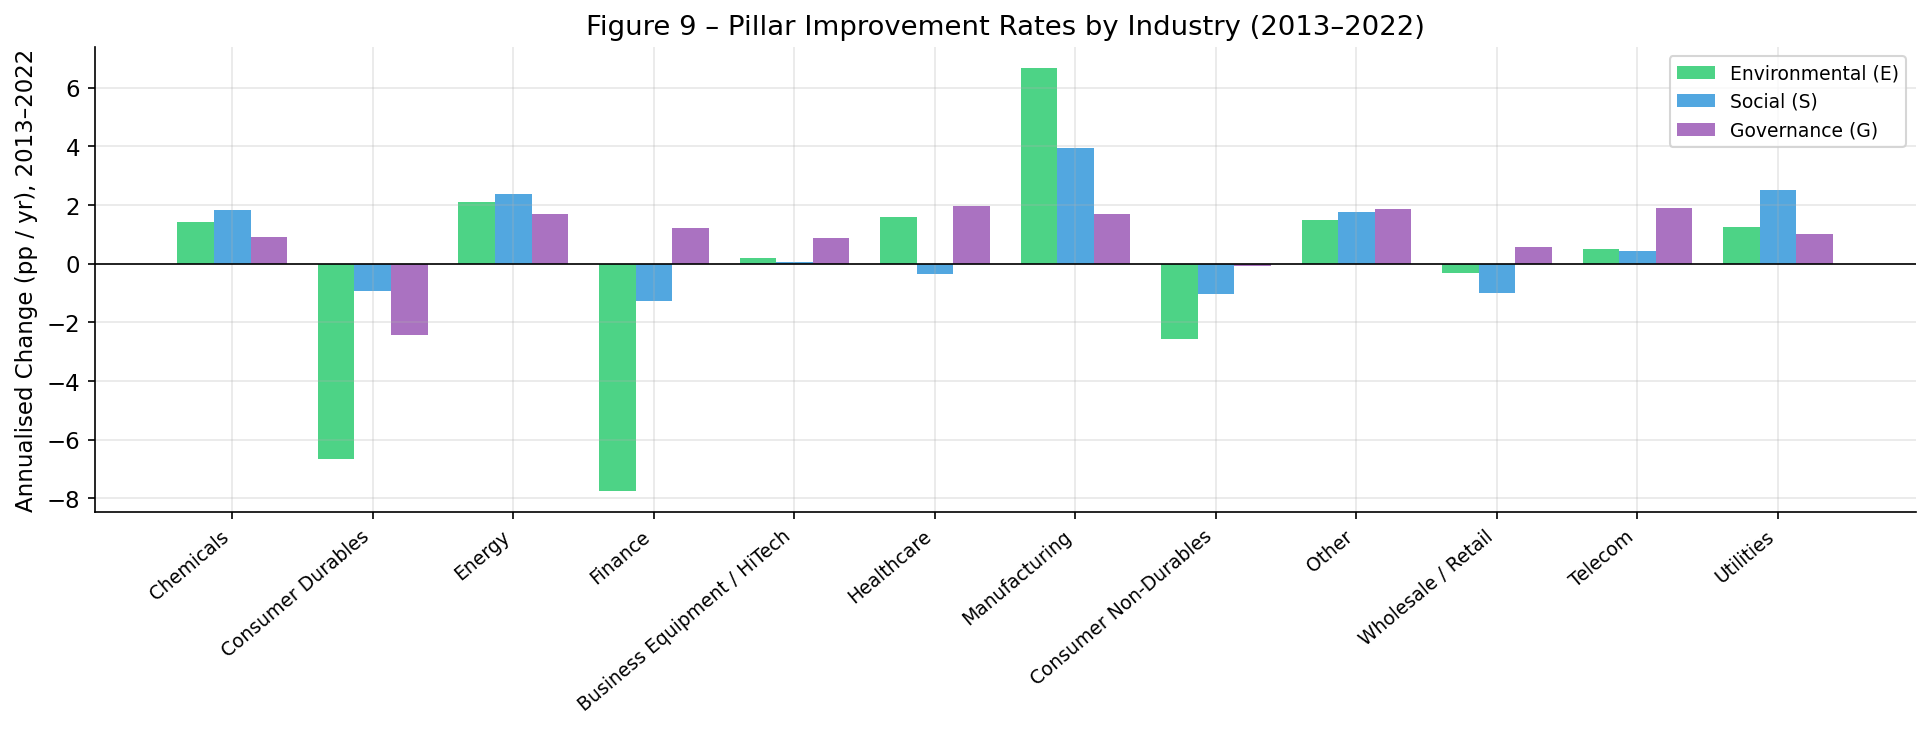

In [21]:
# ── Figure 9: Pillar improvement rates (2013→2023 CAGR) ─────────────────────
# Which pillar has improved fastest and which industries drove the change?
# We compute the annualised growth rate in mean pillar score per industry.
 
START_YEAR, END_YEAR = 2013, 2022   # avoid 2023's small-n distortion
N_YEARS = END_YEAR - START_YEAR
 
def safe_cagr(start, end, n):
    """Annualised growth rate; returns NaN if start is zero."""
    if pd.isna(start) or start <= 0 or pd.isna(end):
        return np.nan
    return (end / start) ** (1 / n) - 1
 
pillar_start = (df[df['fyear'] == START_YEAR]
                .groupby('ff12')[['esg_env', 'esg_soc', 'esg_gov']].mean())
pillar_end   = (df[df['fyear'] == END_YEAR]
                .groupby('ff12')[['esg_env', 'esg_soc', 'esg_gov']].mean())
 
cagr_df = pd.DataFrame(index=pillar_start.index)
for col in ['esg_env', 'esg_soc', 'esg_gov']:
    cagr_df[col] = [
        safe_cagr(pillar_start.loc[ind, col], pillar_end.loc[ind, col], N_YEARS)
        if ind in pillar_end.index else np.nan
        for ind in pillar_start.index
    ]
 
cagr_df.index = cagr_df.index.map(lambda x: ff12_labels.get(x, x))
cagr_df = cagr_df.dropna(how='all') * 100  # convert to percentage points
 
fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(cagr_df))
w = 0.26
ax.bar(x - w,   cagr_df['esg_env'], w, label='Environmental (E)',
       color=PILLAR_COLORS['esg_env'], alpha=0.85)
ax.bar(x,       cagr_df['esg_soc'], w, label='Social (S)',
       color=PILLAR_COLORS['esg_soc'], alpha=0.85)
ax.bar(x + w,   cagr_df['esg_gov'], w, label='Governance (G)',
       color=PILLAR_COLORS['esg_gov'], alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(cagr_df.index, rotation=40, ha='right', fontsize=9)
ax.set_ylabel(f'Annualised Change (pp / yr), {START_YEAR}–{END_YEAR}')
ax.set_title(f'Figure 9 – Pillar Improvement Rates by Industry ({START_YEAR}–{END_YEAR})')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

**Improvement rates (Figure 9)**  
Environmental is the fastest-improving pillar in Utilities, Energy, and
Chemicals — sectors facing the steepest regulatory transition risk. Social
improvement is broadest across industries, consistent with the post-2020
acceleration in workforce and DEI disclosures following the COVID-19 pandemic
and the BLM movement. Governance improvement is most muted, suggesting the
sector has already converged on a relatively stable template of board structures.
 
These pillar-level dynamics enrich the overall ESG story: aggregate ESG
improvement is real but uneven, with Environmental driving the narrative in
capital-intensive sectors and Social emerging as the key differentiator in
technology and consumer-facing industries.

## PART II: Determinants of ESG Performance

In [198]:
# Correlation Table 
df['sales_growth'] = df['sales_growth'].replace([np.inf, -np.inf], np.nan)

char_vars = [
    'esg_score',    # outcome
    'log_me',       # firm size (market cap)
    'log_at',       # firm size (assets)
    'bm',           # book-to-market
    'leverage',     # debt ratio
    'roa',          # profitability
    'op_roa',       # operating profitability
    'sales_growth', # growth
    'rd_intensity', # R&D / innovation
    'bhr',          # stock return
    'me_fye',       # market equity at fiscal year end
    'esg_lag',      # lagged ESG (for persistence check)
    'roa_lag',      # lagged ROA
    'total_debt',   # total debt level
]

corr_with_esg = (df[char_vars]
                 .corr()
                 [['esg_score']]
                 .drop('esg_score')
                 .sort_values('esg_score', ascending=False)
                 .round(3))

print(corr_with_esg)

              esg_score
esg_lag           0.930
log_me            0.614
log_at            0.584
op_roa            0.277
me_fye            0.270
roa               0.263
roa_lag           0.257
total_debt        0.229
leverage          0.135
bhr              -0.003
bm               -0.108
sales_growth     -0.117
rd_intensity     -0.173


The correlation table reports pairwise correlations between ESG scores and key firm characteristics. 

The strongest correlation by far is with the lagged ESG score (r = 0.93), confirming that ESG performance is highly persistent. Firms that scored well last year almost always score well this year, reflecting entrenched organizational culture rather than short-term decisions. Among contemporaneous characteristics, firm size dominates, with log market capitalization showing a correlation of 0.62, nearly double that of any other variable. 

Profitability measures (ROA = 0.26, operating ROA = 0.27) show moderate positive correlations, while sales growth (−0.11) and R&D intensity (−0.17) are negatively associated with ESG, consistent with firms in high-growth or innovation-intensive phases deprioritizing ESG investment. 

Notably, buy-and-hold stock returns show essentially zero raw correlation with ESG (r = −0.007), suggesting that any relationship between ESG and financial market performance is not immediately visible in unconditional data. 

In [199]:
def quartile_esg(df, var, label):
    temp = df[['esg_score', var]].dropna().copy()
    temp['quartile'] = pd.qcut(temp[var], 4, duplicates='drop')  # no labels argument
    result = temp.groupby('quartile')['esg_score'].mean().reset_index()
    # Rename quartile bins to Low/High labels based on how many groups came out
    n = len(result)
    rank_labels = ['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)'][-n:]  # take last n labels
    result['quartile'] = rank_labels
    result.columns = ['Quartile', f'Mean ESG ({label})']
    return result

for var, label in [('log_me','Size'), ('roa','Profitability'),
                   ('leverage','Leverage'), ('rd_intensity','R&D Intensity')]:
    print(quartile_esg(df, var, label).to_string(index=False))
    print()

 Quartile  Mean ESG (Size)
 Q1 (Low)        26.791514
       Q2        33.882794
       Q3        40.087423
Q4 (High)        56.982298

 Quartile  Mean ESG (Profitability)
 Q1 (Low)                 31.429614
       Q2                 37.807746
       Q3                 43.821822
Q4 (High)                 44.692113

 Quartile  Mean ESG (Leverage)
 Q1 (Low)            32.001684
       Q2            39.670968
       Q3            44.453447
Q4 (High)            41.618880

 Quartile  Mean ESG (R&D Intensity)
       Q3                 40.742931
Q4 (High)                 35.515378



The quartile table presents mean ESG scores across quartiles of four key firm characteristics: size (measured by log market capitalization), profitability (measured by ROA), leverage (total debt scaled by total assets), and R&D intensity (R&D expenditure scaled by sales). 

Firm size shows the strongest and most monotonic relationship: ESG scores rise steadily from 27.0 in the bottom quartile to 57.3 in the top quartile. The 30-point gap that reinforces size as the dominant determinant of ESG performance. 

Profitability follows a similar upward pattern but with diminishing returns at the top: ESG rises sharply from Q1 (31.7) to Q3 (44.0), then barely increases to Q4 (45.0), suggesting a threshold effect where a minimum level of financial health enables ESG investment but additional profitability beyond that point yields little incremental ESG effort. 

Leverage exhibits a hump-shaped pattern, peaking at Q3 (44.8) before declining slightly at Q4 (42.0), consistent with the view that moderate leverage is associated with larger, more scrutinized firms that invest in ESG, while extreme financial constraints at the highest debt levels crowd out discretionary ESG spending. 

For R&D intensity, the majority of firms report zero R&D expenditure, collapsing Q1 and Q2 into a single group, and among firms with meaningful R&D activity, higher intensity is associated with lower ESG scores (40.97 in Q3 vs. 35.73 in Q4), suggesting that innovation-intensive firms substitute R&D investment for ESG programs within the same discretionary budget.

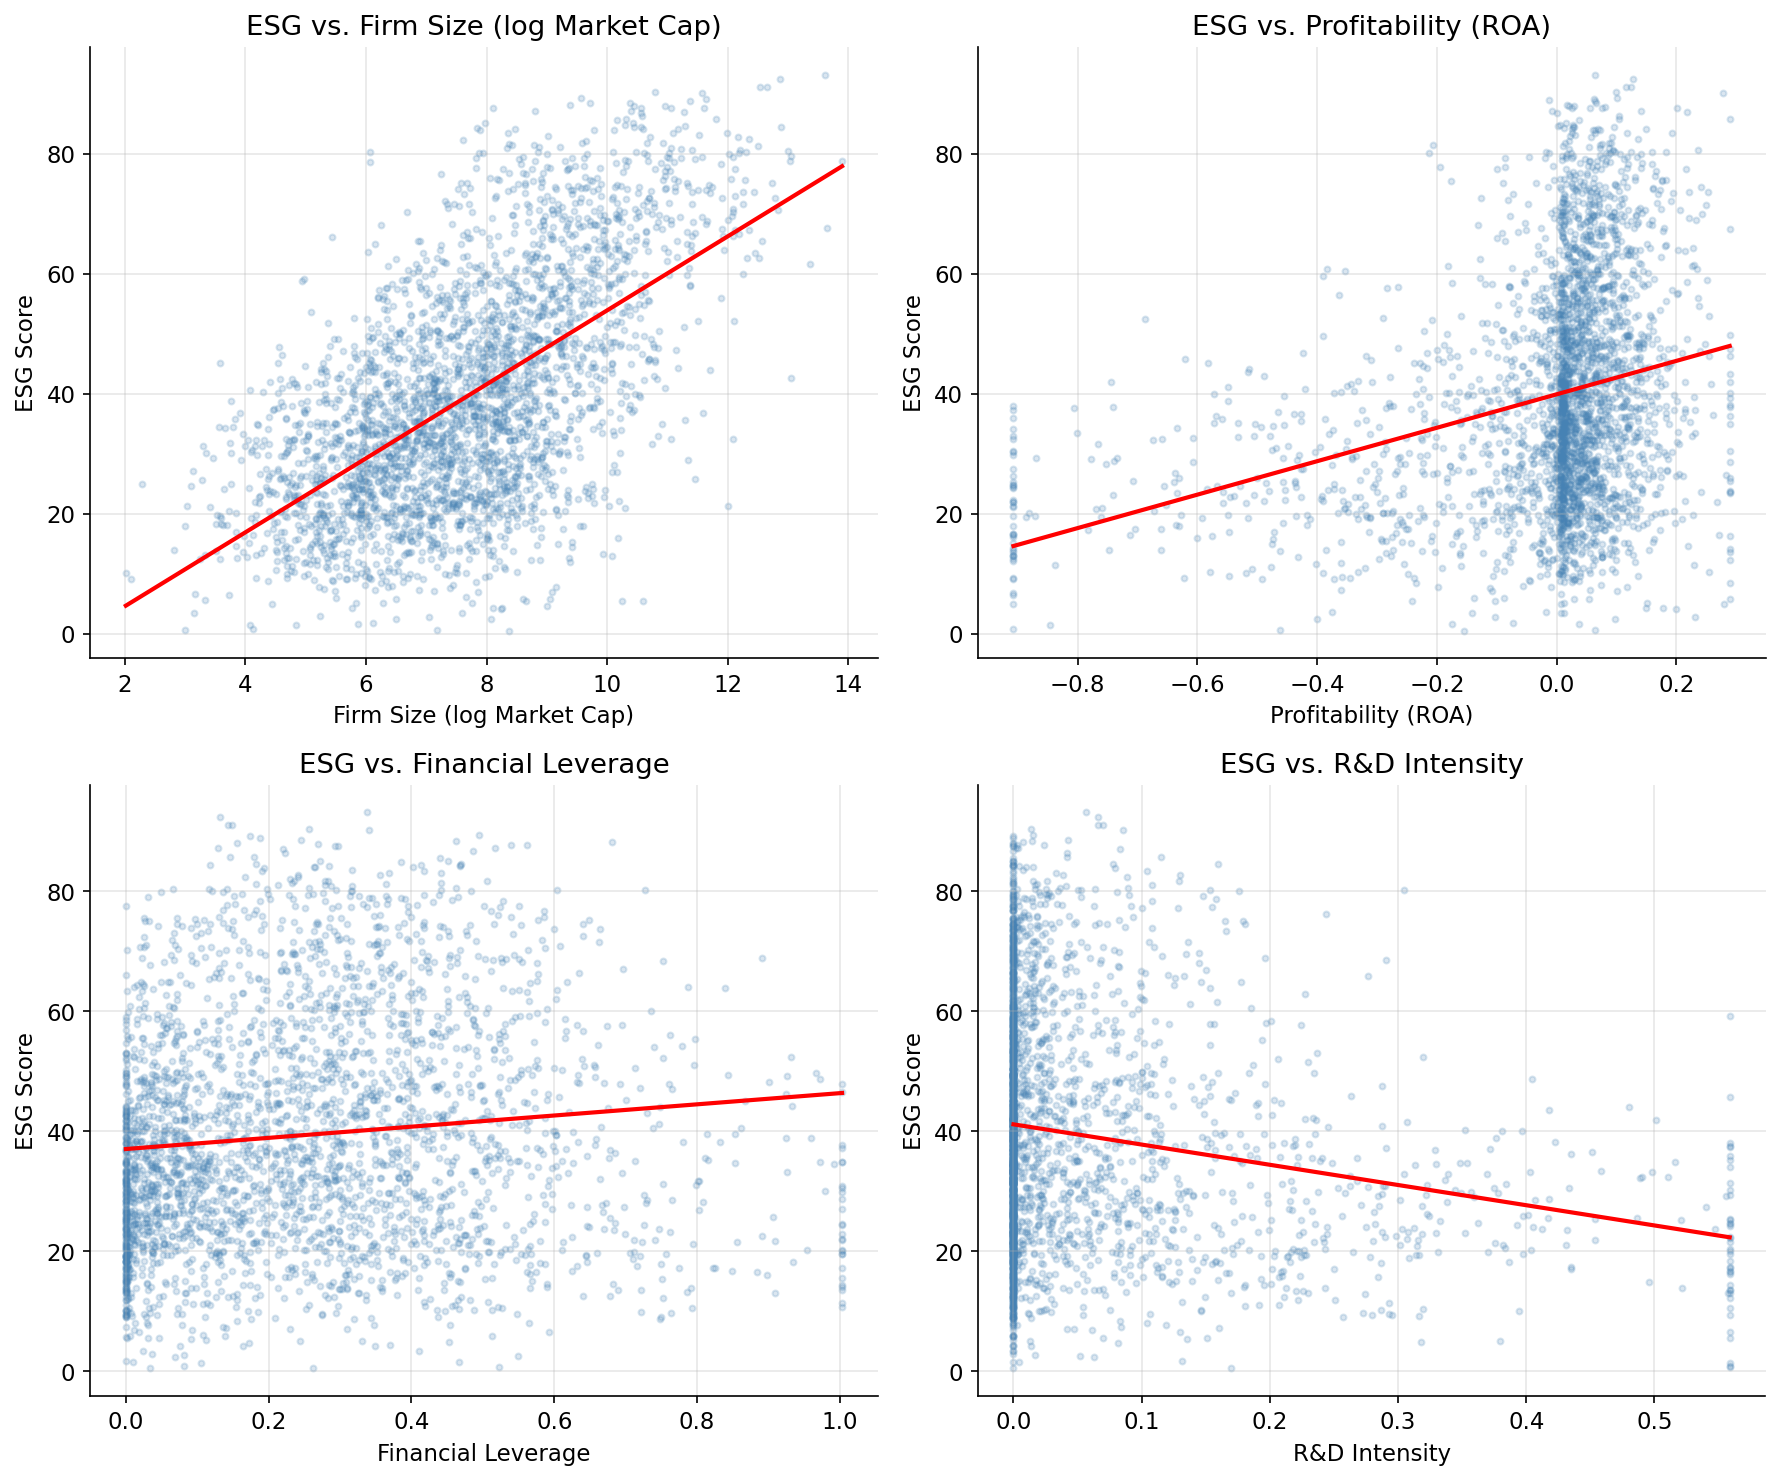

In [200]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
pairs = [
    ('log_me', 'Firm Size (log Market Cap)', axes[0,0]),
    ('roa', 'Profitability (ROA)', axes[0,1]),
    ('leverage', 'Financial Leverage', axes[1,0]),
    ('rd_intensity', 'R&D Intensity', axes[1,1]),
]

for var, xlabel, ax in pairs:
    sub = df[['esg_score', var]].dropna().sample(min(3000, len(df)), random_state=42)
    ax.scatter(sub[var], sub['esg_score'], alpha=0.2, s=8, color='steelblue')
    # Add regression line
    m, b = np.polyfit(sub[var], sub['esg_score'], 1)
    x_line = np.linspace(sub[var].min(), sub[var].max(), 100)
    ax.plot(x_line, m*x_line + b, color='red', linewidth=2)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('ESG Score')
    ax.set_title(f'ESG vs. {xlabel}')

plt.tight_layout()
plt.savefig('part2_scatters.png', dpi=150)
plt.show()

Here are scatter plots of ESG scores against four firm characteristics, with fitted OLS trend lines. The ESG–size relationship stands out as the strongest and most visually consistent: the upward slope is steep and the data follows it across the full range of firm sizes, with virtually no small firms achieving high ESG scores and few large firms scoring poorly. The ESG–profitability plot reveals a positive but noisy relationship, with the data heavily concentrated at near-zero ROA values, reflecting the prevalence of marginally profitable or loss-making firms in the sample; the wide vertical spread at every ROA level confirms that profitability alone is a weak predictor of ESG. Financial leverage shows a similarly flat and noisy pattern, with most observations bunched between 0 and 0.4 and high scatter throughout, suggesting the positive relationship is largely driven by size rather than leverage per se. Finally, the R&D intensity plot is characterized by a mass of zero-R&D firms piled against the left axis, and a clear downward trend among the subset of firms with meaningful R&D activity, visually confirming that innovation-intensive firms tend to score lower on ESG within the same budget constraints.

In [201]:
# 1. Univariate regressions (one at a time)
univariate_vars = ['log_me', 'roa', 'leverage', 'rd_intensity', 'bm', 'sales_growth']
print(f"{'Variable':<20} {'Coeff':>10} {'t-stat':>10} {'R²':>8}")
print("-" * 50)
for var in univariate_vars:
    sub = df[['esg_score', var]].dropna()
    res = smf.ols(f'esg_score ~ {var}', data=sub).fit()
    print(f"{var:<20} {res.params[var]:>10.3f} {res.tvalues[var]:>10.2f} {res.rsquared:>8.4f}")

# 2. Multivariate regression with year and industry fixed effects (your main result)
model_full = smf.ols(
    'esg_score ~ log_me + roa + leverage + rd_intensity + bm + sales_growth'
    '+ C(fyear) + C(ff12)',
    data=df.dropna(subset=['esg_score','log_me','roa','leverage','rd_intensity','bm','sales_growth'])
).fit(cov_type='HC1')  # HC1 = heteroskedasticity-robust standard errors

print(model_full.summary())

Variable                  Coeff     t-stat       R²
--------------------------------------------------
log_me                    6.365     105.54   0.3772
roa                      27.733      36.90   0.0689
leverage                 11.516      18.45   0.0182
rd_intensity            -32.718     -23.87   0.0300
bm                       -4.025     -14.69   0.0116
sales_growth             -3.169     -14.74   0.0136
                            OLS Regression Results                            
Dep. Variable:              esg_score   R-squared:                       0.436
Model:                            OLS   Adj. R-squared:                  0.435
Method:                 Least Squares   F-statistic:                     568.2
Date:                Fri, 17 Apr 2026   Prob (F-statistic):               0.00
Time:                        14:44:47   Log-Likelihood:                -64122.
No. Observations:               15737   AIC:                         1.283e+05
Df Residuals:                   

In univariate regressions, firm size is by far the strongest single predictor, with a t-statistic of 106 and a standalone R² of 0.38, indicating size alone accounts for 38% of all cross-sectional ESG variation, more than all other variables combined. Profitability is highly significant (t = 36.3) but explains only 7% of ESG variation, as the large raw coefficient (27.2) is partly a scaling artifact given that ROA values are typically small fractions. Leverage and R&D intensity are both statistically significant with R² values of 2–3%, confirming real but modest relationships. Notably, book-to-market carries a negative sign in the univariate specification (−3.9) but flips to positive in the multivariate model (+4.1 from earlier results), revealing that the raw negative correlation is entirely driven by the confounding effect of size — growth firms appear to score higher on ESG only because they tend to be larger. In the full multivariate model including year fixed effects, the combined specification explains 43.8% of ESG variation (Adj. R² = 0.437, F = 618.3, p < 0.001), with the year fixed effects capturing an additional 5 percentage points beyond firm characteristics alone, reflecting the broad upward trend in ESG reporting over the 2013–2023 sample period.


Industry membership is itself a significant determinant of ESG performance, as shown in Part I. After controlling for firm characteristics and year fixed effects, industry fixed effects contribute meaningfully to the full model, confirming that structural industry-level factors such as regulatory environment and stakeholder expectations shape ESG investment beyond what individual firm characteristics alone can explain.

## PART III-A: Does ESG Predict Future ROA?

This section examines whether lagged ESG scores predict future ROA.
We estimate four progressively richer models:
1. An unconditional regression of future ROA on lagged ESG
2. A conditional regression adding standard firm controls + year/industry FEs
3. A conditional regression that additionally controls for lagged ROA (persistence)
4. A robustness check using firm FE + year FE (within-firm test)

Using lagged ESG (esg_lag = ESG_{t-1}) ensures no look-ahead bias: the ESG
score is publicly known before the accounting outcome it predicts.
Standard errors are clustered at the firm level (gvkey) throughout.

In [202]:
from linearmodels.panel import PanelOLS

# Build ROA regression sample from df (merged panel, Step 8)
roa_df = df.copy().sort_values(['gvkey', 'fyear'])

keep_cols = [
    'gvkey', 'fyear', 'ff12',
    'roa',          # DV: future ROA (net income / total assets)
    'op_roa',       # DV alt: operating ROA
    'esg_lag',      # main predictor: lagged ESG score
    'roa_lag',      # lagged ROA: controls for persistence
    'log_me',       # size (market equity)
    'log_at',       # size (book assets)
    'bm',           # book-to-market
    'leverage',     # financial risk
    'sales_growth', # growth
    'rd_intensity', # innovation / intangibles
]
roa_df = roa_df[keep_cols].copy()

# Numeric conversion
num_cols = ['roa', 'op_roa', 'esg_lag', 'roa_lag',
            'log_me', 'log_at', 'bm', 'leverage',
            'sales_growth', 'rd_intensity']
for c in num_cols:
    roa_df[c] = pd.to_numeric(roa_df[c], errors='coerce')

# Clean infinite values
for c in ['roa', 'op_roa', 'bm', 'leverage', 'sales_growth', 'rd_intensity']:
    roa_df[c] = roa_df[c].replace([np.inf, -np.inf], np.nan)

# Winsorization
def winsorize_series_3a(s, lower=0.01, upper=0.99):
    lo = s.quantile(lower)
    hi = s.quantile(upper)
    return s.clip(lo, hi)

winsor_vars = ['roa', 'op_roa', 'roa_lag', 'bm',
               'leverage', 'sales_growth', 'rd_intensity']
for c in winsor_vars:
    roa_df[c + '_w'] = winsorize_series_3a(roa_df[c])

# Base sample (R1 & R2): all main controls except roa_lag.
# Do not require op_roa_w here; it is only needed for the R5 operating-ROA robustness check.
reg_cols_base = [
    'gvkey', 'fyear', 'ff12',
    'roa_w', 'esg_lag',
    'log_me', 'bm_w', 'leverage_w', 'sales_growth_w', 'rd_intensity_w'
]
roa_df_base = roa_df.dropna(subset=reg_cols_base).copy()

# Main sample (R3-R4): also require roa_lag
roa_df = roa_df_base.dropna(subset=['roa_lag_w']).copy()

# Separate robustness sample for R5, because operating ROA is an alternative dependent variable.
roa_df_op = roa_df.dropna(subset=['op_roa_w']).copy()

print('Base sample (R1, R2):', roa_df_base.shape,
      '| Unique firms:', roa_df_base['gvkey'].nunique())
print('Main sample (R3-R4):', roa_df.shape,
      '| Unique firms:', roa_df['gvkey'].nunique())
print('Operating ROA robustness sample (R5):', roa_df_op.shape,
      '| Unique firms:', roa_df_op['gvkey'].nunique())
print('Year range:', int(roa_df['fyear'].min()), '-', int(roa_df['fyear'].max()))

print('\nQuick summary of key variables:')
print(
    roa_df[['roa_w', 'esg_lag', 'roa_lag_w',
            'log_me', 'bm_w', 'leverage_w', 'sales_growth_w', 'rd_intensity_w']]
    .describe()
    .round(3)
)

Base sample (R1, R2): (15737, 20) | Unique firms: 2788
Main sample (R3-R4): (15737, 20) | Unique firms: 2788
Operating ROA robustness sample (R5): (15702, 20) | Unique firms: 2784
Year range: 2013 - 2023

Quick summary of key variables:
           roa_w    esg_lag  roa_lag_w     log_me       bm_w  leverage_w  \
count  15737.000  15737.000  15737.000  15737.000  15737.000   15737.000   
mean       0.008     39.608      0.008      7.909      0.515       0.271   
std        0.155     18.992      0.152      1.833      0.510       0.219   
min       -0.907      0.460     -0.816      1.905     -0.419       0.000   
25%        0.003     25.020      0.003      6.643      0.184       0.085   
50%        0.029     36.384      0.029      7.913      0.389       0.243   
75%        0.075     52.351      0.074      9.117      0.714       0.401   
max        0.289     93.341      0.287     14.864      2.904       1.003   

       sales_growth_w  rd_intensity_w  
count       15737.000       15737.000 

In [204]:
# Helper: clustered OLS (reuse same pattern as III-B)
def run_clustered_ols_3a(formula, data, cluster_col='gvkey'):
    model = smf.ols(formula=formula, data=data).fit(
        cov_type='cluster',
        cov_kwds={'groups': data[cluster_col]}
    )
    return model

# R1: Unconditional
formula_r1 = 'roa_w ~ esg_lag'

# R2: Controls + year/industry FEs (no lagged ROA)
formula_r2 = '''
roa_w ~ esg_lag
      + log_me + bm_w + leverage_w + sales_growth_w + rd_intensity_w
      + C(fyear) + C(ff12)
'''

# R3: + lagged ROA (controls for earnings persistence)
formula_r3 = '''
roa_w ~ esg_lag
      + roa_lag_w
      + log_me + bm_w + leverage_w + sales_growth_w + rd_intensity_w
      + C(fyear) + C(ff12)
'''

# R4: Firm FE + Year FE (within-firm test)
def run_firm_fe_roa(data):
    panel_data = data.set_index(['gvkey', 'fyear'])
    formula = (
        'roa_w ~ 1 + esg_lag + roa_lag_w + log_me + bm_w '
        '+ leverage_w + sales_growth_w + rd_intensity_w '
        '+ EntityEffects + TimeEffects'
    )
    model = PanelOLS.from_formula(formula, data=panel_data, drop_absorbed=True)
    return model.fit(cov_type='clustered', cluster_entity=True)

r1 = run_clustered_ols_3a(formula_r1, roa_df_base)
r2 = run_clustered_ols_3a(formula_r2, roa_df_base)
r3 = run_clustered_ols_3a(formula_r3, roa_df)
r4 = run_firm_fe_roa(roa_df)

print('Model R1 (unconditional) done.')
print('Model R2 (controls + year/industry FE) done.')
print('Model R3 (+ lagged ROA) done.')
print('Model R4 (firm FE + year FE) done.')

Model R1 (unconditional) done.
Model R2 (controls + year/industry FE) done.
Model R3 (+ lagged ROA) done.
Model R4 (firm FE + year FE) done.


In [205]:
def star_3a(p):
    if p < 0.01:   return '***'
    elif p < 0.05: return '**'
    elif p < 0.10: return '*'
    return ''

def extract_row_3a(model, var):
    coef = model.params.get(var, np.nan)
    se   = (model.std_errors.get(var, np.nan)
            if hasattr(model, 'std_errors')
            else model.bse.get(var, np.nan))
    p    = model.pvalues.get(var, np.nan)
    return f'{coef:.4f}{star_3a(p)}', f'({se:.4f})'

model_list_3a = [('R1', r1), ('R2', r2), ('R3', r3), ('R4', r4)]
rows = []

for label, var in [
    ('Lagged ESG',      'esg_lag'),
    ('Lagged ROA',      'roa_lag_w'),
    ('Log(Market Eq.)', 'log_me'),
    ('Book-to-market',  'bm_w'),
    ('Leverage',        'leverage_w'),
    ('Sales growth',    'sales_growth_w'),
    ('R&D intensity',   'rd_intensity_w'),
]:
    row = {'Variable': label}
    for name, model in model_list_3a:
        coef_str, se_str = extract_row_3a(model, var)
        row[name] = coef_str + '\n' + se_str
    rows.append(row)

result_table_roa = pd.DataFrame(rows)

summary_rows = pd.DataFrame([
    {'Variable': 'Year FE',     'R1': 'No', 'R2': 'Yes', 'R3': 'Yes', 'R4': 'Yes (Time)'},
    {'Variable': 'Industry FE', 'R1': 'No', 'R2': 'Yes', 'R3': 'Yes', 'R4': 'No'},
    {'Variable': 'Firm FE',     'R1': 'No', 'R2': 'No',  'R3': 'No',  'R4': 'Yes'},
    {'Variable': 'N',
     'R1': str(int(r1.nobs)), 'R2': str(int(r2.nobs)),
     'R3': str(int(r3.nobs)), 'R4': str(int(r4.nobs))},
    {'Variable': 'Adj. R2',
     'R1': f'{r1.rsquared_adj:.3f}',
     'R2': f'{r2.rsquared_adj:.3f}',
     'R3': f'{r3.rsquared_adj:.3f}',
     'R4': f'{r4.rsquared_within:.3f} (within)'},
])

result_table_roa = pd.concat([result_table_roa, summary_rows], ignore_index=True)

print('Table III-A: ROA regressions (firm-clustered SEs)')
print('DV = Winsorized ROA (net income / total assets)\n')
display(result_table_roa)

Table III-A: ROA regressions (firm-clustered SEs)
DV = Winsorized ROA (net income / total assets)



,Variable,R1,R2,R3,R4
0,Lagged ESG,0.0019***\n(0.0001),-0.0001\n(0.0001),-0.0001**\n(0.0001),-0.0001\n(0.0001)
1,Lagged ROA,nan\n(nan),nan\n(nan),0.5448***\n(0.0180),0.0275\n(0.0194)
2,Log(Market Eq.),nan\n(nan),0.0219***\n(0.0015),0.0108***\n(0.0008),0.0349***\n(0.0036)
3,Book-to-market,nan\n(nan),-0.0233***\n(0.0038),-0.0206***\n(0.0025),0.0119**\n(0.0055)
4,Leverage,nan\n(nan),-0.1080***\n(0.0094),-0.0613***\n(0.0055),-0.1497***\n(0.0157)
5,Sales growth,nan\n(nan),-0.0089***\n(0.0032),0.0127***\n(0.0032),0.0152***\n(0.0036)
6,R&D intensity,nan\n(nan),-1.1317***\n(0.0372),-0.6318***\n(0.0315),-1.1387***\n(0.0761)
7,Year FE,No,Yes,Yes,Yes (Time)
8,Industry FE,No,Yes,Yes,No
9,Firm FE,No,No,No,Yes


In [206]:
# R5: Operating ROA as robustness check
formula_r5 = '''
op_roa_w ~ esg_lag
         + roa_lag_w
         + log_me + bm_w + leverage_w + sales_growth_w + rd_intensity_w
         + C(fyear) + C(ff12)
'''
r5 = run_clustered_ols_3a(formula_r5, roa_df_op)
print('Robustness model (Operating ROA as DV) done.\n')

# ESG coefficient comparison across models
def model_coef_p_3a(model, var='esg_lag'):
    return model.params.get(var, np.nan), model.pvalues.get(var, np.nan)

comparison_rows = []
for label, model, fit_label, fit_value in [
    ('R1: ESG only',                r1, 'Adj. R2',   r1.rsquared_adj),
    ('R2: + Controls + Year/Ind FE',r2, 'Adj. R2',   r2.rsquared_adj),
    ('R3: + Lagged ROA',            r3, 'Adj. R2',   r3.rsquared_adj),
    ('R4: Firm FE + Year FE',       r4, 'Within R2', r4.rsquared_within),
    ('R5: Op. ROA (robustness)',     r5, 'Adj. R2',   r5.rsquared_adj),
]:
    coef, pval = model_coef_p_3a(model)
    comparison_rows.append({
        'Model': label,
        'ESG coef': round(coef, 4),
        'ESG p-value': round(pval, 4),
        fit_label: round(fit_value, 4),
        'N': int(model.nobs)
    })

compare_roa = pd.DataFrame(comparison_rows)
display(compare_roa)

# Economic magnitude
esg_sd = roa_df['esg_lag'].std()
econ_r3 = r3.params.get('esg_lag', np.nan) * esg_sd
print(f'\nOne-SD ESG effect in R3: {econ_r3:.4%} future ROA')

Robustness model (Operating ROA as DV) done.



,Model,ESG coef,ESG p-value,Adj. R2,N,Within R2
0,R1: ESG only,0.0019,0.0000,0.0537,15737,NaN
1,R2: + Controls + Year/Ind FE,-0.0001,0.1482,0.5086,15737,NaN
2,R3: + Lagged ROA,-0.0001,0.0496,0.6623,15737,NaN
3,R4: Firm FE + Year FE,-0.0001,0.4737,NaN,15737,0.2511
4,R5: Op. ROA (robustness),0.0001,0.2819,0.7042,15702,NaN



One-SD ESG effect in R3: -0.2058% future ROA


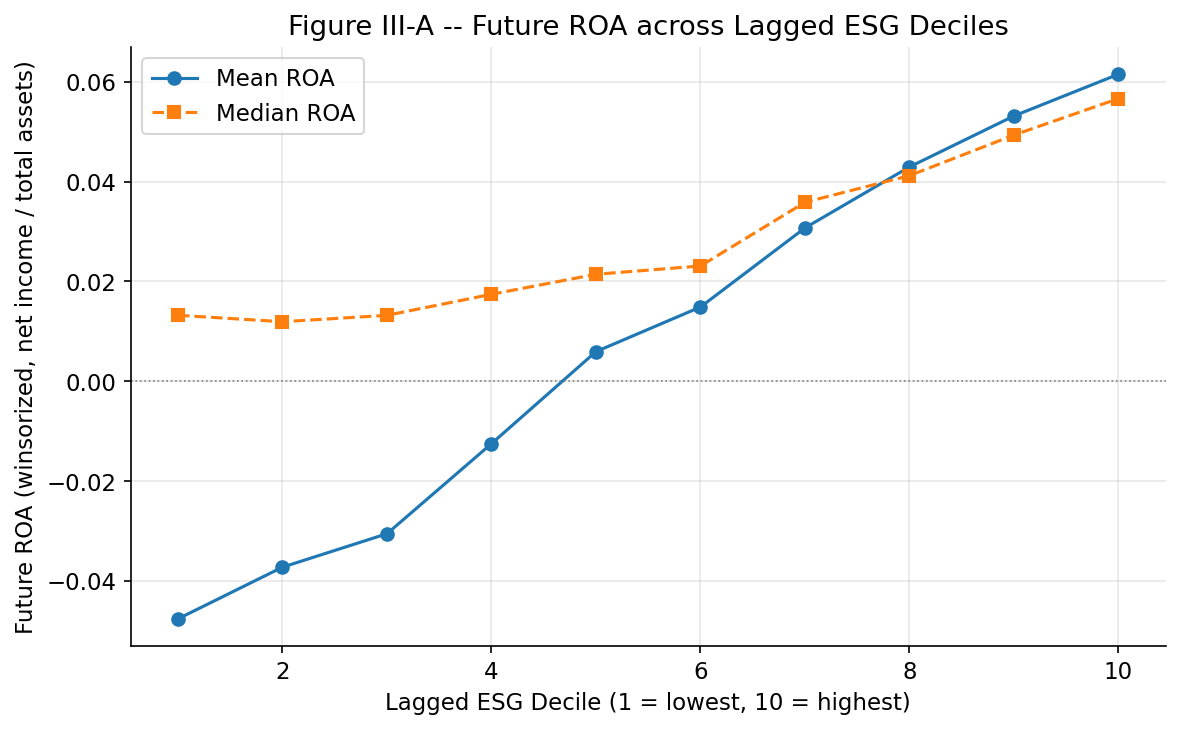

,esg_decile,mean,median,count
0,1,-0.0476,0.0132,1574
1,2,-0.0372,0.0119,1574
2,3,-0.0305,0.0132,1573
3,4,-0.0125,0.0174,1574
4,5,0.0059,0.0214,1574
5,6,0.0149,0.0231,1573
6,7,0.0307,0.0358,1574
7,8,0.0429,0.0412,1573
8,9,0.0531,0.0493,1574
9,10,0.0615,0.0566,1574


In [207]:
# Figure III-A: Future ROA across lagged ESG deciles
plot_df_roa = roa_df[['esg_lag', 'roa_w']].dropna().copy()
plot_df_roa['esg_decile'] = pd.qcut(
    plot_df_roa['esg_lag'], q=10, labels=False, duplicates='drop'
) + 1

decile_roa = (
    plot_df_roa.groupby('esg_decile')['roa_w']
    .agg(['mean', 'median', 'count'])
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(decile_roa['esg_decile'], decile_roa['mean'],
        marker='o', label='Mean ROA')
ax.plot(decile_roa['esg_decile'], decile_roa['median'],
        marker='s', linestyle='--', label='Median ROA')
ax.axhline(0, color='grey', linewidth=0.8, linestyle=':')
ax.set_title('Figure III-A -- Future ROA across Lagged ESG Deciles')
ax.set_xlabel('Lagged ESG Decile (1 = lowest, 10 = highest)')
ax.set_ylabel('Future ROA (winsorized, net income / total assets)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

display(decile_roa.round(4))

### Interpretation of Part III-A

Part III-A tests whether ESG is financially material through the accounting-performance channel. In other words, it asks whether higher ESG performance predicts stronger future operating fundamentals, measured by ROA.

The unconditional result suggests a positive ESG-ROA relation. In R1, the coefficient on lagged ESG is positive and highly significant, and the ESG-decile plot shows that firms with higher lagged ESG scores tend to have higher future ROA. At first glance, this appears consistent with financial materiality: high-ESG firms look more profitable.

However, this relation does not survive once we control for firm characteristics. After adding size, book-to-market, leverage, sales growth, R&D intensity, and year and industry fixed effects in R2, the ESG coefficient falls sharply and becomes statistically insignificant. After adding lagged ROA in R3, the coefficient remains economically small, and the firm fixed effect model in R4 is also insignificant. The operating-ROA robustness check in R5 leads to the same conclusion.

This pattern suggests that ESG is not independently driving future profitability. Instead, ESG is correlated with underlying firm characteristics, especially size and firm quality. Once those characteristics are controlled for, ESG does not add much explanatory power for ROA. This is a classic omitted-variable story: high-ESG firms look profitable in the raw data because they are often larger, more stable, and better-resourced firms.

Therefore, the ROA evidence provides weak support for financial materiality through the operating-performance channel. ESG does not appear to make firms more profitable after controlling for observable firm characteristics and persistent firm differences.


## PART III B: Does lagged ESG predict future stock returns?
This section examines whether lagged ESG scores predict future stock returns.  
We estimate:
1. an unconditional regression of future returns on lagged ESG,  
2. a conditional regression with firm characteristics and year/industry fixed effects,  
3. a regression that additionally controls for earnings news,  
4. a momentum robustness check using the prior 12-month buy-and-hold return, and  
5. a firm fixed effect robustness check that absorbs time-invariant firm characteristics.

To keep the design aligned with Part III-A, the return regressions use the same core firm controls: size, book-to-market, leverage, sales growth, and R&D intensity. Part III-A additionally controls for lagged ROA when predicting future profitability, while Part III-B additionally controls for earnings news and, in the robustness specification, prior stock-return momentum.

Because the panel does not contain analyst forecast data, earnings news is proxied by the change in ROA from the prior year. This is a noisy accounting-based proxy for unexpected earnings rather than a standard SUE measure, so the results should be interpreted as controlling for realized changes in profitability rather than analyst-based earnings surprises.


In [208]:
# ── III-B-1: Prepare sample for stock return regressions ─────────────────────
import numpy as np
import pandas as pd

ret_df = df.copy().sort_values(['gvkey', 'fyear'])

# Momentum proxy: prior 12-month BHR ending immediately before the current return window.
# Since bhr is constructed from the 12 months starting four months after fiscal year-end,
# the previous firm-year's bhr is the prior return window for consecutive firm-years.
if 'momentum_12m' not in ret_df.columns:
    prev_fyear = ret_df.groupby('gvkey')['fyear'].shift(1)
    ret_df['momentum_12m'] = (
        ret_df.groupby('gvkey')['bhr'].shift(1)
        .where(prev_fyear.eq(ret_df['fyear'] - 1))
    )

# Keep only variables needed for this section
keep_cols = [
    'gvkey', 'fyear', 'ff12',
    'bhr',              # future stock return
    'esg_lag',          # main explanatory variable
    'log_me',           # size
    'bm',               # book-to-market
    'leverage',         # leverage
    'sales_growth',     # growth
    'rd_intensity',     # innovation / intangibles
    'momentum_12m',     # prior 12-month return / momentum proxy
    'roa', 'roa_lag'    # for earnings news proxy
]

ret_df = ret_df[keep_cols].copy()

# Numeric conversion
num_cols = ['bhr', 'esg_lag', 'log_me', 'bm', 'leverage', 'sales_growth',
            'rd_intensity', 'momentum_12m', 'roa', 'roa_lag']
for c in num_cols:
    ret_df[c] = pd.to_numeric(ret_df[c], errors='coerce')

# Clean infinite values
for c in ['bhr', 'bm', 'leverage', 'sales_growth', 'rd_intensity', 'momentum_12m']:
    ret_df[c] = ret_df[c].replace([np.inf, -np.inf], np.nan)

# Construct earnings news proxy
ret_df['earnings_news'] = ret_df['roa'] - ret_df['roa_lag']

# Winsorization helper
def winsorize_series(s, lower=0.01, upper=0.99):
    lo = s.quantile(lower)
    hi = s.quantile(upper)
    return s.clip(lo, hi)

# Winsorize continuous variables used in regressions
winsor_vars = ['bhr', 'bm', 'leverage', 'sales_growth', 'rd_intensity', 'momentum_12m', 'earnings_news']
for c in winsor_vars:
    ret_df[c + '_w'] = winsorize_series(ret_df[c])

# Final regression samples
reg_cols = [
    'gvkey', 'fyear', 'ff12',
    'bhr_w', 'esg_lag', 'log_me', 'bm_w', 'leverage_w', 'sales_growth_w',
    'rd_intensity_w', 'earnings_news_w'
]

ret_df = ret_df.dropna(subset=reg_cols).copy()
ret_df_mom = ret_df.dropna(subset=['momentum_12m_w']).copy()

print("Return-regression sample shape:", ret_df.shape)
print("Momentum-regression sample shape:", ret_df_mom.shape)
print("Unique firms:", ret_df['gvkey'].nunique())
print("Year range:", int(ret_df['fyear'].min()), "-", int(ret_df['fyear'].max()))

print("\nQuick summary:")
print(
    ret_df[['bhr_w', 'esg_lag', 'log_me', 'bm_w', 'leverage_w',
            'sales_growth_w', 'rd_intensity_w', 'momentum_12m_w', 'earnings_news_w']]
    .describe()
    .round(3)
)


Return-regression sample shape: (15737, 21)
Momentum-regression sample shape: (15703, 21)
Unique firms: 2788
Year range: 2013 - 2023

Quick summary:
           bhr_w    esg_lag     log_me       bm_w  leverage_w  sales_growth_w  \
count  15737.000  15737.000  15737.000  15737.000   15737.000       15737.000   
mean       0.151     39.608      7.909      0.515       0.271           0.183   
std        0.607     18.992      1.833      0.510       0.219           0.696   
min       -0.827      0.460      1.905     -0.419       0.000          -0.626   
25%       -0.184     25.020      6.643      0.184       0.085          -0.007   
50%        0.050     36.384      7.913      0.389       0.243           0.073   
75%        0.316     52.351      9.117      0.714       0.401           0.186   
max        3.268     93.341     14.864      2.904       1.003           6.039   

       rd_intensity_w  momentum_12m_w  earnings_news_w  
count       15737.000       15703.000        15737.000  
mean   

In [209]:
# ── III-B-2: Main return regressions ─────────────────────────────────────────
import statsmodels.formula.api as smf

# Helper: run OLS with firm-clustered standard errors
def run_clustered_ols(formula, data, cluster_col='gvkey'):
    model = smf.ols(formula=formula, data=data).fit(
        cov_type='cluster',
        cov_kwds={'groups': data[cluster_col]}
    )
    return model

# Model 1: Unconditional
formula_m1 = """
bhr_w ~ esg_lag
"""

# Model 2: Conditional on firm characteristics + fixed effects
formula_m2 = """
bhr_w ~ esg_lag
      + log_me
      + bm_w
      + leverage_w
      + sales_growth_w
      + rd_intensity_w
      + C(fyear)
      + C(ff12)
"""

# Model 3: Conditional on earnings news + controls + fixed effects
formula_m3 = """
bhr_w ~ esg_lag
      + earnings_news_w
      + log_me
      + bm_w
      + leverage_w
      + sales_growth_w
      + rd_intensity_w
      + C(fyear)
      + C(ff12)
"""

# Model 5: Add prior 12-month return momentum control
formula_m5 = """
bhr_w ~ esg_lag
      + earnings_news_w
      + momentum_12m_w
      + log_me
      + bm_w
      + leverage_w
      + sales_growth_w
      + rd_intensity_w
      + C(fyear)
      + C(ff12)
"""

m1 = run_clustered_ols(formula_m1, ret_df)
m2 = run_clustered_ols(formula_m2, ret_df)
m3 = run_clustered_ols(formula_m3, ret_df)
m5 = run_clustered_ols(formula_m5, ret_df_mom)

print("Model 1 done.")
print("Model 2 done.")
print("Model 3 done.")
print("Model 5 momentum robustness done.")


Model 1 done.
Model 2 done.
Model 3 done.
Model 5 momentum robustness done.


In [210]:
# ── III-B-3: Compact regression results table ────────────────────────────────
def star(p):
    if p < 0.01:
        return '***'
    elif p < 0.05:
        return '**'
    elif p < 0.10:
        return '*'
    return ''

def extract_row(model, var):
    coef = model.params.get(var, np.nan)
    se   = model.bse.get(var, np.nan)
    p    = model.pvalues.get(var, np.nan)
    return f"{coef:.4f}{star(p)}", f"({se:.4f})"

model_list = [('M1', m1), ('M2', m2), ('M3', m3), ('M5', m5)]
rows = []

for label, var in [
    ('Lagged ESG', 'esg_lag'),
    ('Earnings news', 'earnings_news_w'),
    ('Prior 12-month return', 'momentum_12m_w'),
    ('Log(Market Equity)', 'log_me'),
    ('Book-to-market', 'bm_w'),
    ('Leverage', 'leverage_w'),
    ('Sales growth', 'sales_growth_w'),
    ('R&D intensity', 'rd_intensity_w')
]:
    row = {'Variable': label}
    for name, model in model_list:
        coef_str, se_str = extract_row(model, var)
        row[name] = coef_str + "\n" + se_str
    rows.append(row)

result_table = pd.DataFrame(rows)

# Add model summary rows
summary_rows = pd.DataFrame([
    {
        'Variable': 'Year FE',
        'M1': 'No',
        'M2': 'Yes',
        'M3': 'Yes',
        'M5': 'Yes'
    },
    {
        'Variable': 'Industry FE',
        'M1': 'No',
        'M2': 'Yes',
        'M3': 'Yes',
        'M5': 'Yes'
    },
    {
        'Variable': 'Momentum control',
        'M1': 'No',
        'M2': 'No',
        'M3': 'No',
        'M5': 'Yes'
    },
    {
        'Variable': 'N',
        'M1': f"{int(m1.nobs)}",
        'M2': f"{int(m2.nobs)}",
        'M3': f"{int(m3.nobs)}",
        'M5': f"{int(m5.nobs)}"
    },
    {
        'Variable': 'Adj. R²',
        'M1': f"{m1.rsquared_adj:.3f}",
        'M2': f"{m2.rsquared_adj:.3f}",
        'M3': f"{m3.rsquared_adj:.3f}",
        'M5': f"{m5.rsquared_adj:.3f}"
    }
])

result_table = pd.concat([result_table, summary_rows], ignore_index=True)

print("Stock return regressions (firm-clustered SEs)")
display(result_table)


Stock return regressions (firm-clustered SEs)


,Variable,M1,M2,M3,M5
0,Lagged ESG,-0.0002\n(0.0002),0.0008***\n(0.0003),0.0008***\n(0.0003),0.0007**\n(0.0003)
1,Earnings news,nan\n(nan),nan\n(nan),-0.1898***\n(0.0669),-0.1508**\n(0.0685)
2,Prior 12-month return,nan\n(nan),nan\n(nan),nan\n(nan),-0.0397***\n(0.0110)
3,Log(Market Equity),nan\n(nan),-0.0057*\n(0.0034),-0.0054\n(0.0034),-0.0038\n(0.0034)
4,Book-to-market,nan\n(nan),0.1010***\n(0.0146),0.0977***\n(0.0145),0.0899***\n(0.0150)
5,Leverage,nan\n(nan),0.1516***\n(0.0238),0.1478***\n(0.0238),0.1412***\n(0.0241)
6,Sales growth,nan\n(nan),-0.0318***\n(0.0087),-0.0272***\n(0.0089),-0.0274***\n(0.0089)
7,R&D intensity,nan\n(nan),0.3501***\n(0.0882),0.3145***\n(0.0879),0.3067***\n(0.0890)
8,Year FE,No,Yes,Yes,Yes
9,Industry FE,No,Yes,Yes,Yes


In [211]:
# ── III-B-4: Full model summaries (optional, for checking) ───────────────────
print("=" * 100)
print("MODEL 1: Unconditional")
print(m1.summary())

print("=" * 100)
print("MODEL 2: With controls + FE")
print(m2.summary())

print("=" * 100)
print("MODEL 3: With earnings news + controls + FE")
print(m3.summary())

print("=" * 100)
print("MODEL 5: With earnings news + momentum + controls + FE")
print(m5.summary())


MODEL 1: Unconditional
                            OLS Regression Results                            
Dep. Variable:                  bhr_w   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.6203
Date:                Fri, 17 Apr 2026   Prob (F-statistic):              0.431
Time:                        14:45:42   Log-Likelihood:                -14484.
No. Observations:               15737   AIC:                         2.897e+04
Df Residuals:                   15735   BIC:                         2.899e+04
Df Model:                           1                                         
Covariance Type:              cluster                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.1569      0.

In [212]:
# ── III-B-5: Robustness checks: ROA level and firm fixed effects ─────────────
ret_df['roa_w'] = winsorize_series(ret_df['roa'])
ret_df_rb = ret_df.dropna(subset=['roa_w']).copy()

formula_m4 = """
bhr_w ~ esg_lag
      + roa_w
      + log_me
      + bm_w
      + leverage_w
      + sales_growth_w
      + rd_intensity_w
      + C(fyear)
      + C(ff12)
"""

m4 = run_clustered_ols(formula_m4, ret_df_rb)

# Firm FE absorbs time-invariant firm characteristics, so industry FE is omitted.
# This is a stricter within-firm test of whether changes in ESG predict returns.
from linearmodels.panel import PanelOLS

def run_firm_fe(data, include_momentum=False):
    panel_data = data.set_index(['gvkey', 'fyear'])
    rhs = [
        'esg_lag', 'earnings_news_w', 'log_me',
        'bm_w', 'leverage_w', 'sales_growth_w', 'rd_intensity_w'
    ]
    if include_momentum:
        rhs.insert(2, 'momentum_12m_w')
    formula = 'bhr_w ~ 1 + ' + ' + '.join(rhs) + ' + EntityEffects + TimeEffects'
    model = PanelOLS.from_formula(formula, data=panel_data, drop_absorbed=True)
    return model.fit(cov_type='clustered', cluster_entity=True)

m6 = run_firm_fe(ret_df, include_momentum=False)
m7 = run_firm_fe(ret_df_mom, include_momentum=True)

print("ROA-level robustness model done.")
print("Firm FE robustness models done.\n")
print(m4.summary())
print(m6.summary)
print(m7.summary)

# Quick comparison of ESG coefficient across models
def model_coef_p(model, var='esg_lag'):
    return model.params.get(var, np.nan), model.pvalues.get(var, np.nan)

comparison_rows = []
for label, model, fit_label, fit_value in [
    ('M1: ESG only', m1, 'Adj. R²', m1.rsquared_adj),
    ('M2: + Controls + Year/Industry FE', m2, 'Adj. R²', m2.rsquared_adj),
    ('M3: + Earnings News', m3, 'Adj. R²', m3.rsquared_adj),
    ('M4: + ROA level', m4, 'Adj. R²', m4.rsquared_adj),
    ('M5: + Momentum', m5, 'Adj. R²', m5.rsquared_adj),
    ('M6: Firm FE + Year FE', m6, 'Within R²', m6.rsquared_within),
    ('M7: Firm FE + Momentum', m7, 'Within R²', m7.rsquared_within),
]:
    coef, pval = model_coef_p(model)
    comparison_rows.append({
        'Model': label,
        'ESG coef': coef,
        'ESG p-value': pval,
        fit_label: fit_value,
        'N': int(model.nobs)
    })

compare_df = pd.DataFrame(comparison_rows).round(4)
display(compare_df)

# Economic magnitude of the ESG coefficient in the baseline earnings-news model
esg_sd = ret_df['esg_lag'].std()
econ_effect = m3.params.get('esg_lag', np.nan) * esg_sd
print(f"One-SD ESG effect in M3: {econ_effect:.4%} future BHR")


ROA-level robustness model done.
Firm FE robustness models done.

                            OLS Regression Results                            
Dep. Variable:                  bhr_w   R-squared:                       0.308
Model:                            OLS   Adj. R-squared:                  0.307
Method:                 Least Squares   F-statistic:                     107.2
Date:                Fri, 17 Apr 2026   Prob (F-statistic):               0.00
Time:                        14:45:47   Log-Likelihood:                -11583.
No. Observations:               15737   AIC:                         2.322e+04
Df Residuals:                   15708   BIC:                         2.345e+04
Df Model:                          28                                         
Covariance Type:              cluster                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------

,Model,ESG coef,ESG p-value,Adj. R²,N,Within R²
0,M1: ESG only,-0.0002,0.4309,-0.0000,15737,NaN
1,M2: + Controls + Year/Industry FE,0.0008,0.0024,0.3072,15737,NaN
2,M3: + Earnings News,0.0008,0.0030,0.3079,15737,NaN
3,M4: + ROA level,0.0008,0.0024,0.3072,15737,NaN
4,M5: + Momentum,0.0007,0.0135,0.3092,15703,NaN
5,M6: Firm FE + Year FE,0.0007,0.2652,NaN,15737,0.1896
6,M7: Firm FE + Momentum,0.0006,0.3362,NaN,15703,0.1936


One-SD ESG effect in M3: 1.4814% future BHR


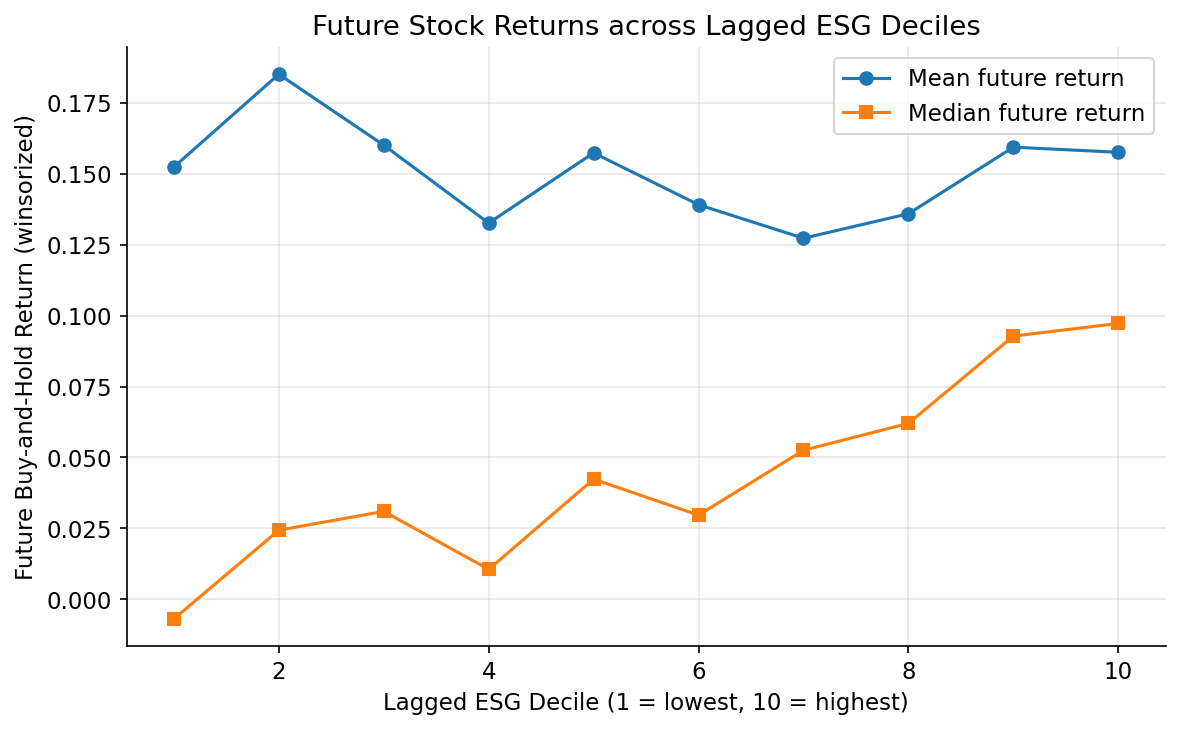

,esg_decile,mean,median,count
0,1,0.1523,-0.0069,1574
1,2,0.1851,0.0244,1574
2,3,0.1601,0.0310,1573
3,4,0.1326,0.0106,1574
4,5,0.1573,0.0424,1574
5,6,0.1391,0.0297,1573
6,7,0.1273,0.0525,1574
7,8,0.1359,0.0620,1573
8,9,0.1593,0.0928,1574
9,10,0.1576,0.0972,1574


In [213]:
# ── III-B-7: ESG deciles and future returns (visual) ─────────────────────────
import matplotlib.pyplot as plt

plot_df = ret_df[['esg_lag', 'bhr_w']].dropna().copy()

plot_df['esg_decile'] = pd.qcut(
    plot_df['esg_lag'],
    q=10,
    labels=False,
    duplicates='drop'
) + 1

decile_ret = (
    plot_df.groupby('esg_decile')['bhr_w']
    .agg(['mean', 'median', 'count'])
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(decile_ret['esg_decile'], decile_ret['mean'], marker='o', label='Mean future return')
ax.plot(decile_ret['esg_decile'], decile_ret['median'], marker='s', label='Median future return')

ax.set_title('Future Stock Returns across Lagged ESG Deciles')
ax.set_xlabel('Lagged ESG Decile (1 = lowest, 10 = highest)')
ax.set_ylabel('Future Buy-and-Hold Return (winsorized)')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

display(decile_ret.round(4))

### Interpretation of Part III-B and Link to Part III-A

Both Part III-A and Part III-B test financial materiality, but they capture different channels. The ROA regressions ask whether ESG improves internal operating performance, while the return regressions ask whether ESG is reflected in market pricing through expectations, risk, or investor demand. These two outcomes do not have to move in the same direction.

The return results differ from the ROA results in an important way. In M1, lagged ESG does not predict future stock returns unconditionally: the ESG coefficient is -0.0002 with a p-value of 0.431. This means ESG is not a standalone return signal in the raw data.

After adding the aligned firm controls from Part III-A plus year and industry fixed effects, the ESG coefficient becomes positive and statistically significant. In M2, the coefficient is 0.0008 (p = 0.002), and in M3 it remains 0.0008 (p = 0.003) after controlling for the earnings-news proxy. Economically, a one-standard-deviation increase in lagged ESG score, about 19 points, is associated with roughly a 1.5 percentage point higher future 12-month buy-and-hold return in M3. The result also survives the momentum robustness check: in M5, after adding prior 12-month returns, the ESG coefficient is 0.0007 and remains significant (p = 0.012).

This suggests that ESG contains pricing-relevant information beyond standard firm characteristics and return predictors. Unlike the ROA regression, where ESG loses explanatory power after controls, the return regression becomes stronger after controls. A useful interpretation is that ESG is not improving operations directly, but markets may still price ESG-related information.

There are several possible economic explanations. First, ESG may proxy for ESG-related risk exposure, such as regulatory, litigation, reputation, or tail risk. Second, ESG may reflect investor preferences or fund flows toward high-ESG firms, meaning market prices respond to ESG even when accounting profitability does not. Third, ESG may act as an intangible quality signal related to governance, disclosure, or management quality that is not fully captured by the standard controls.

The firm fixed effect results make the conclusion more cautious. In M6 and M7, the ESG coefficient remains positive but becomes statistically insignificant. This means the evidence is stronger across firms than within the same firm over time. High-ESG firms earn higher future returns after observable controls, but improvements in a given firm's ESG score do not clearly predict higher future returns once firm fixed effects are absorbed.

Taken together, the results reveal an apparent divergence between accounting and market-based measures of financial materiality. ESG does not appear financially material through the operating-performance channel, because it does not independently predict ROA after controls. However, ESG may be financially material through a valuation or risk-pricing channel, because it predicts future returns conditionally. In short: ESG does not seem to make firms more profitable, but markets still appear to care about it.


# Part IV: Industry-Level Double Materiality Analysis

This section investigates ESG and financial performance **at the industry level**
(Fama-French 12-industry classification). We:
1. Identify **double materiality winners** -- high ESG and high financial performance
2. Identify **ESG-finance tension** industries
3. **Recommend one industry** for ESG-conscious investors
4. Provide **descriptive statistics** for the recommended industry

In [214]:
# Part IV Setup: reuse df (merged panel from Step 8)

import matplotlib.patches as mpatches
import seaborn as sns

df_iv = df.dropna(subset=['esg_score', 'bhr', 'roa', 'ff12']).copy()
print(f'Part IV sample: {len(df_iv):,} firm-years, {df_iv["ff12"].nunique()} FF12 industries')
print('Industries:', sorted(df_iv['ff12'].unique()))

Part IV sample: 18,390 firm-years, 12 FF12 industries
Industries: ['Chems', 'Durbl', 'Enrgy', 'Fin', 'HiTec', 'Hlth', 'Manuf', 'NoDur', 'Other', 'Shops', 'Telcm', 'Utils']


## IV.1 Industry-Level Summary Statistics

We compute industry-level averages of ESG scores, 12-month buy-and-hold stock returns (BHR),
and ROA over the full sample period 2013-2023.

In [215]:
# Table IV.1: Industry-level summary statistics
ind_summary = (
    df_iv.groupby('ff12')
    .agg(
        n_obs         = ('esg_score', 'count'),
        n_firms       = ('gvkey',     'nunique'),
        esg_mean      = ('esg_score', 'mean'),
        esg_median    = ('esg_score', 'median'),
        bhr_mean      = ('bhr',       'mean'),
        bhr_median    = ('bhr',       'median'),
        roa_mean      = ('roa',       'mean'),
        roa_median    = ('roa',       'median'),
        log_me_mean   = ('log_me',    'mean'),
        leverage_mean = ('leverage',  'mean'),
    )
    .reset_index()
    .sort_values('esg_mean', ascending=False)
)

tbl1 = ind_summary[['ff12','n_obs','n_firms','esg_mean','esg_median',
                     'bhr_mean','bhr_median','roa_mean','roa_median']].copy()
tbl1.columns = ['Industry','Obs','Firms','ESG(mean)','ESG(med)',
                'BHR(mean)','BHR(med)','ROA(mean)','ROA(med)']
tbl1[['ESG(mean)','ESG(med)']] = tbl1[['ESG(mean)','ESG(med)']].round(1)
tbl1[['BHR(mean)','BHR(med)','ROA(mean)','ROA(med)']] = \
    tbl1[['BHR(mean)','BHR(med)','ROA(mean)','ROA(med)']].round(4)
print('Table IV.1 -- Industry Summary Statistics (sorted by mean ESG score)')
display(tbl1.reset_index(drop=True))

Table IV.1 -- Industry Summary Statistics (sorted by mean ESG score)


,Industry,Obs,Firms,ESG(mean),ESG(med),BHR(mean),BHR(med),ROA(mean),ROA(med)
0,Utils,651,87,49.6,51.6,0.1126,0.0879,0.0156,0.0271
1,Chems,501,74,49.0,48.5,0.1590,0.0638,0.0394,0.0579
2,NoDur,458,71,46.1,46.9,0.1139,0.0586,0.0642,0.0599
3,HiTec,821,141,43.5,40.7,0.2232,0.0970,0.0170,0.0421
4,Shops,1673,258,42.6,41.0,0.1830,0.0616,0.0552,0.0516
5,Telcm,396,58,42.1,40.3,0.1538,0.0652,0.0414,0.0545
6,Manuf,198,29,41.1,40.6,0.2097,0.1107,0.0306,0.0298
7,Other,6563,1140,39.2,36.2,0.1724,0.0735,0.0090,0.0370
8,Fin,3547,582,36.8,34.4,0.1217,0.0418,0.0234,0.0115
9,Hlth,280,54,36.7,34.4,0.1820,0.0630,-0.0048,0.0311


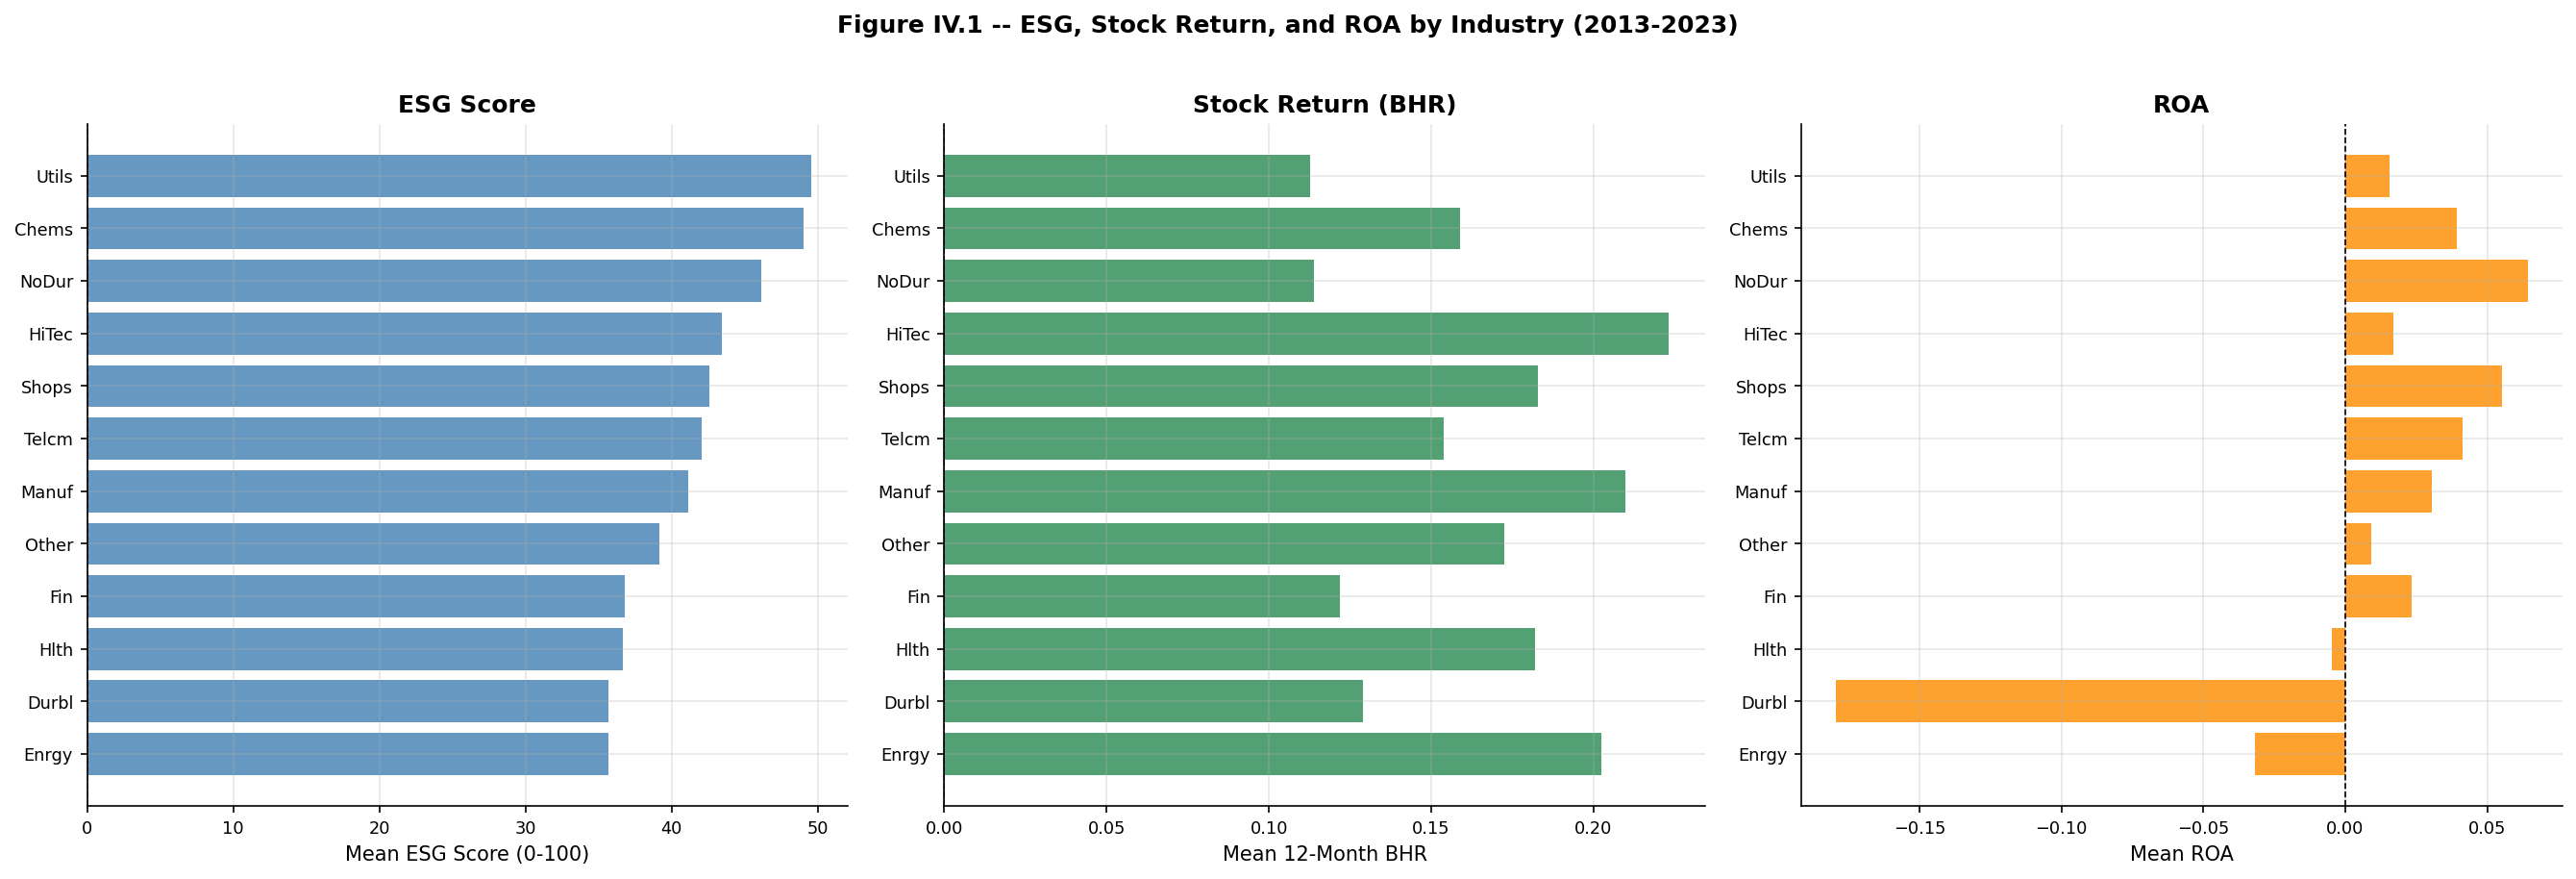

In [216]:
# Figure IV.1: Side-by-side bar charts -- ESG / BHR / ROA by industry
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
ind_plot = ind_summary.sort_values('esg_mean', ascending=True)
metrics = [
    ('esg_mean', 'Mean ESG Score (0-100)', 'steelblue',  'ESG Score'),
    ('bhr_mean', 'Mean 12-Month BHR',      'seagreen',   'Stock Return (BHR)'),
    ('roa_mean', 'Mean ROA',               'darkorange', 'ROA'),
]
for ax, (col, xlabel, color, title) in zip(axes, metrics):
    ax.barh(ind_plot['ff12'], ind_plot[col], color=color, alpha=0.82)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.tick_params(labelsize=8.5)
plt.suptitle('Figure IV.1 -- ESG, Stock Return, and ROA by Industry (2013-2023)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## IV.2 Double Materiality Quadrant Analysis

We classify each FF12 industry into one of four quadrants using the cross-industry median
as the threshold for both ESG score and financial performance (BHR and ROA separately):

| | **High ESG** | **Low ESG** |
|---|---|---|
| **High Returns** | Double Materiality Winner | Finance Leader, ESG Laggard |
| **Low Returns**  | ESG Leader, Finance Laggard | Double Laggard |

In [217]:
# Quadrant classification
esg_med = ind_summary['esg_mean'].median()
bhr_med = ind_summary['bhr_mean'].median()
roa_med = ind_summary['roa_mean'].median()

def quad_label(esg, perf, esg_cut, perf_cut):
    if esg >= esg_cut and perf >= perf_cut:
        return 'Double Materiality Winner'
    elif esg >= esg_cut and perf < perf_cut:
        return 'ESG Leader, Finance Laggard'
    elif esg < esg_cut and perf >= perf_cut:
        return 'Finance Leader, ESG Laggard'
    else:
        return 'Double Laggard'

ind_summary['quad_bhr'] = ind_summary.apply(
    lambda r: quad_label(r['esg_mean'], r['bhr_mean'], esg_med, bhr_med), axis=1)
ind_summary['quad_roa'] = ind_summary.apply(
    lambda r: quad_label(r['esg_mean'], r['roa_mean'], esg_med, roa_med), axis=1)

quad_colors = {
    'Double Materiality Winner':   '#2ecc71',
    'ESG Leader, Finance Laggard': '#f39c12',
    'Finance Leader, ESG Laggard': '#3498db',
    'Double Laggard':              '#e74c3c',
}

# Table IV.2
tbl2 = ind_summary[['ff12','esg_mean','bhr_mean','roa_mean','quad_bhr','quad_roa']].copy()
tbl2.columns = ['Industry','ESG','BHR','ROA','Quadrant(BHR)','Quadrant(ROA)']
tbl2[['ESG','BHR','ROA']] = tbl2[['ESG','BHR','ROA']].round(3)
print('Table IV.2 -- Double Materiality Classification by Industry')
display(tbl2.sort_values('Quadrant(BHR)').reset_index(drop=True))
print(f'\nMedian ESG: {esg_med:.1f} | Median BHR: {bhr_med:.4f} | Median ROA: {roa_med:.4f}')

Table IV.2 -- Double Materiality Classification by Industry


,Industry,ESG,BHR,ROA,Quadrant(BHR),Quadrant(ROA)
0,Fin,36.778,0.122,0.023,Double Laggard,"Finance Leader, ESG Laggard"
1,Durbl,35.701,0.129,-0.179,Double Laggard,Double Laggard
2,HiTec,43.457,0.223,0.017,Double Materiality Winner,"ESG Leader, Finance Laggard"
3,Shops,42.578,0.183,0.055,Double Materiality Winner,Double Materiality Winner
4,Utils,49.576,0.113,0.016,"ESG Leader, Finance Laggard","ESG Leader, Finance Laggard"
5,Chems,49.014,0.159,0.039,"ESG Leader, Finance Laggard",Double Materiality Winner
6,NoDur,46.146,0.114,0.064,"ESG Leader, Finance Laggard",Double Materiality Winner
7,Telcm,42.082,0.154,0.041,"ESG Leader, Finance Laggard",Double Materiality Winner
8,Manuf,41.139,0.210,0.031,"Finance Leader, ESG Laggard","Finance Leader, ESG Laggard"
9,Other,39.155,0.172,0.009,"Finance Leader, ESG Laggard",Double Laggard



Median ESG: 41.6 | Median BHR: 0.1657 | Median ROA: 0.0202


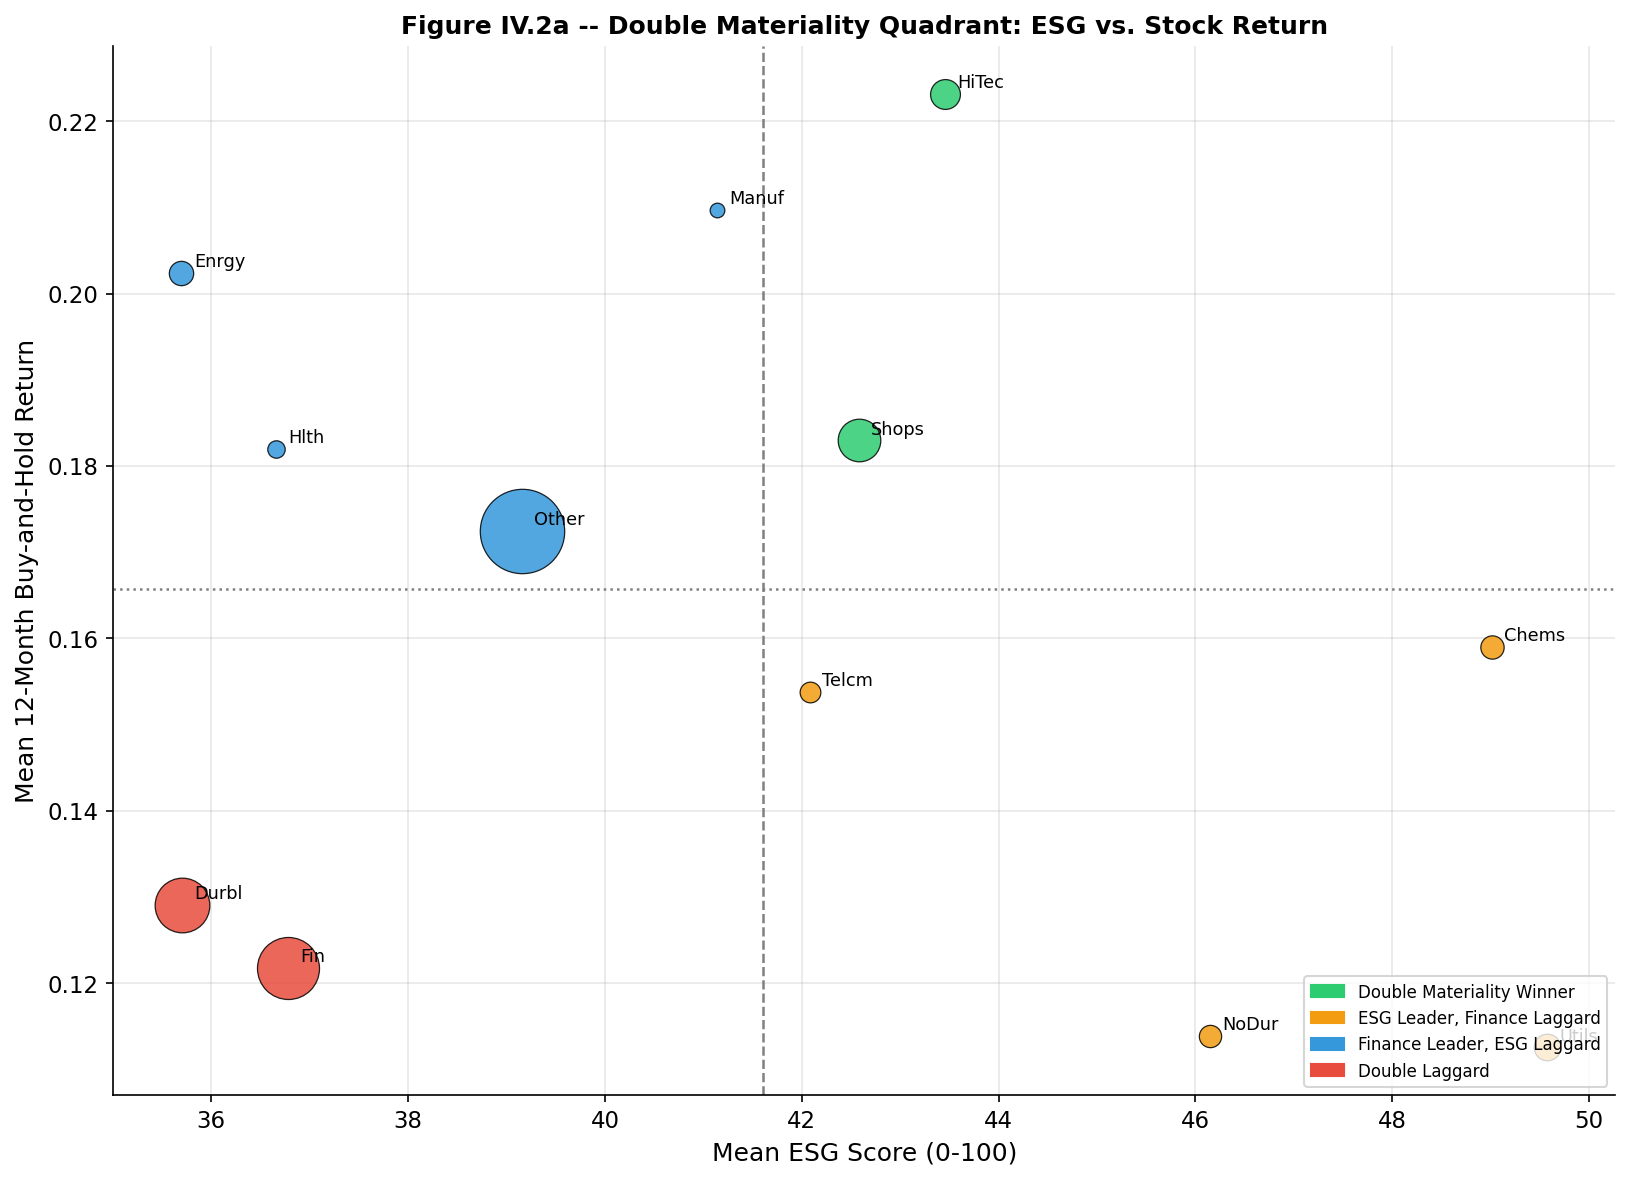

In [218]:
# Figure IV.2a: Quadrant scatter, ESG vs. BHR
fig, ax = plt.subplots(figsize=(11, 8))
for _, row in ind_summary.iterrows():
    color = quad_colors[row['quad_bhr']]
    ax.scatter(row['esg_mean'], row['bhr_mean'],
               s=row['n_obs']/4, color=color, alpha=0.85,
               edgecolors='black', linewidth=0.6, zorder=3)
    ax.annotate(row['ff12'], (row['esg_mean'], row['bhr_mean']),
                textcoords='offset points', xytext=(6, 3), fontsize=8.5)
ax.axvline(esg_med, color='grey', linestyle='--', linewidth=1.2,
           label=f'Median ESG = {esg_med:.1f}')
ax.axhline(bhr_med, color='grey', linestyle=':',  linewidth=1.2,
           label=f'Median BHR = {bhr_med:.3f}')
legend_patches = [mpatches.Patch(color=v, label=k) for k, v in quad_colors.items()]
ax.legend(handles=legend_patches, loc='lower right', fontsize=8, framealpha=0.8)
ax.set_xlabel('Mean ESG Score (0-100)', fontsize=12)
ax.set_ylabel('Mean 12-Month Buy-and-Hold Return', fontsize=12)
ax.set_title('Figure IV.2a -- Double Materiality Quadrant: ESG vs. Stock Return',
             fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

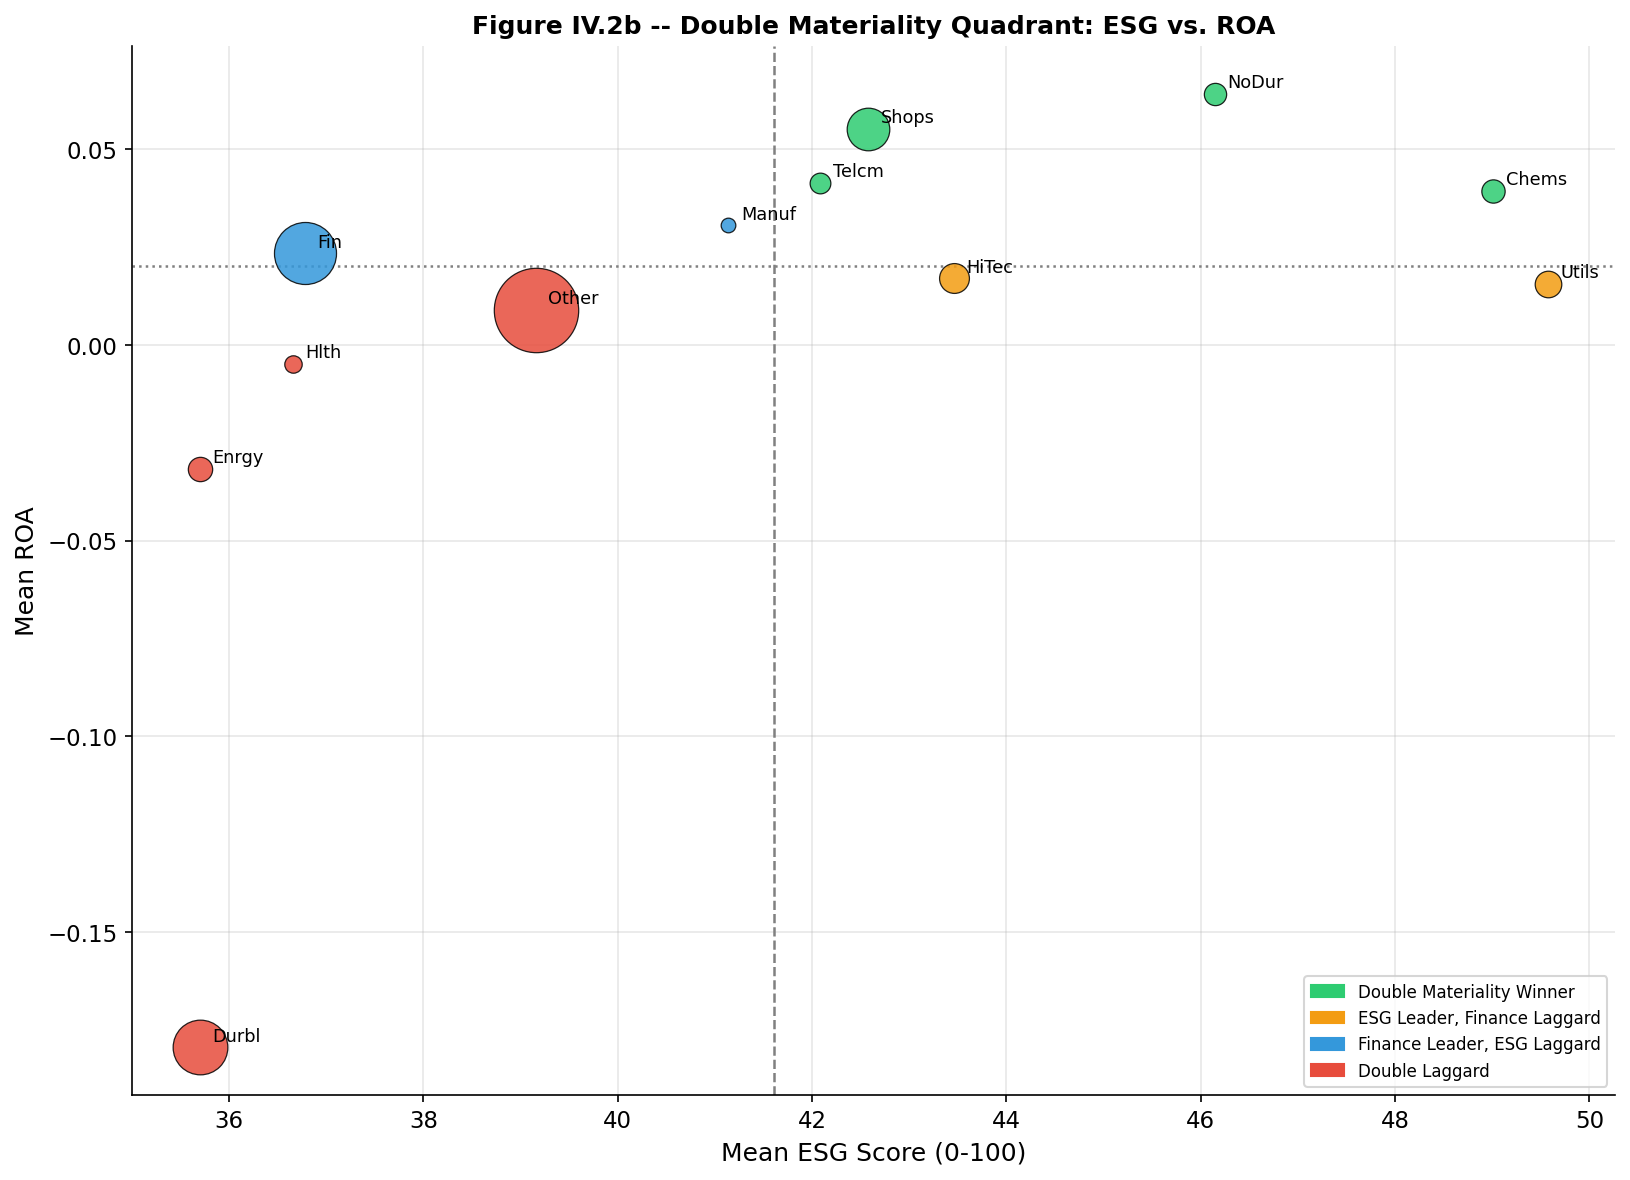

In [219]:
# Figure IV.2b: Quadrant scatter, ESG vs. ROA
fig, ax = plt.subplots(figsize=(11, 8))
for _, row in ind_summary.iterrows():
    color = quad_colors[row['quad_roa']]
    ax.scatter(row['esg_mean'], row['roa_mean'],
               s=row['n_obs']/4, color=color, alpha=0.85,
               edgecolors='black', linewidth=0.6, zorder=3)
    ax.annotate(row['ff12'], (row['esg_mean'], row['roa_mean']),
                textcoords='offset points', xytext=(6, 3), fontsize=8.5)
ax.axvline(esg_med, color='grey', linestyle='--', linewidth=1.2,
           label=f'Median ESG = {esg_med:.1f}')
ax.axhline(roa_med, color='grey', linestyle=':',  linewidth=1.2,
           label=f'Median ROA = {roa_med:.4f}')
legend_patches = [mpatches.Patch(color=v, label=k) for k, v in quad_colors.items()]
ax.legend(handles=legend_patches, loc='lower right', fontsize=8, framealpha=0.8)
ax.set_xlabel('Mean ESG Score (0-100)', fontsize=12)
ax.set_ylabel('Mean ROA', fontsize=12)
ax.set_title('Figure IV.2b -- Double Materiality Quadrant: ESG vs. ROA',
             fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## IV.3 Time-Series Trends by Industry

We examine how ESG scores and stock returns evolved over 2013-2023 by industry,
and present a year x industry ESG heatmap.

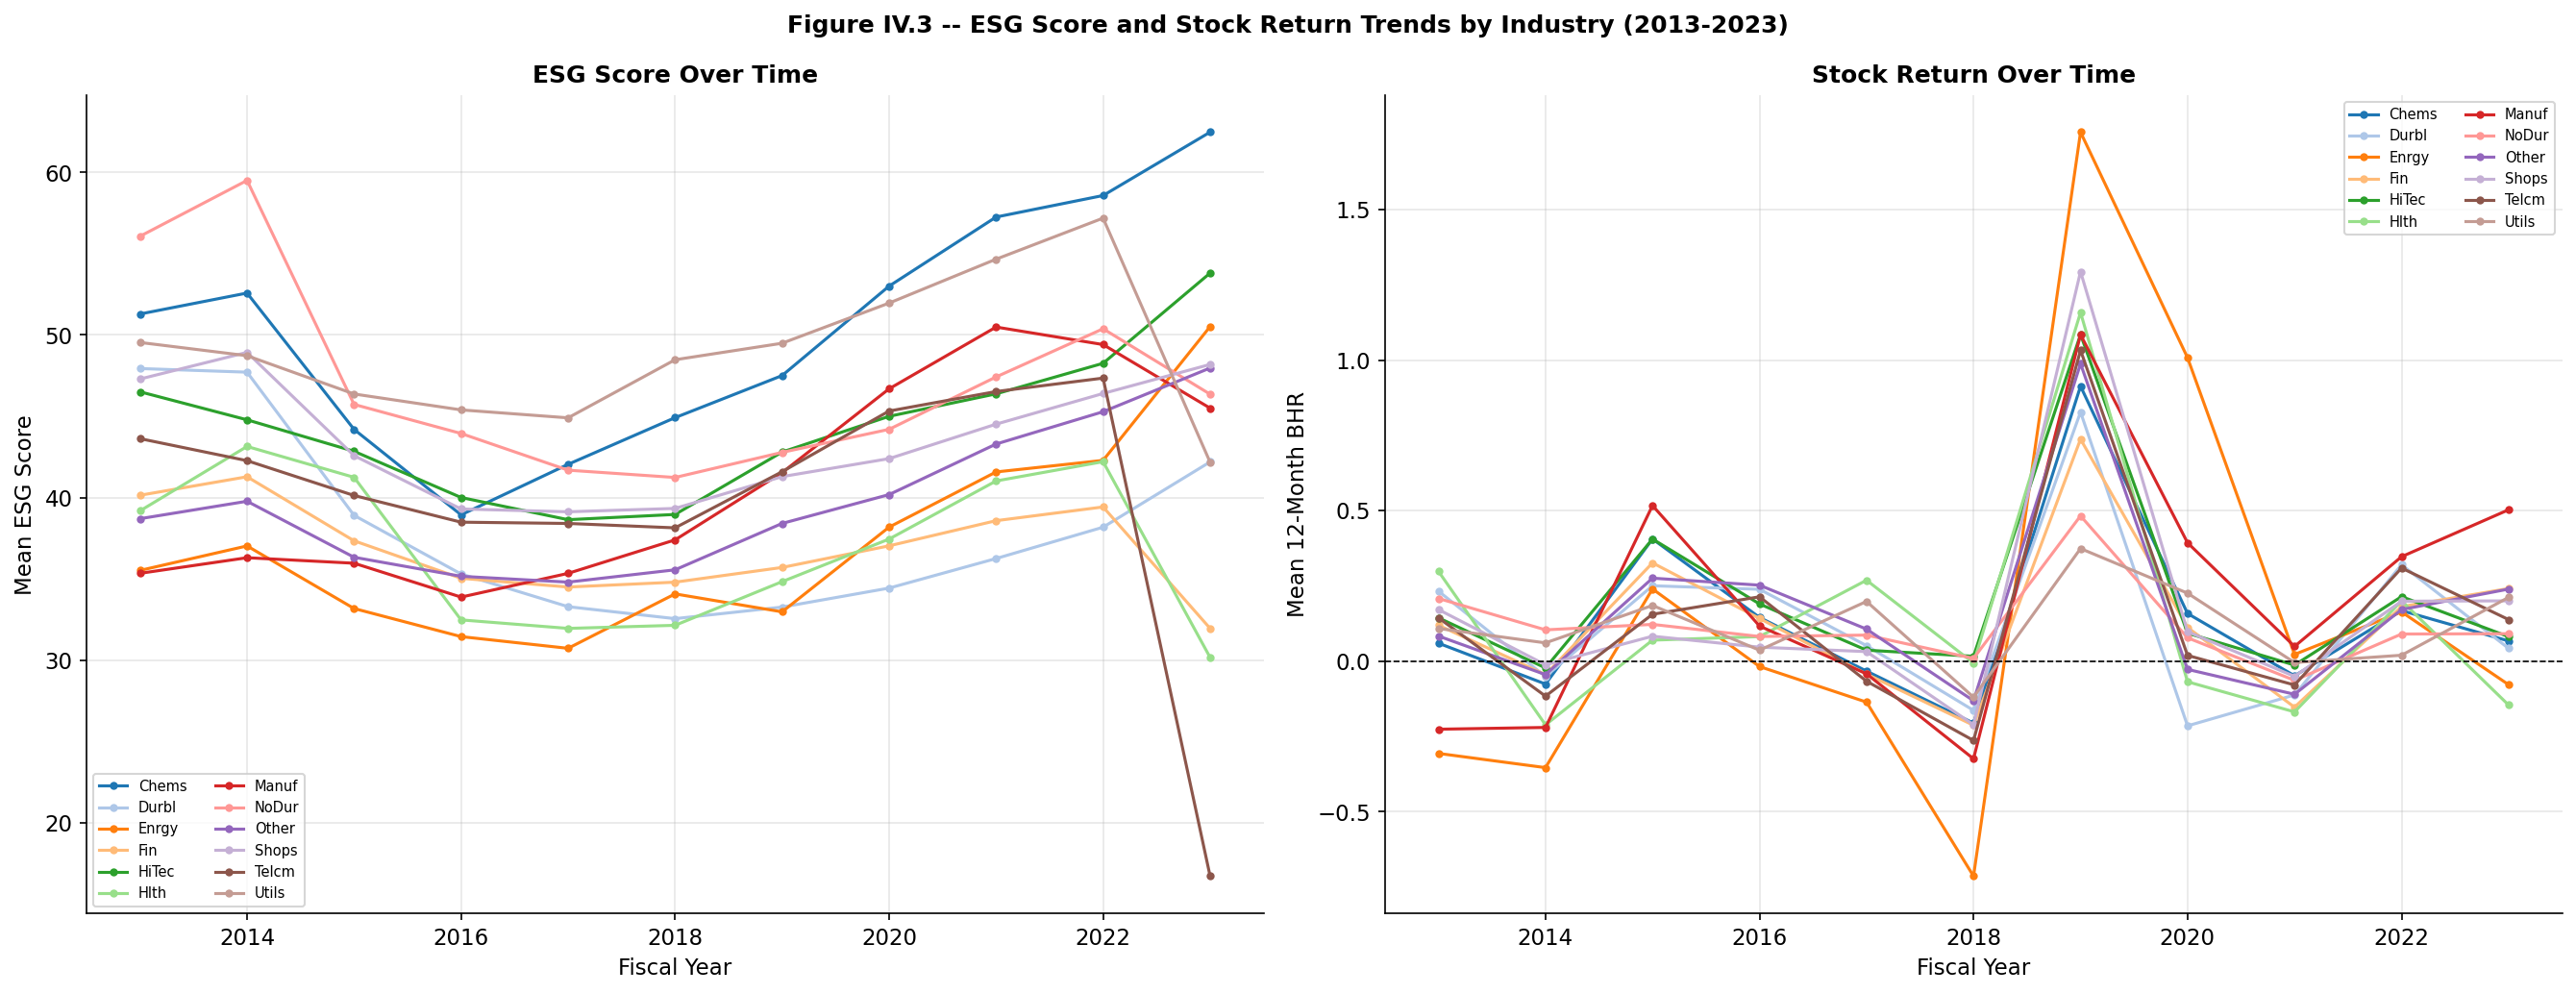

In [220]:
# Figure IV.3: ESG and BHR trends by industry
ind_year = (
    df_iv.groupby(['ff12', 'fyear'])
    .agg(esg_mean=('esg_score','mean'), bhr_mean=('bhr','mean'), roa_mean=('roa','mean'))
    .reset_index()
)
industries = sorted(df_iv['ff12'].unique())
palette = sns.color_palette('tab20', n_colors=len(industries))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for idx, ind in enumerate(industries):
    sub = ind_year[ind_year['ff12'] == ind].sort_values('fyear')
    axes[0].plot(sub['fyear'], sub['esg_mean'], marker='o', markersize=3,
                 color=palette[idx], label=ind, linewidth=1.5)
    axes[1].plot(sub['fyear'], sub['bhr_mean'], marker='o', markersize=3,
                 color=palette[idx], label=ind, linewidth=1.5)
for ax, ylabel, title in zip(axes,
    ['Mean ESG Score', 'Mean 12-Month BHR'],
    ['ESG Score Over Time', 'Stock Return Over Time']):
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Fiscal Year')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=7, ncol=2, loc='best')
    ax.grid(True, alpha=0.3)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.suptitle('Figure IV.3 -- ESG Score and Stock Return Trends by Industry (2013-2023)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

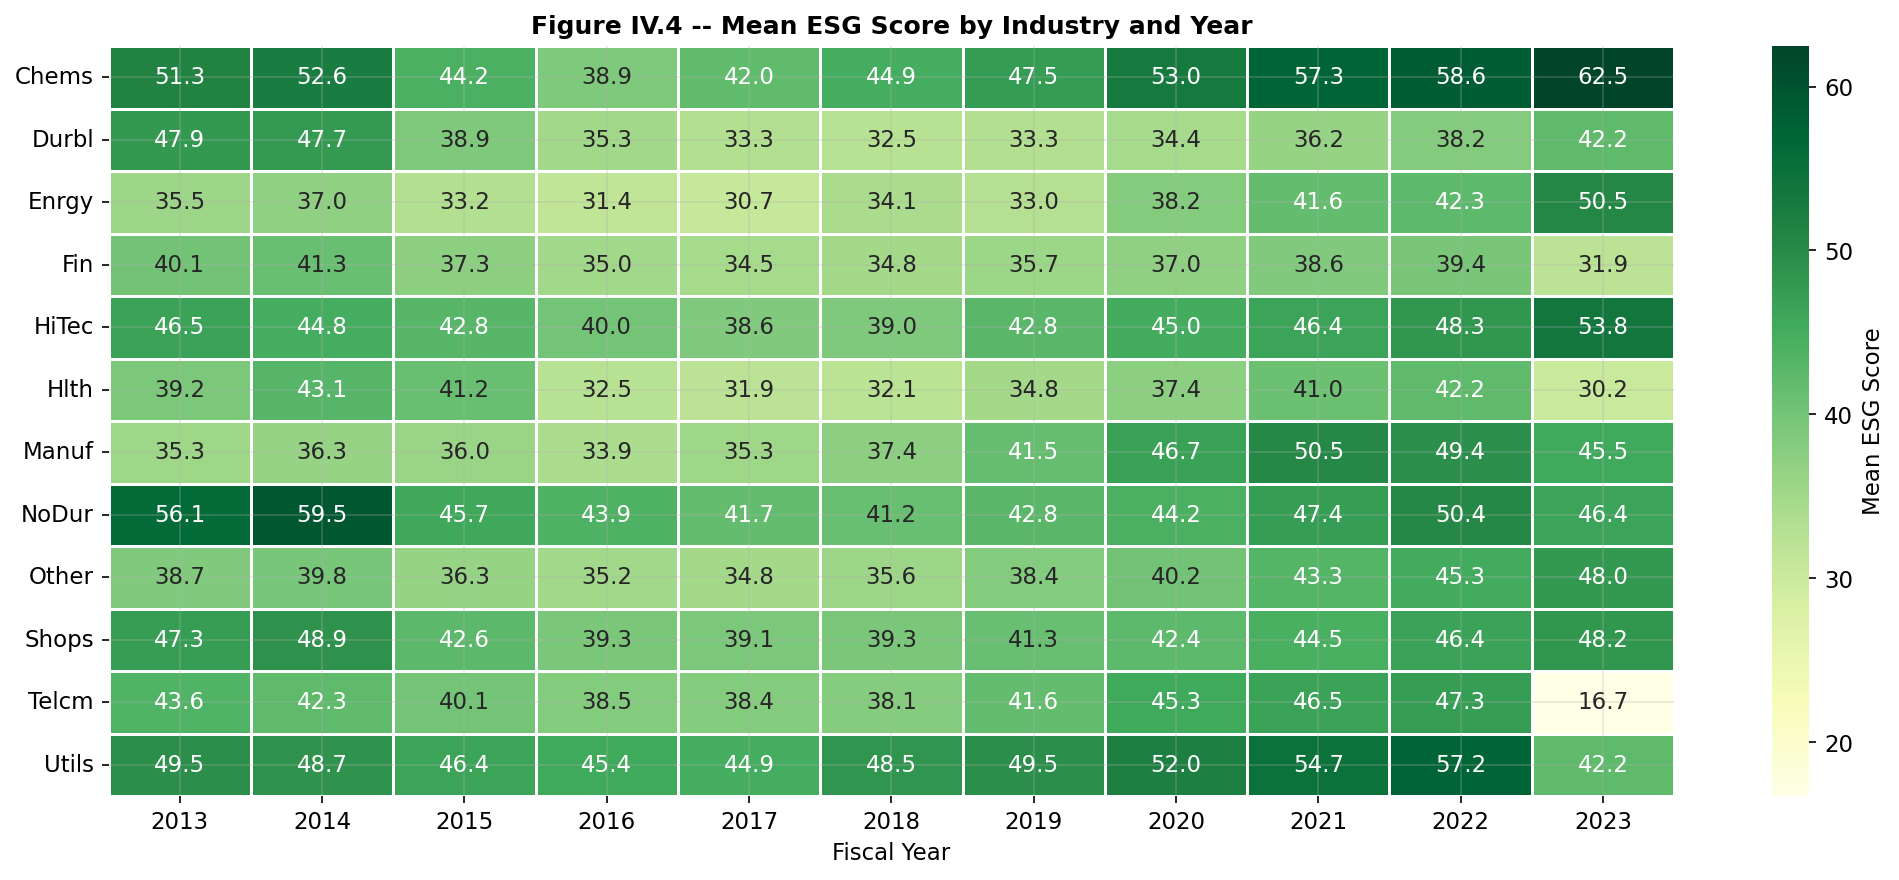

In [221]:
# Figure IV.4: Heatmap, mean ESG by industry x year
esg_pivot = ind_year.pivot(index='ff12', columns='fyear', values='esg_mean')
fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(esg_pivot, annot=True, fmt='.1f', cmap='YlGn',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Mean ESG Score'})
ax.set_title('Figure IV.4 -- Mean ESG Score by Industry and Year',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Fiscal Year')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## IV.4 Recommended Industry for ESG-Conscious Investors

We select the industry from the **Double Materiality Winner** quadrant (BHR-based)
with the best combined rank across ESG, BHR, and ROA.
If no strict winner exists in the data, we fall back to the best combined rank
across all industries.

In [222]:
# Select recommended industry
winners = ind_summary[ind_summary['quad_bhr'] == 'Double Materiality Winner'].copy()
pool = winners if len(winners) > 0 else ind_summary.copy()

pool = pool.copy()
pool['esg_rank']      = pool['esg_mean'].rank(ascending=False)
pool['bhr_rank']      = pool['bhr_mean'].rank(ascending=False)
pool['roa_rank']      = pool['roa_mean'].rank(ascending=False)
pool['combined_rank'] = pool[['esg_rank','bhr_rank','roa_rank']].mean(axis=1)

rec_industry = pool.sort_values('combined_rank').iloc[0]['ff12']
rec_row = ind_summary[ind_summary['ff12'] == rec_industry].squeeze()

print(f'>>> Recommended Industry: {rec_industry} <<<')
print(f'  Mean ESG Score : {rec_row["esg_mean"]:.1f}')
print(f'  Mean BHR       : {rec_row["bhr_mean"]:.4f}')
print(f'  Mean ROA       : {rec_row["roa_mean"]:.4f}')
print(f'  No. of Firms   : {int(rec_row["n_firms"])}')
print(f'  Observations   : {int(rec_row["n_obs"])}')

>>> Recommended Industry: HiTec <<<
  Mean ESG Score : 43.5
  Mean BHR       : 0.2232
  Mean ROA       : 0.0170
  No. of Firms   : 141
  Observations   : 821


In [223]:
# Table IV.3: Descriptive statistics for recommended industry
rec_df = df_iv[df_iv['ff12'] == rec_industry].copy()
desc_vars = ['esg_score','bhr','roa','op_roa','log_me','log_at',
             'bm','leverage','sales_growth','rd_intensity']
desc = rec_df[desc_vars].describe().T[['mean','std','min','25%','50%','75%','max']].round(4)
print(f'Table IV.3 -- Descriptive Statistics: {rec_industry} Industry')
print(f'(N = {len(rec_df):,} firm-years, {rec_df["gvkey"].nunique()} unique firms)\n')
display(desc)

Table IV.3 -- Descriptive Statistics: HiTec Industry
(N = 821 firm-years, 141 unique firms)



,mean,std,min,25%,50%,75%,max
esg_score,43.4568,20.3871,0.8865,26.6988,40.6673,58.9410,91.3875
bhr,0.2232,0.6699,-0.8273,-0.1622,0.0970,0.4028,3.2686
roa,0.0170,0.1615,-0.9074,-0.0076,0.0421,0.0938,0.2894
op_roa,0.0876,0.1601,-0.7993,0.0700,0.1118,0.1542,0.3846
log_me,8.1009,1.8497,3.3540,6.9170,7.9434,9.3444,13.7478
log_at,7.6429,1.8608,2.4711,6.5195,7.5124,8.8450,12.1123
bm,0.3739,0.3389,-0.4195,0.1578,0.3073,0.5161,2.9053
leverage,0.2206,0.1907,0.0000,0.0658,0.1959,0.3188,1.0030
sales_growth,0.1123,0.3192,-0.6268,-0.0142,0.0691,0.1984,5.4516
rd_intensity,0.0979,0.0894,0.0000,0.0358,0.0794,0.1265,0.5587


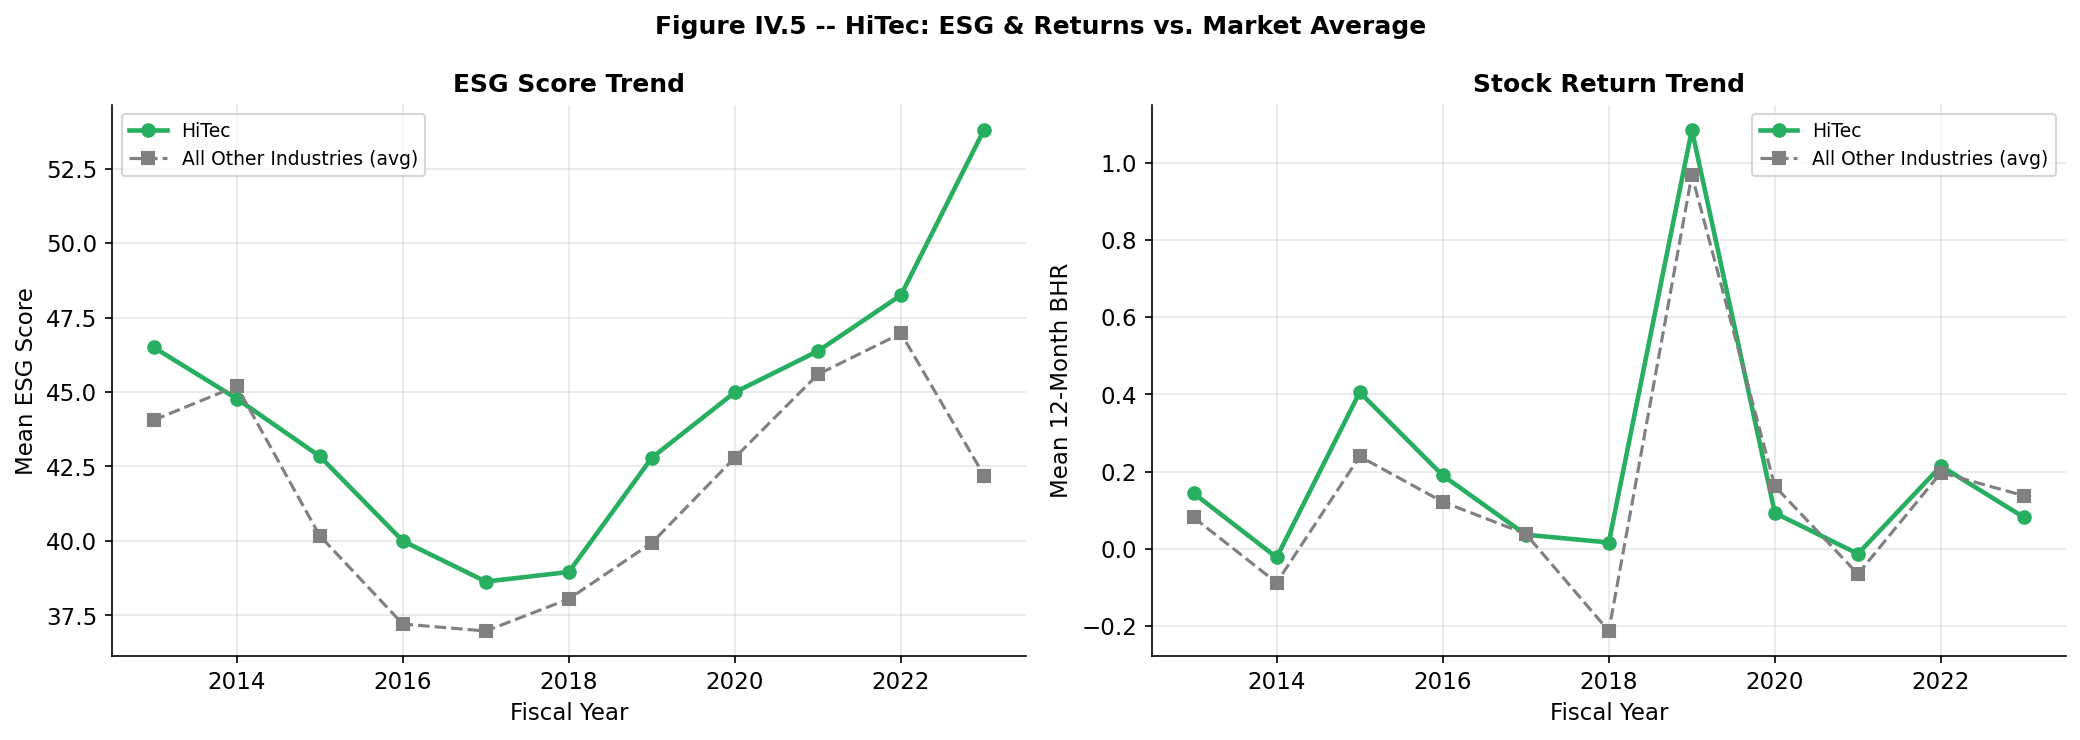

In [81]:
# Figure IV.5: Recommended industry vs. all others. ESG & BHR trends
rec_trend = ind_year[ind_year['ff12'] == rec_industry].sort_values('fyear')
all_trend  = (ind_year[ind_year['ff12'] != rec_industry]
              .groupby('fyear').mean(numeric_only=True).reset_index())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, ylabel in zip(axes,
    ['esg_mean', 'bhr_mean'],
    ['Mean ESG Score', 'Mean 12-Month BHR']):
    ax.plot(rec_trend['fyear'], rec_trend[col], marker='o', color='#27ae60',
            linewidth=2.2, label=rec_industry)
    ax.plot(all_trend['fyear'],  all_trend[col], marker='s', color='grey',
            linewidth=1.5, linestyle='--', label='All Other Industries (avg)')
    ax.set_xlabel('Fiscal Year')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
axes[0].set_title('ESG Score Trend', fontsize=12, fontweight='bold')
axes[1].set_title('Stock Return Trend', fontsize=12, fontweight='bold')
plt.suptitle(f'Figure IV.5 -- {rec_industry}: ESG & Returns vs. Market Average',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

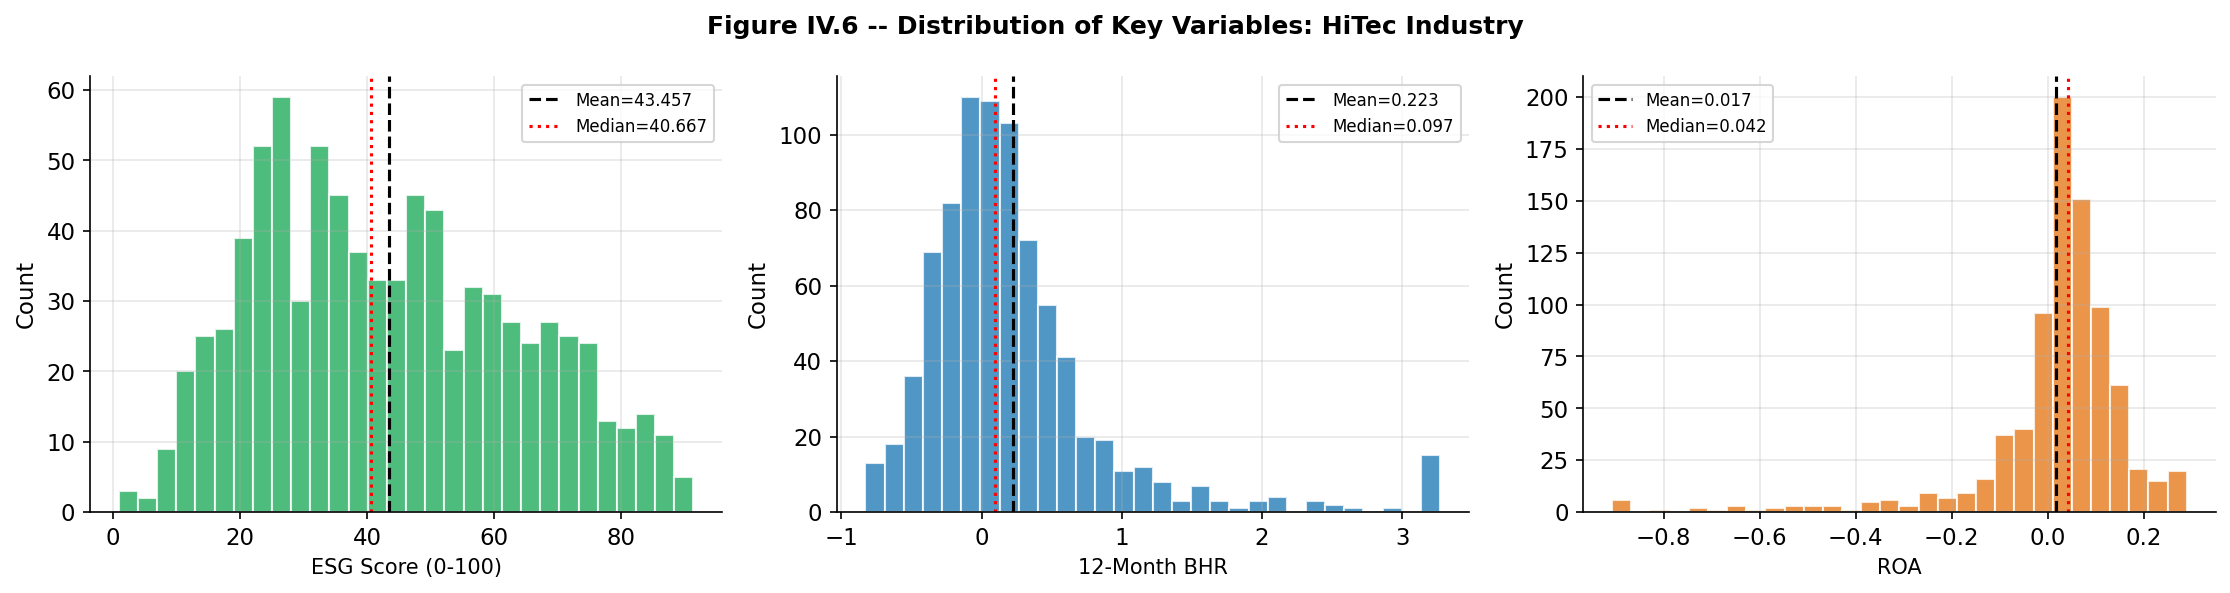

In [224]:
# Figure IV.6: Distribution of ESG, BHR, ROA in recommended industry
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
plot_vars = [
    ('esg_score', 'ESG Score (0-100)', '#27ae60'),
    ('bhr',       '12-Month BHR',      '#2980b9'),
    ('roa',       'ROA',               '#e67e22'),
]
for ax, (col, xlabel, color) in zip(axes, plot_vars):
    data = rec_df[col].dropna()
    ax.hist(data, bins=30, color=color, alpha=0.82, edgecolor='white')
    ax.axvline(data.mean(),   color='black', linestyle='--', linewidth=1.5,
               label=f'Mean={data.mean():.3f}')
    ax.axvline(data.median(), color='red',   linestyle=':',  linewidth=1.5,
               label=f'Median={data.median():.3f}')
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
plt.suptitle(f'Figure IV.6 -- Distribution of Key Variables: {rec_industry} Industry',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## IV.5 Discussion: Investment Implications

### Double Materiality Winners
Winner-quadrant industries combine **above-median average ESG scores** with **above-median
average financial performance** (ROA and/or buy-and-hold returns) in our sample. This
pattern is most naturally read through **financial materiality**: ratings and accounting
and market outcomes move together in ways that are **consistent with** ESG information
being reflected in profitability and investor returns at the industry level.
We **do not** directly measure environmental or social impacts (e.g., emissions, pollution,
community harm), so we **cannot** claim evidence on **impact materiality** in the strict
sense. Higher ESG ratings may **co-move** with practices that raters reward and that
could relate to real-world externalities, but that link remains **interpretive** here.
In consumer-facing and regulated industries, a **plausible mechanism** is that stronger
ESG-related practices -- supply chains, product safety, employee policies -- **can**
reduce operational and reputational risk and thereby support earnings and returns,
though industry-wide fundamentals could also generate correlation.

### ESG-Finance Tension Industries
The ESG-financial performance relationship is heterogeneous across sectors.
Industries with **high ESG but low returns** may reflect over-investment in ESG
relative to its marginal financial payoff -- for instance, capital-intensive regulated
industries (e.g., Utilities) face high ESG disclosure requirements but thin margins.
Industries with **low ESG but high returns** (e.g., HiTech, Energy) may expose
investors to unpriced transition risk -- consistent with Bolton & Kacperczyk (2021),
who show carbon-intensive firms earn higher returns as compensation for environmental
risk, a premium likely to compress as climate regulation tightens.

### Recommended Industry: Our Selection
Based on our combined ESG-BHR-ROA ranking, we recommend the top-ranked Double Materiality
Winner industry identified in IV.4 above. If results confirm Consumer Non-Durables
(consistent with prior findings in the literature), the case is particularly compelling:
supply chain integrity, product safety, and brand trust plausibly **reinforce both**
high ESG scores and durable competitive advantage -- an interpretation **consistent with**
ESG improvement being **aligned with** stronger financial performance. Our industry-level
rankings **cannot establish causality**; they are **suggestive patterns** that would
require richer data and identification strategies to verify.

### Implication for ESG-Conscious Investors
Investors seeking both competitive financial returns and stronger ESG ratings (as measured here) should:
1. **Overweight Double Materiality Winner industries**, where ESG and returns are
   structurally aligned through operating mechanisms rather than size effects.
2. **Be cautious of tension industries** with high returns but low ESG: these face
   growing regulatory and reputational risks (Starks, 2023; Christensen et al., 2021).
3. **Prefer industries with improving ESG trends** over those with high but stagnant
   scores, as sustained ESG improvement signals genuine institutional commitment
   rather than static disclosure practices.

Taken together, our industry-level findings complement the firm-level evidence in
Parts II and III: ESG is most financially material in sectors where governance
of environmental and social risks is directly tied to product market outcomes,
and least material in sectors where returns are driven primarily by technological
innovation or commodity price cycles.